# **1. Problem Statement**

## **1.a. Business Context**

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## **1.b. Objective**

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## **1.c. Data Description**

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **2. Installing and Importing the Necessary Libraries**

* In Google Colab, pandas and NumPy are preconfigured with compatible versions, matplotlib is preinstalled, and TensorFlow is already available with GPU support enabled, all ready for immediate use; therefore, only additional libraries such as seaborn and scikit-learn need to be installed using !pip install seaborn scikit-learn -q.

In [ ]:
# Install additional libraries (seaborn and scikit-learn)
!pip install seaborn scikit-learn -q

In [ ]:
# Data manipulation
import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical computations

# Plotting library
import matplotlib

# Visualization
import matplotlib.pyplot as plt # Plotting library
import seaborn as sns # Statistical visualization

# Machine learning library
import sklearn

# Data splitting
from sklearn.model_selection import train_test_split # Split data into train and test sets

# Data preprocessing tools for machine learning
from sklearn.preprocessing import (
    LabelEncoder, # Encodes categorical labels into numerical values
    OneHotEncoder, # Converts categorical variables into binary one-hot encoded vectors
    StandardScaler # Standardizes features by removing the mean and scaling to unit variance
)
from sklearn.impute import SimpleImputer # Handle missing values

# Model evaluation metrics for classification tasks
from sklearn.metrics import (
    confusion_matrix, # Generates a confusion matrix to compare actual vs predicted classes
    accuracy_score, # Calculates overall prediction accuracy
    precision_score, # Measures precision: proportion of positive predictions that are correct
    recall_score, # Measures recall (sensitivity): proportion of actual positives correctly identified
    f1_score, # Calculates F1-score: harmonic mean of precision and recall
    classification_report # Generates a detailed report of precision, recall, F1-score, and support for each class
)

# TensorFlow / Keras for building and training neural network models
import tensorflow as tf
from tensorflow.keras.models import Sequential # Imports Sequential model for building neural networks layer-by-layer

from tensorflow.keras.layers import (
    Dense, # Fully connected neural network layer
    Input, # Defines the input shape for the model
    Dropout, # Randomly disables neurons during training to reduce overfitting
    BatchNormalization # Normalizes layer outputs to improve training stability and speed
)
from tensorflow.keras import backend as K # Imports Keras backend functions for low-level tensor operations

# Time related functions
import time
# To suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
print(f"Pandas: {pd.__version__}") # Print pandas version to confirm DataFrame operations compatibility

print(f"NumPy: {np.__version__}") # Print NumPy version to ensure compatibility with numerical computations

print(f"Matplotlib: {matplotlib.__version__}") # Print matplotlib version to verify plotting functionality

print(f"Seaborn: {sns.__version__}") # Print seaborn version for statistical visualization compatibility

print(f"Sklearn: {sklearn.__version__}") # Print scikit-learn version for preprocessing and model evaluation compatibility

print(f"TensorFlow: {tf.__version__}") # Print TensorFlow version to verify compatibility with Keras and GPU support

Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Sklearn: 1.6.1
TensorFlow: 2.20.0


**Observations:**
* The environment uses pandas 2.2.2 for data manipulation, NumPy 2.0.2 for numerical computations, matplotlib 3.10.0 and seaborn 0.13.2 for data visualization, scikit-learn 1.6.1 for machine learning tasks, and TensorFlow 2.20.0 for building and training neural network models, all in compatible and up-to-date versions.

# **3. Import the Data**

In [ ]:
# Mount Google Drive to access files in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the dataset
train = pd.read_csv("/content/drive/MyDrive/4. Projects/Project4/Train.csv") # Import the training data
test = pd.read_csv("/content/drive/MyDrive/4. Projects/Project4/Test.csv") # Import the test data

In [ ]:
# Create copies of the original DataFrames to preserve the raw data
df_train = train.copy()
df_test = test.copy()

# **4. Data Overview**

## **4.a. View the First and Last 5 Rows of the Dataset**

### **4.a.1. Training Data**

In [ ]:
df_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


**Observations:**
* The preview shows the first five rows of the training data with 41 columns.

In [ ]:
df_train.tail(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


**Observations:**
* The preview shows the last five rows of the training data with 41 columns.

### **4.a.2. Test Data**

In [ ]:
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


**Observations:**
* The preview shows the first five rows of the test data with 41 columns.

In [ ]:
df_test.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
4995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
4996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
4997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
4998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
4999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


**Observations:**
* The preview shows the last five rows of the test data with 41 columns.

## **4.b. Checking the Shape of the Dataset**

In [ ]:
df_train.shape

(20000, 41)

**Observations:**
* The training dataset has 20,000 rows and 41 columns.

In [ ]:
df_test.shape

(5000, 41)

**Observations:**
* The test dataset has 5,000 rows and 41 columns.

## **4.c. Checking for Missing Values**

### **4.c.1. Training Data**

In [ ]:
df_train.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observations:**
* The training dataset has missing values only in columns V1 and V2, with 18 missing entries each, while all other columns have no missing values.

### **4.c.2. Test Data**

In [ ]:
df_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observations:**
* The test dataset has missing values only in columns V1 and V2, with 5 and 6 missing entries respectively, while all other columns have no missing values.

## **4.d. Checking for Duplicate Values**

In [ ]:
df_train.duplicated().sum()

np.int64(0)

**Observations:**
* There are no duplicate rows in the training dataset.

In [ ]:
df_test.duplicated().sum()

np.int64(0)

**Observations:**
* There are no duplicate rows in the test dataset.

## **4.e. Checking the Number of Unique Values in Each Column**

### **4.e.1. Training Data**

In [ ]:
df_train.nunique()

,0
V1,19982
V2,19982
V3,20000
V4,20000
V5,20000
V6,20000
V7,20000
V8,20000
V9,20000
V10,20000


**Observations:**
* Most columns in the training dataset have 20,000 unique values, indicating all entries are unique, while V1 and V2 have slightly fewer unique values (19,982), and the Target column has 2 unique values.

### **4.e.2. Test Data**

In [ ]:
df_test.nunique()

,0
V1,4995
V2,4994
V3,5000
V4,5000
V5,5000
V6,5000
V7,5000
V8,5000
V9,5000
V10,5000


**Observations:**
* Most columns in the test dataset have 5,000 unique values, indicating all entries are unique, while V1 and V2 have slightly fewer unique values (4,995 and 4,994), and the Target column has 2 unique values.

## **4.f. Checking Datatypes and Number of Non-Null Values for Each Column**

### **4.f.1. Training Data**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

**Observations:**
* The training dataset contains 20,000 entries and 41 columns, where all features are of type float64 except the Target column (int64), with missing values only in V1 and V2, and the total memory usage is about 6.3 MB.

### **4.f.2. Test Data**

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

**Observations:**
* The test dataset contains 5,000 entries and 41 columns, where all features are of type float64 except the Target column (int64), with missing values only in V1 and V2, and the total memory usage is about 1.6 MB.

## **4.g. Checking the Statistical Summary**

### **4.g.1. Training Data**

In [ ]:
df_train.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
V1,20000.0,-0.271996,3.440075,-11.876451,-2.735778,-0.744240,1.837349,15.493002
V2,20000.0,0.440430,3.149366,-12.319951,-1.637431,0.468043,2.542530,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


**Observations:**
* The training dataset summary shows that most features have 20,000 observations with varying ranges, means, and standard deviations, indicating continuous numerical variables with different distributions.

* Columns V1 and V2 have slightly fewer observations due to missing values, while all other features are complete.

* The values span both negative and positive ranges, suggesting normalized or transformed data.

* The Target variable is binary with a mean of 0.0555, indicating a highly imbalanced dataset with a small proportion of positive cases.

### **4.g.2. Test Data**

In [ ]:
df_test.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


**Observations:**
* The test dataset summary shows that most features have 5,000 observations with varying means, standard deviations, and ranges, indicating continuous numerical variables with different distributions.

* Columns V1 and V2 have slightly fewer observations due to missing values, while all other features are complete.

* The values span both negative and positive ranges, suggesting normalized or transformed data.

* The Target variable is binary with a mean of 0.0564, indicating a highly imbalanced dataset with a small proportion of positive cases.

# **5. Data Preprocessing**

In [ ]:
# Create a copy of the dataset to avoid altering the original data during preprocessing
data_train = df_train.copy()
data_test = df_test.copy()

## **5.a. Handling Missing Values**

* As previously identified in Sections 4.c.1 and 4.c.2, the proportion of missing data is very small relative to the dataset size, indicating that missing values do not pose a significant issue.

* Since the affected variables (V1 and V2) are numerical and the number of missing entries is minimal, missing values will be handled using imputation rather than removing rows. Row deletion will be avoided to prevent unnecessary loss of data, especially in the context of training machine learning models.

* In this study, mean imputation will be applied to replace missing values in V1 and V2. This approach is appropriate for continuous variables with a low proportion of missing values and helps preserve the overall data distribution. The imputation parameters will be learned from the training dataset and then applied to the test dataset to ensure consistency and prevent data leakage.

In [ ]:
# Import SimpleImputer for handling missing values
from sklearn.impute import SimpleImputer

# Create an imputer using the mean strategy
imputer = SimpleImputer(strategy='mean')

# Replace missing values in V1 and V2 of the training data using mean imputation
data_train[['V1','V2']] = imputer.fit_transform(data_train[['V1','V2']])

# Replace missing values in V1 and V2 of the test data using the same imputer
data_test[['V1','V2']] = imputer.transform(data_test[['V1','V2']])

### **5.a.1. Checking Remaining Missing Values in Training Dataset**

In [ ]:
data_train.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observations:**
* The results show that all missing values in the training dataset have been successfully handled, with no remaining missing values in any column.

### **5.a.2. Checking Remaining Missing Values in Test Dataset**

In [ ]:
data_test.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observations:**
* The results show that all missing values in the test dataset have been successfully handled, with no remaining missing values in any column.

## **5.b. Feature and Target Separation**

* Before applying feature scaling and model training, the dataset is separated into predictor variables (features) and the target variable. The predictor variables consist of columns V1 to V40, while the Target column represents the binary classification label indicating failure and no failure. This separation is necessary to ensure that preprocessing techniques such as standardization are applied only to the input features and not to the target variable.

In [ ]:
# Separate predictor variables (features) from the training dataset
X_train = data_train.drop('Target', axis=1)

# Store the target variable from the training dataset
y_train = data_train['Target']

# Separate predictor variables (features) from the test dataset
X_test = data_test.drop('Target', axis=1)

# Store the target variable from the test dataset
y_test = data_test['Target']

## **5.c. Feature Scaling and Standardization**

* The presence of negative values in both the training and test datasets is expected because the data has likely been transformed or standardized by ReneWind before being shared, and therefore does not indicate data entry errors. The distributions suggest that the features have already undergone preprocessing suitable for machine learning applications.

* However, additional feature scaling using standardization is still applied because the variables exhibit different ranges and standard deviations. This step helps ensure more consistent feature scaling and improves the performance and stability of the neural network model.

* Feature scaling and standardization are performed using StandardScaler to normalize the predictor variables by centering the data around zero and scaling them to unit variance. The scaler is fitted on the training dataset and then applied to the test dataset to ensure consistency and prevent data leakage.

In [ ]:
# Import StandardScaler for feature standardization
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler on the training data and standardize the features
X_train = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test = scaler.transform(X_test)

## **5.d. Target Variable Handling**

* The Target variable in both the training and test datasets is not converted to float during preprocessing because it already represents binary classification labels in integer format, where “0” indicates no failure and “1” indicates failure. This format is fully compatible with the neural network classification model and does not require additional transformation.

# **6. Exploratory Data Analysis**

* Exploratory Data Analysis (EDA) was primarily conducted on the training dataset to understand feature distributions, detect anomalies, and support preprocessing decisions. The test dataset was used mainly for validation and final model evaluation to avoid potential data leakage and maintain unbiased performance assessment.

## **6.a. Univariate Analysis**

* Univariate analysis is conducted to examine each variable individually within the dataset. This analysis helps understand the distribution, central tendency, variability, and spread of the data, as well as identify potential outliers and unusual patterns in each feature. The analysis also provides an initial understanding of the dataset characteristics before proceeding to further analysis and machine learning model development.

### **6.a.1. Univariate Analysis Function: Boxplot and Histogram Visualization**

* To better understand the characteristics and distribution patterns of the variables in the training dataset, univariate analysis is performed using boxplots and histograms. This analysis helps identify the spread of the data, central tendency, skewness, and potential outliers for each variable. The visualization also supports the evaluation of feature distributions before model development.

In [ ]:
# Function to plot a boxplot and histogram on the same scale

def histogram_boxplot(data_train, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data_train: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    # Create two subplots: boxplot on top and histogram below
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of subplot rows
        sharex=True,  # Share x-axis between plots
        gridspec_kw={"height_ratios": (0.25, 0.75)}, # Set relative heights for boxplot and histogram
        figsize=figsize, # Set overall figure size
    )

    # Create boxplot with mean indicator
    sns.boxplot(
        data=data_train, # Source dataframe
        x=feature, # Feature to visualize
        ax=ax_box2, # Display plot on the boxplot axis
        showmeans=True, # Display mean value as a marker
        color="violet" # Set boxplot color
    )

    # Add title to the boxplot
    ax_box2.set_title(f'Boxplot of {feature}')

    # Create histogram with optional KDE and bins
    sns.histplot(
        data=data_train, # Source dataframe
        x=feature, # Feature to visualize
        kde=kde, # Option to display density curve
        ax=ax_hist2, # Display plot on histogram axis
        bins=bins, # Number of histogram bins
        color="blue" # Set histogram color
    ) if bins else sns.histplot(
        data=data_train, # Source dataframe
        x=feature, # Feature to visualize
        kde=kde, # Option to display density curve
        ax=ax_hist2, # Display plot on histogram axis
        color="blue" # Set histogram color
    )

    # Add title to histogram
    ax_hist2.set_title(f'Histogram of {feature}')

    # Add mean line to histogram
    ax_hist2.axvline(
        data_train[feature].mean(), # Calculate mean value of the feature
        color="green", # Set line color
        linestyle="--" # Set dashed line style
    )

    # Add median line to histogram
    ax_hist2.axvline(
        data_train[feature].median(), # Calculate median value of the feature
        color="black", # Set line color
        linestyle="-" # Set solid line style
    )

    # Import os module for directory and file operations
    import os

    # Create folder
    os.makedirs("1. EDA_Plots_Data_Train", exist_ok=True)

    # Save figure into folder
    plt.savefig(f"1. EDA_Plots_Data_Train/{feature}.png", bbox_inches='tight')

    # Display the generated plots
    plt.show()

### **6.a.2. Distribution of Variables V1–V40 and Target Variable**

* The distribution analysis of variables V1–V40 and the Target variable is conducted to examine the statistical behavior of each feature individually. Histograms are used to visualize the frequency distribution of the variables, while boxplots help detect variability and potential outliers. In addition, the analysis of the Target variable provides insight into the class distribution between failure and no-failure observations in the dataset.

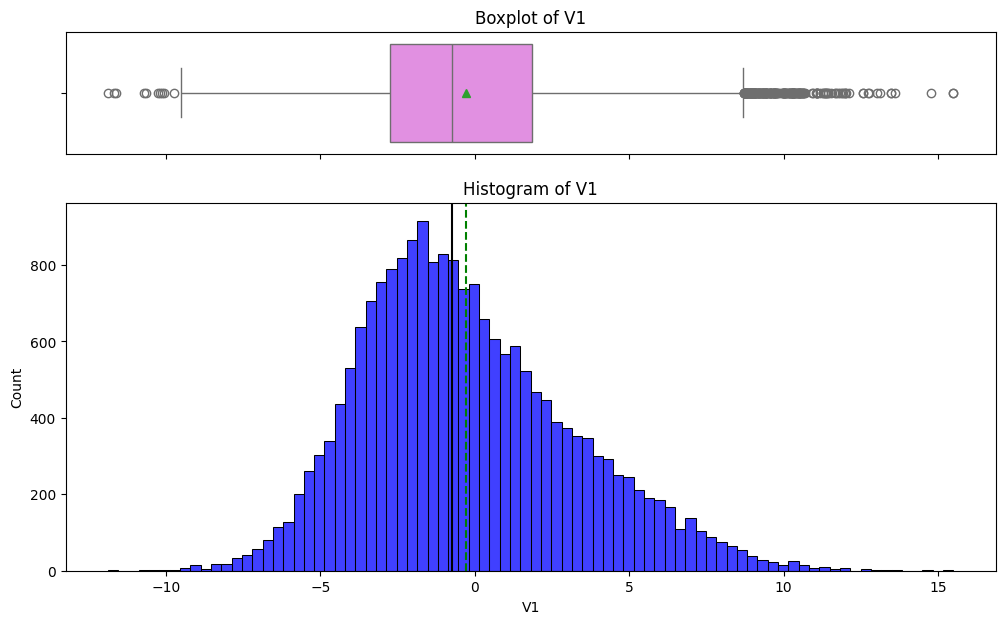

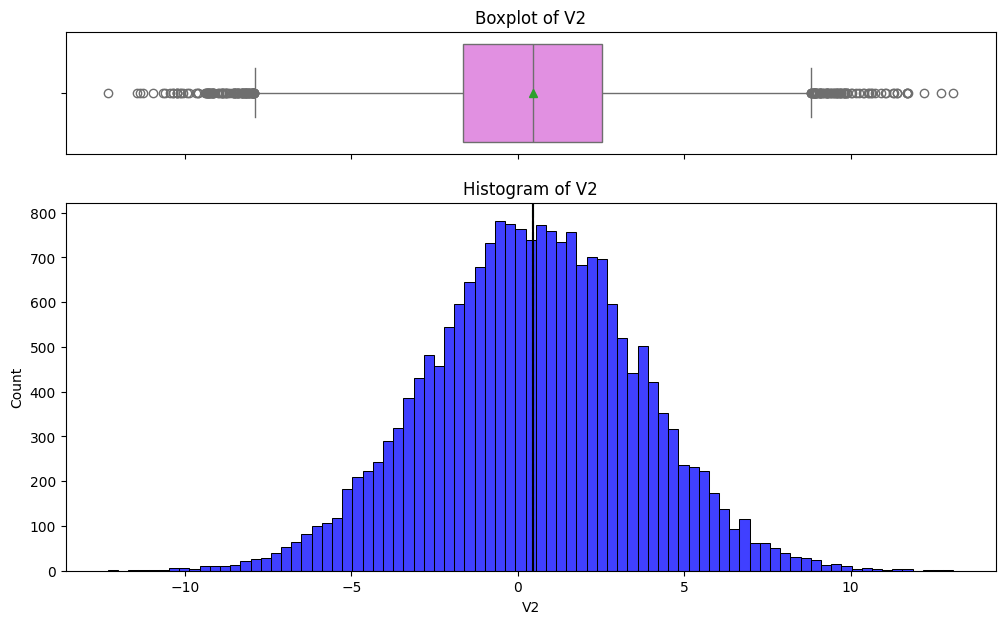

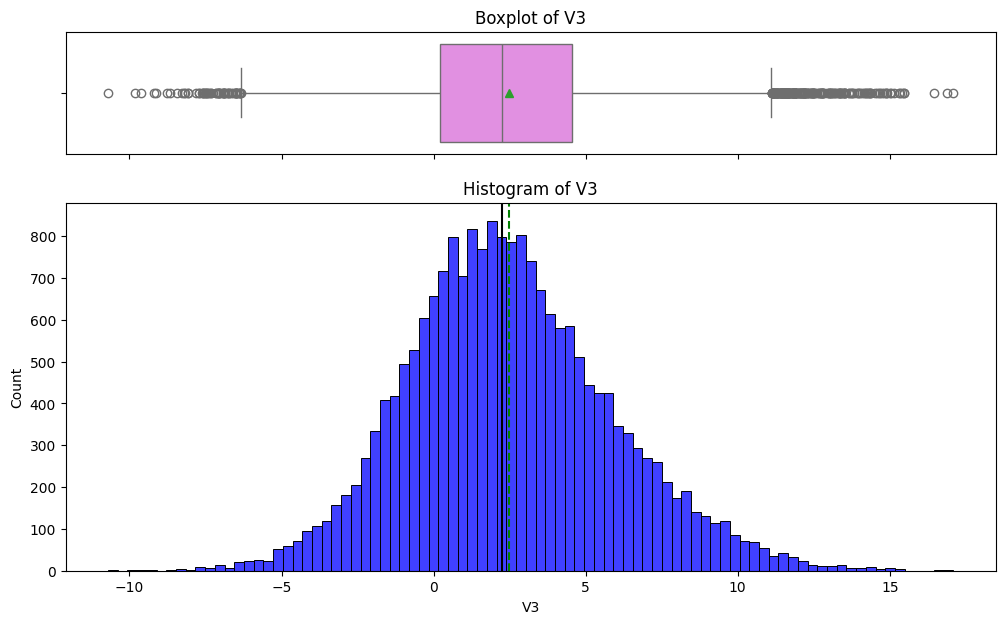

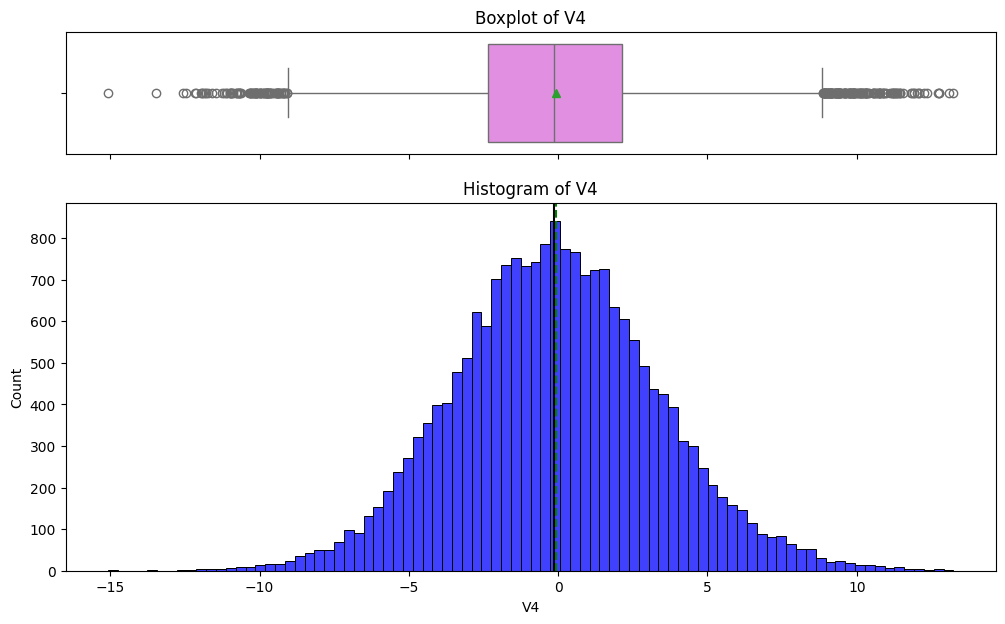

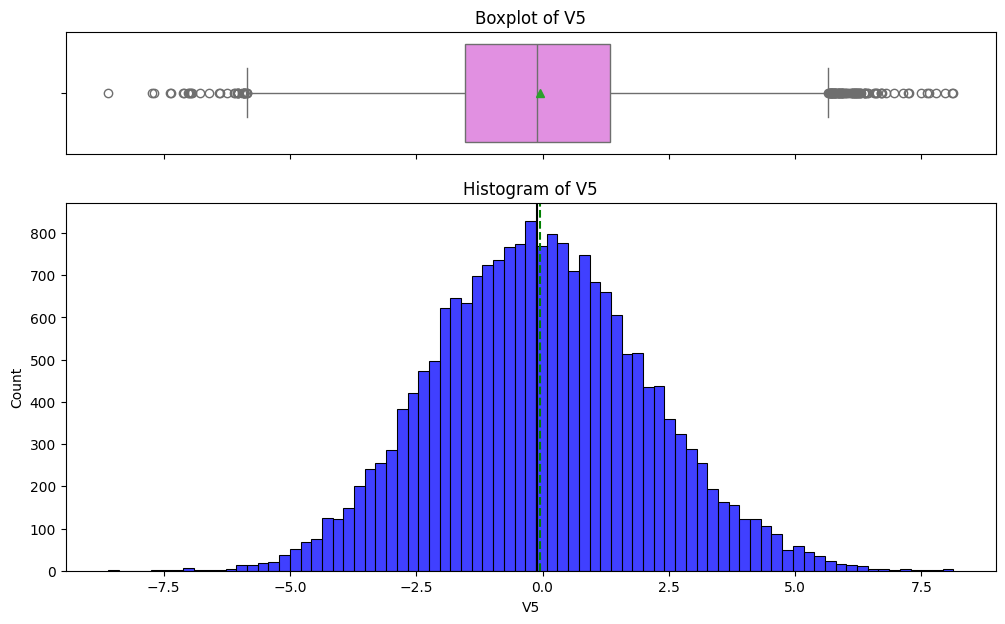

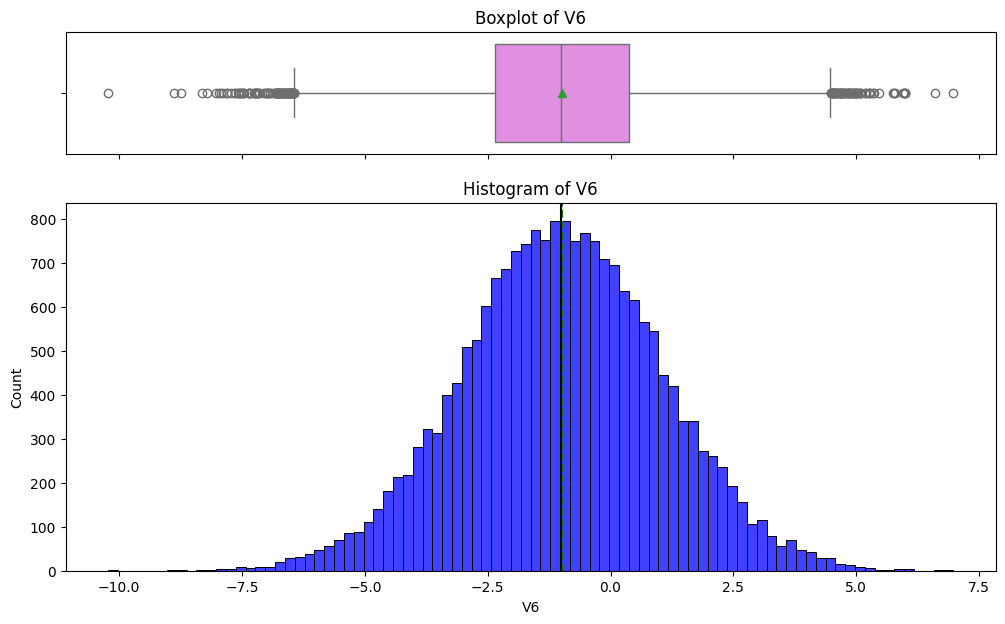

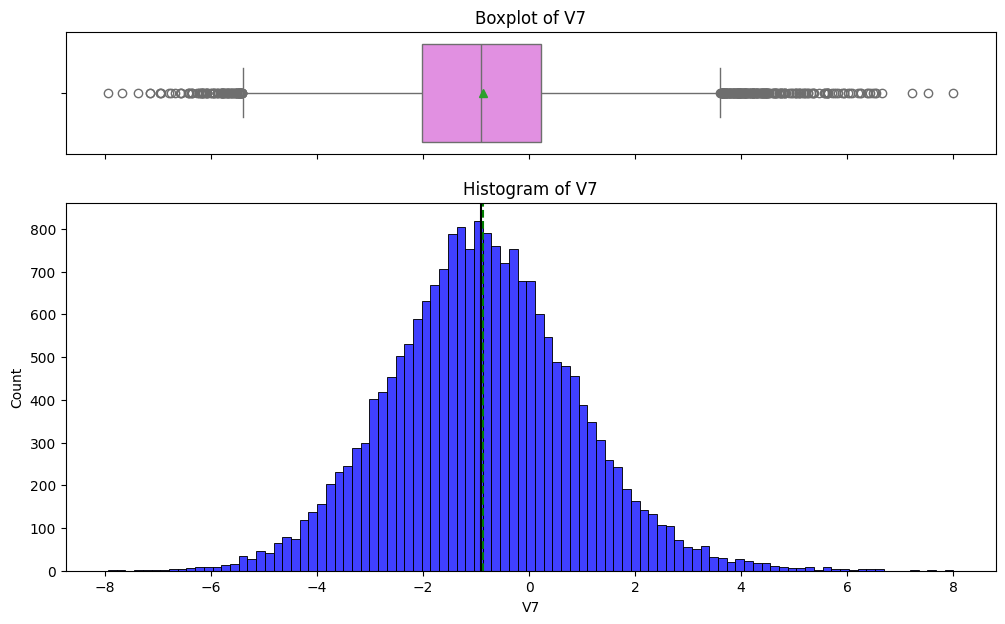

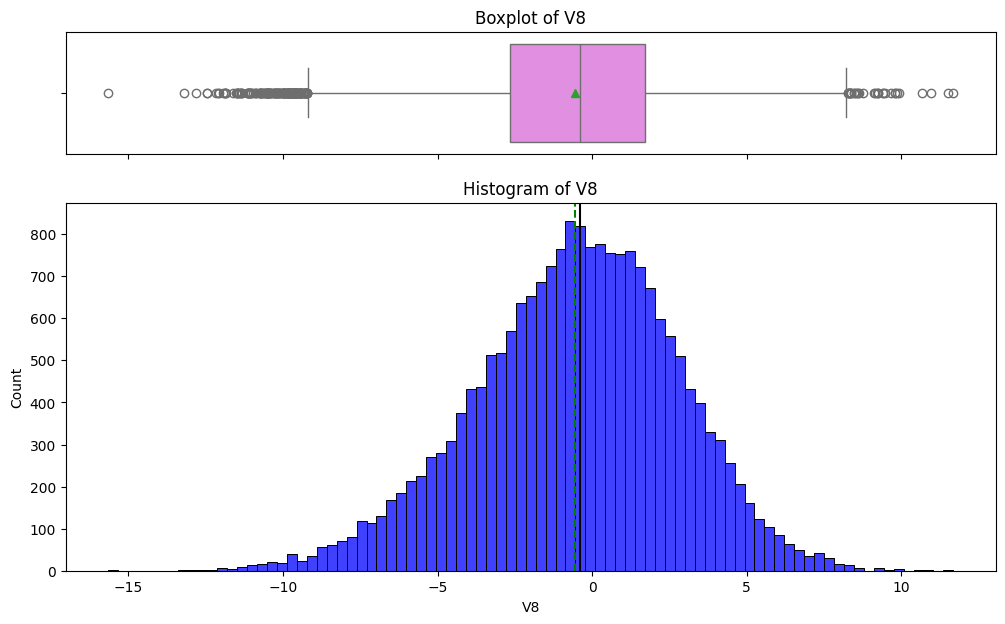

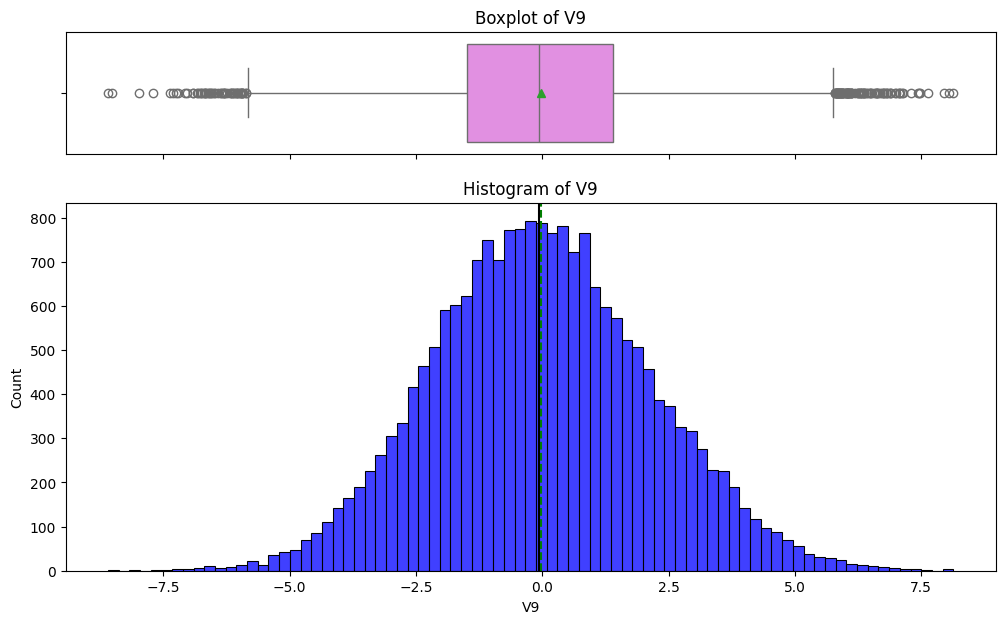

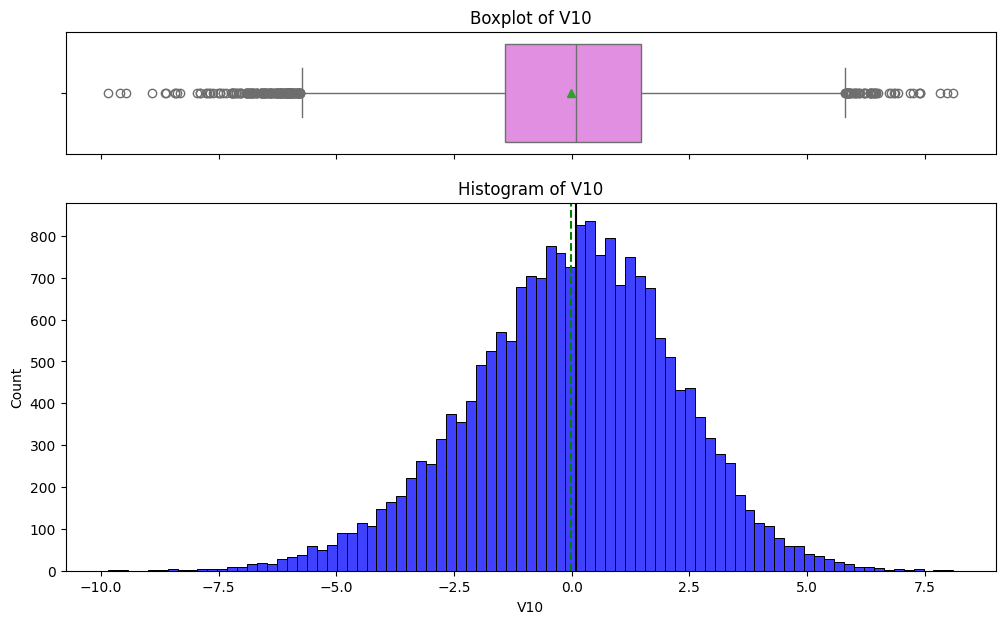

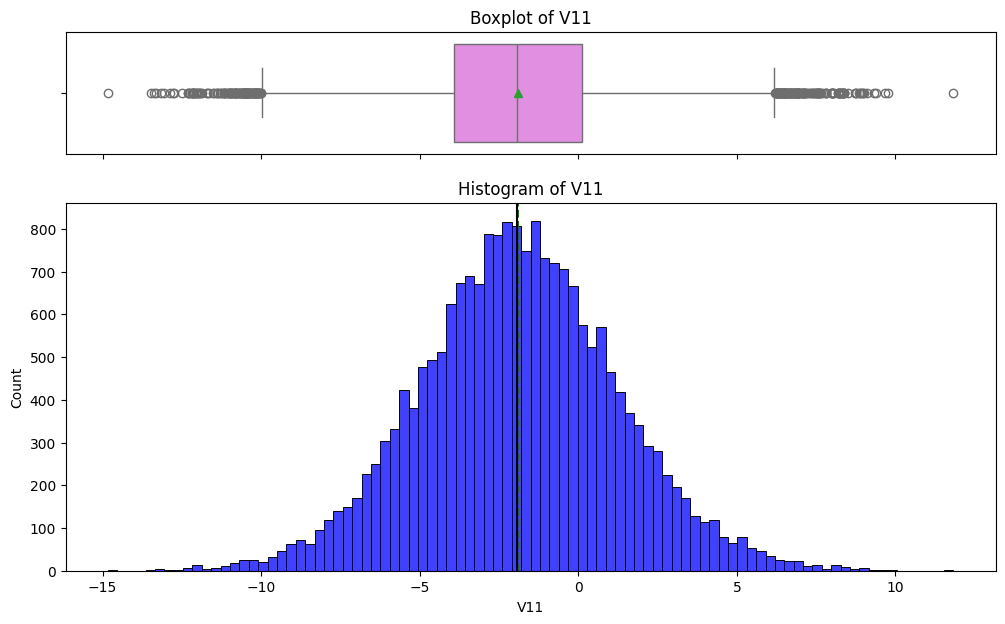

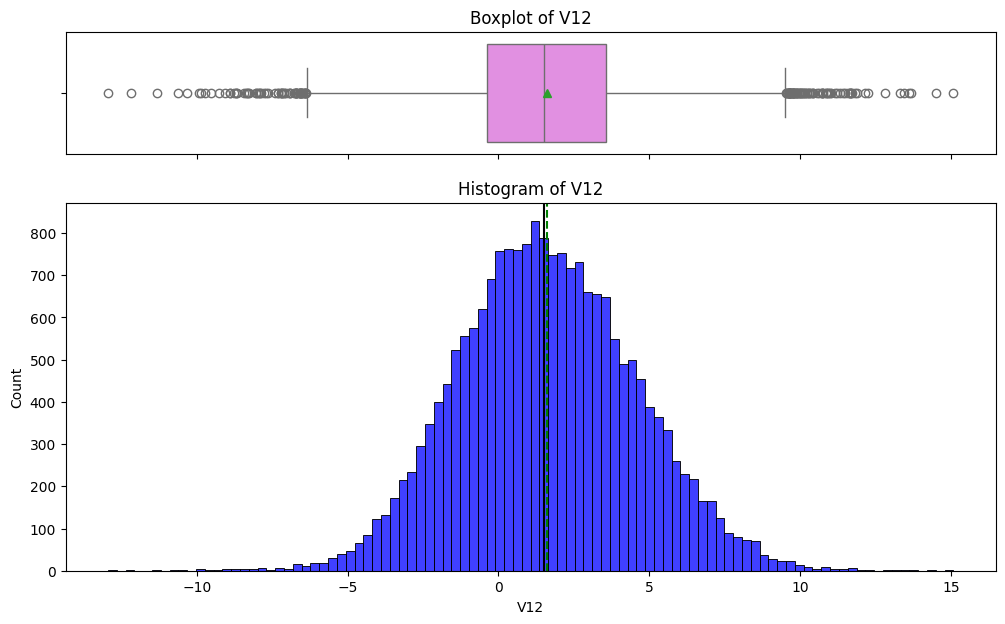

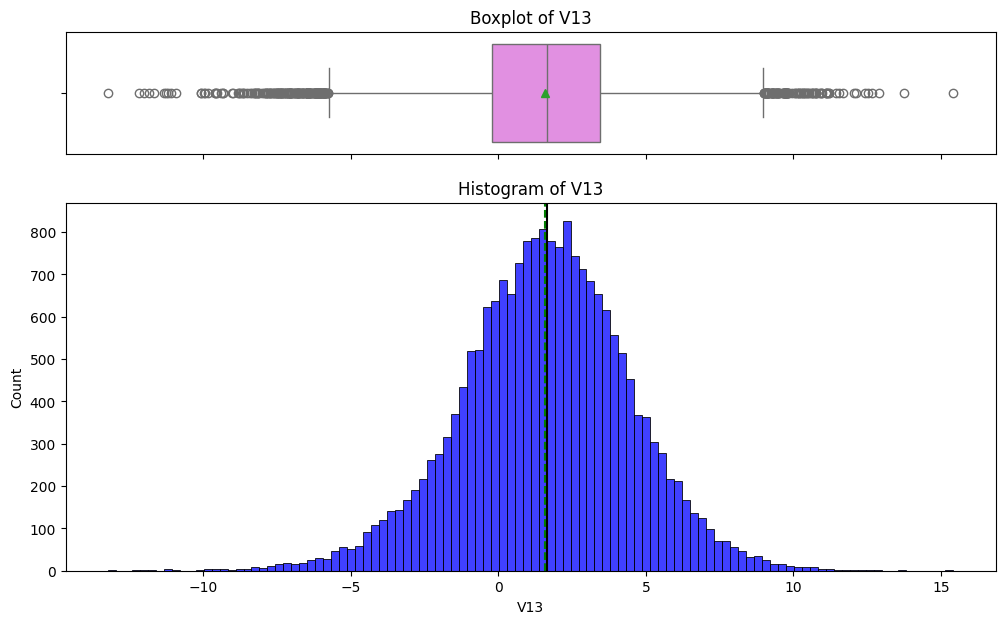

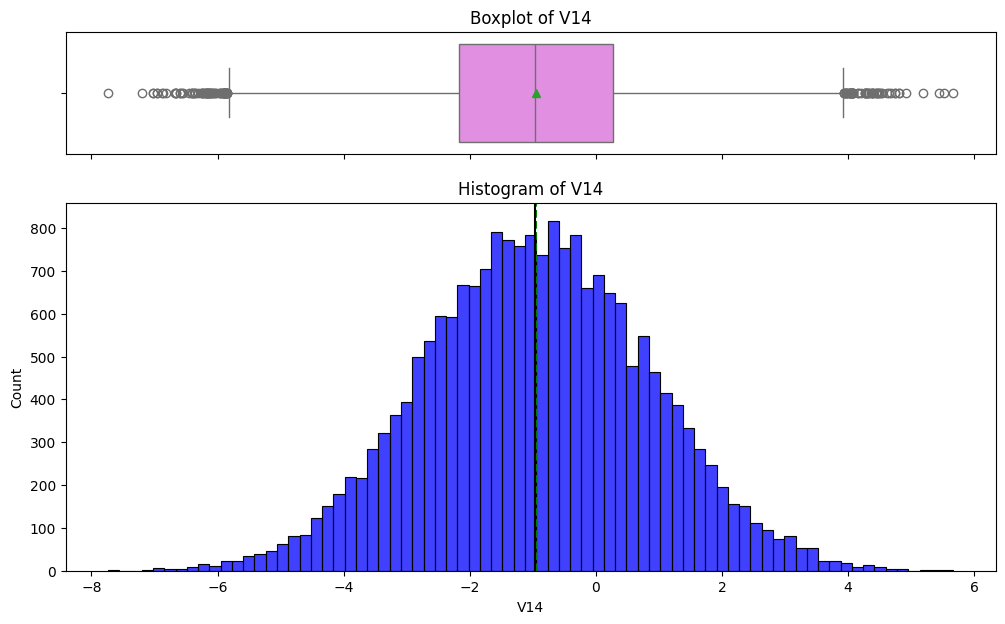

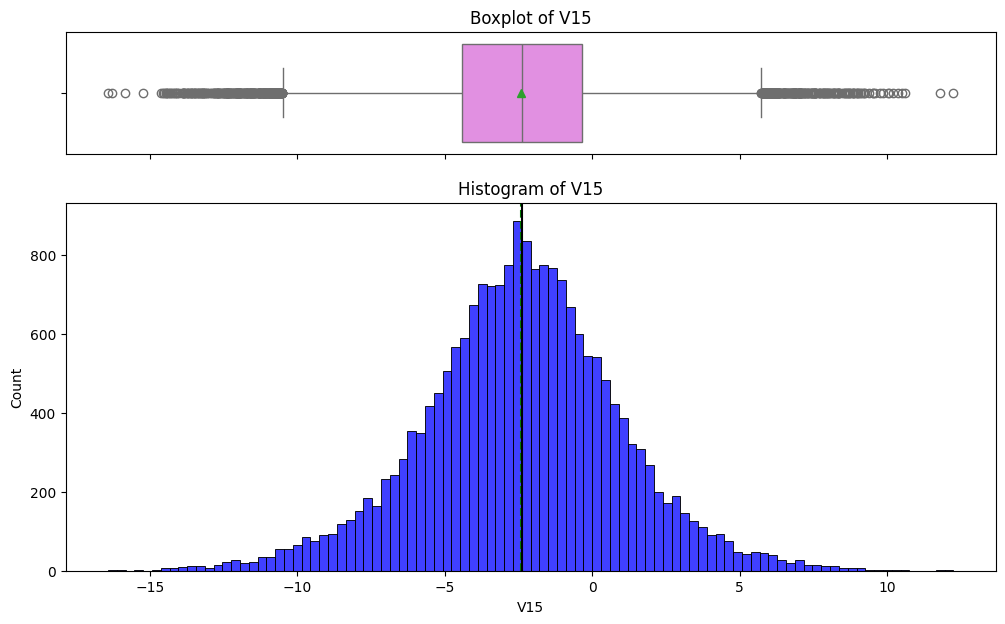

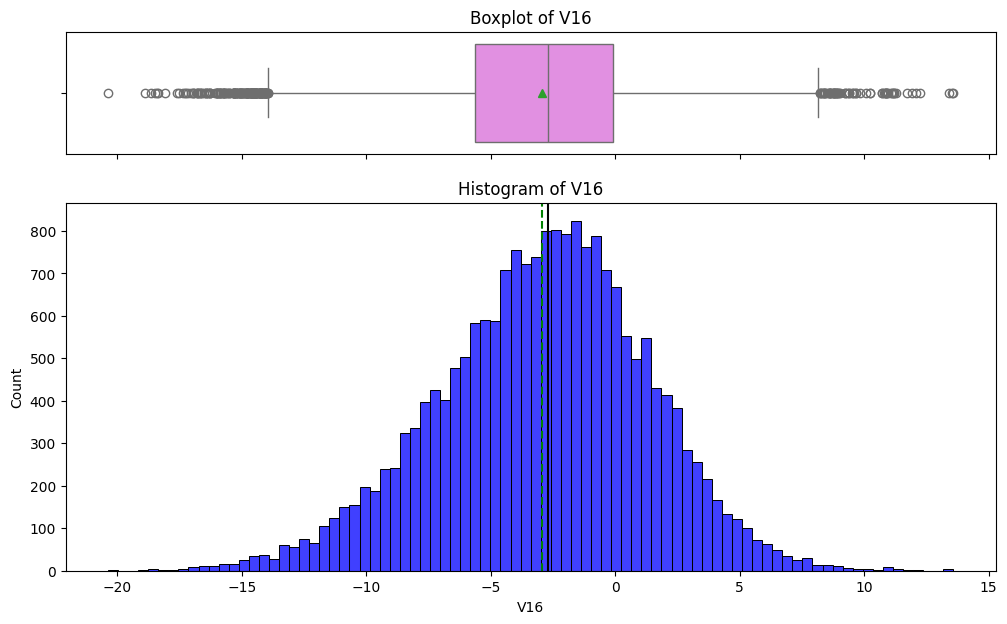

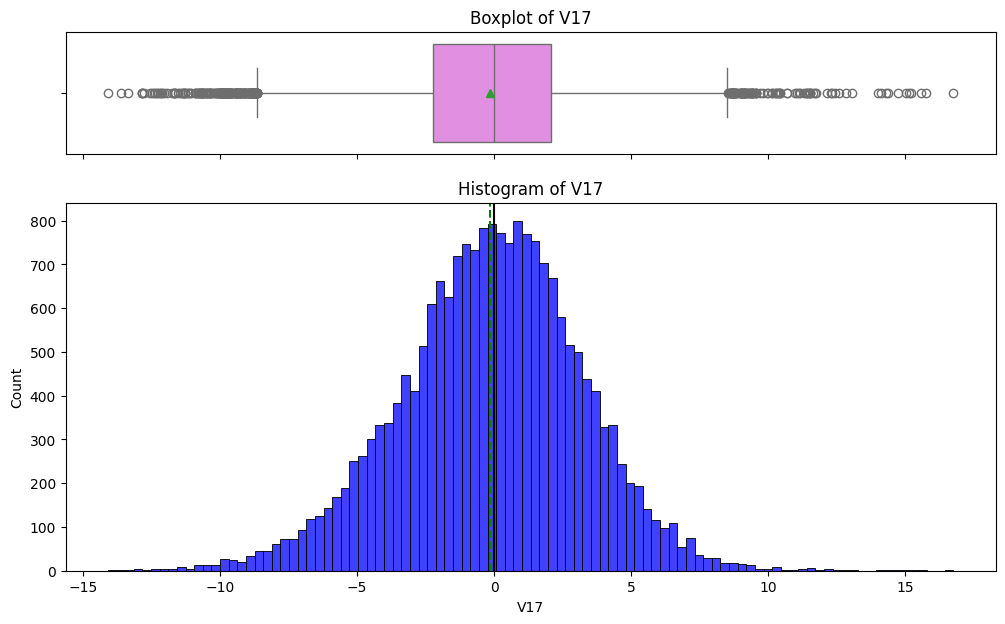

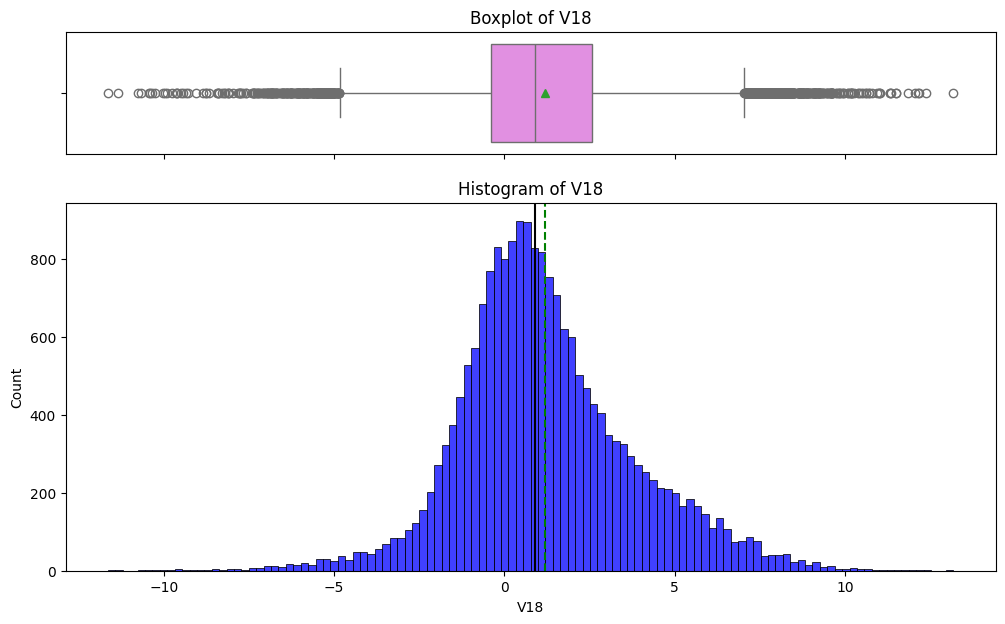

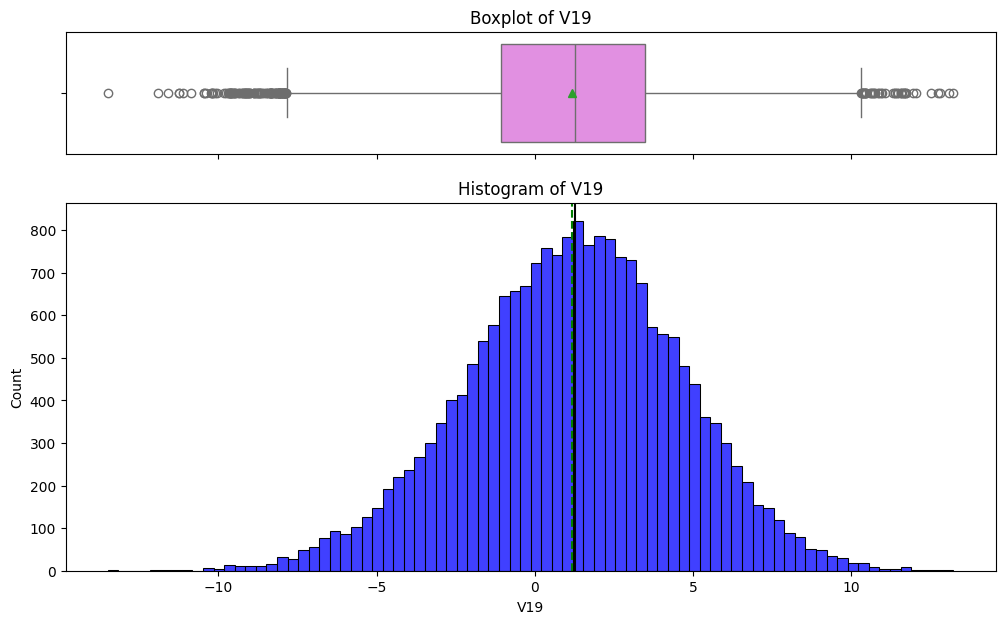

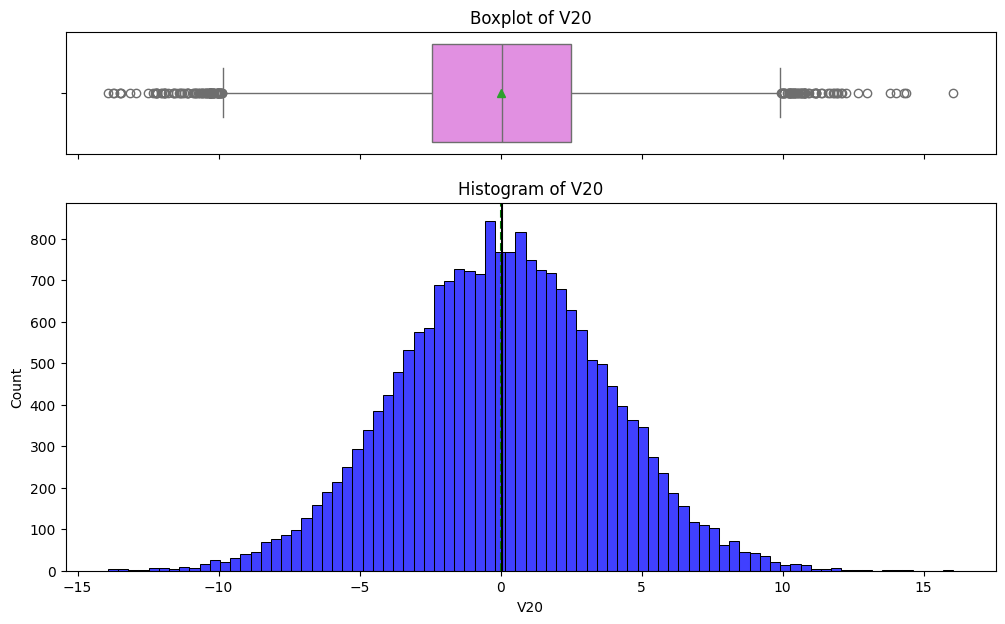

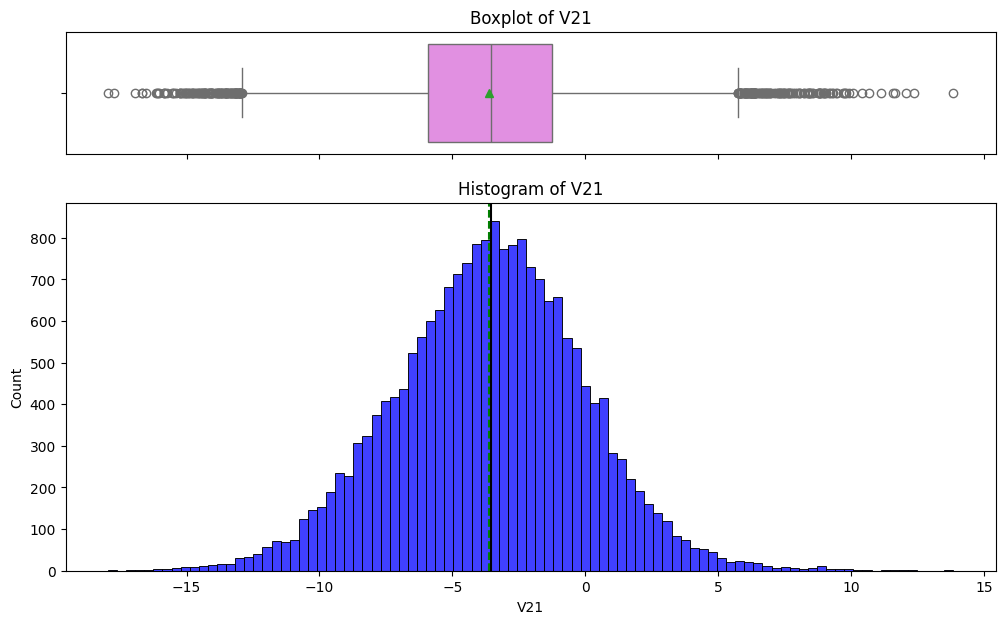

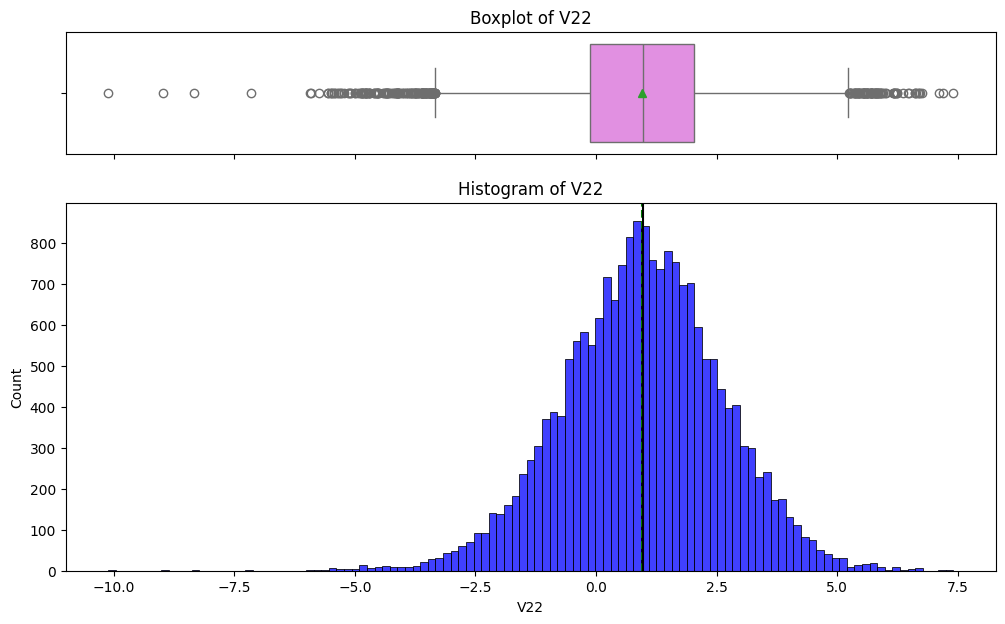

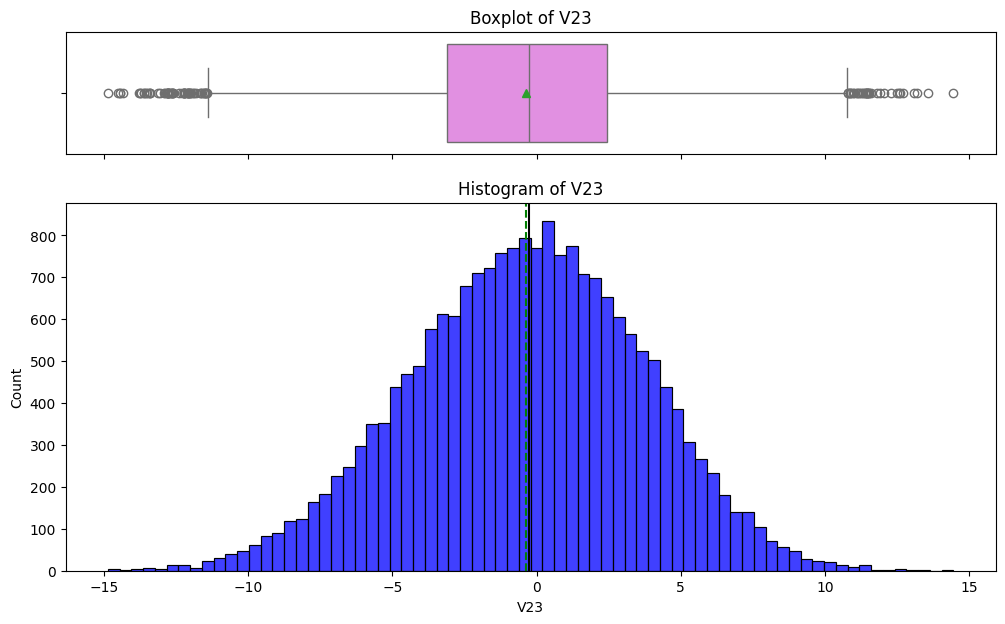

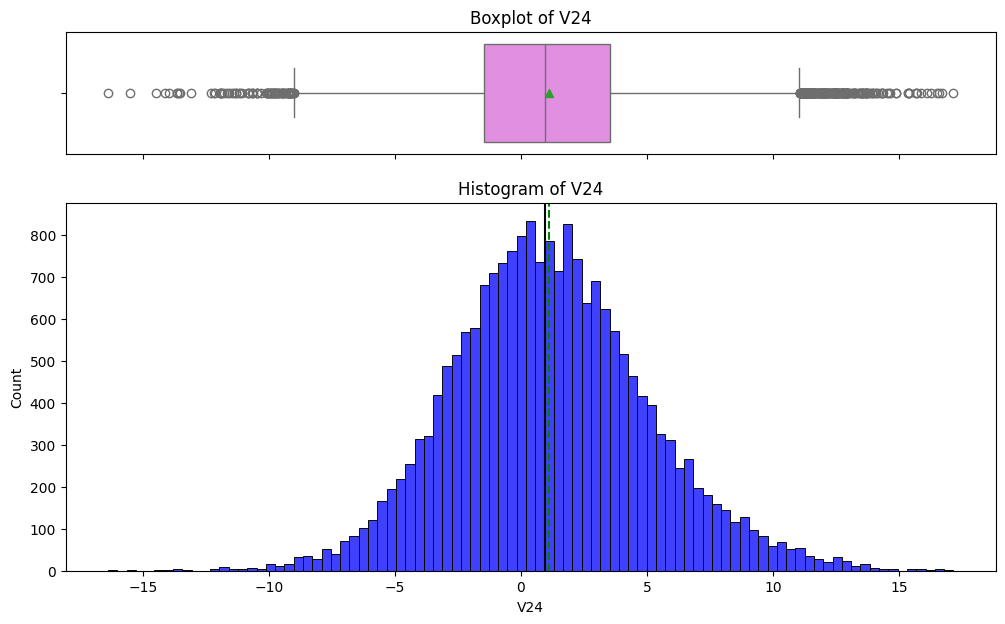

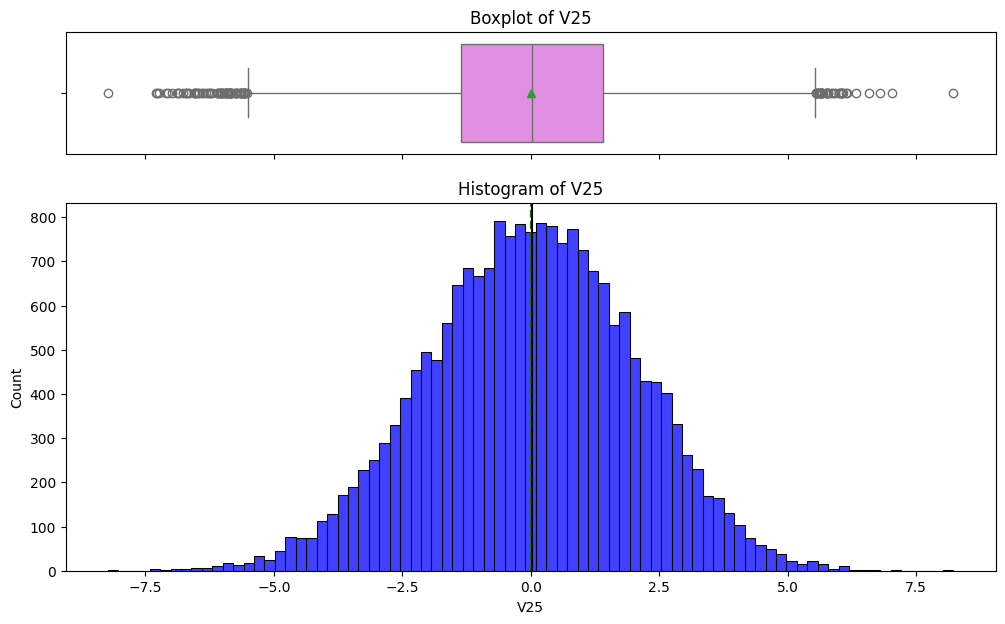

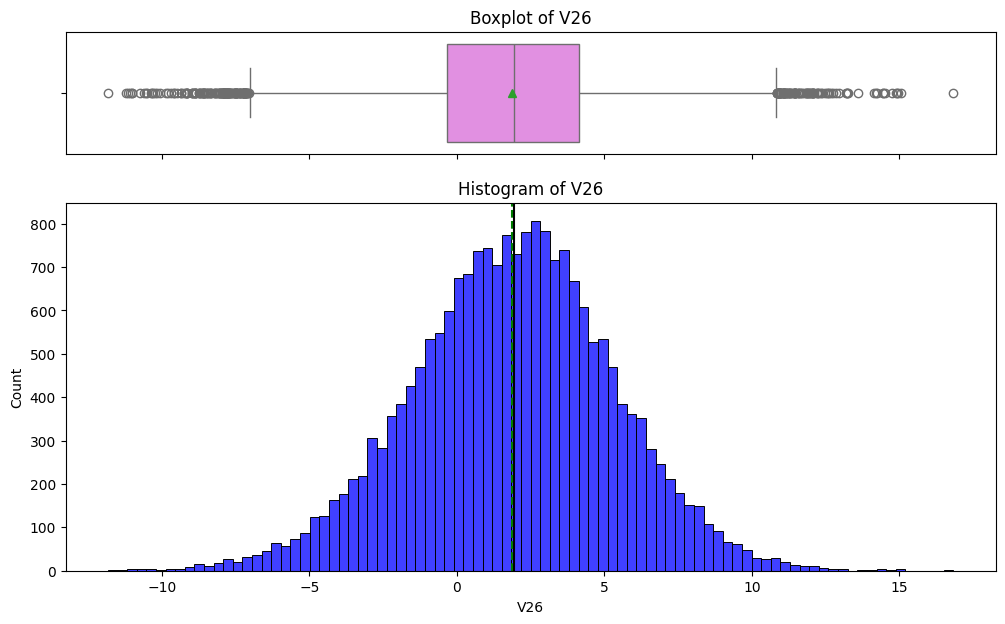

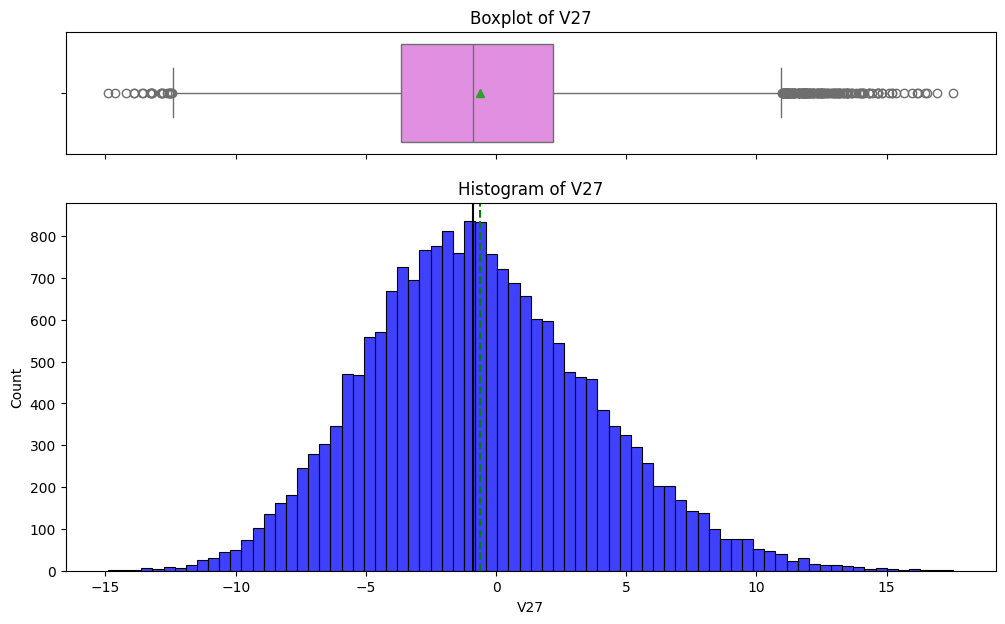

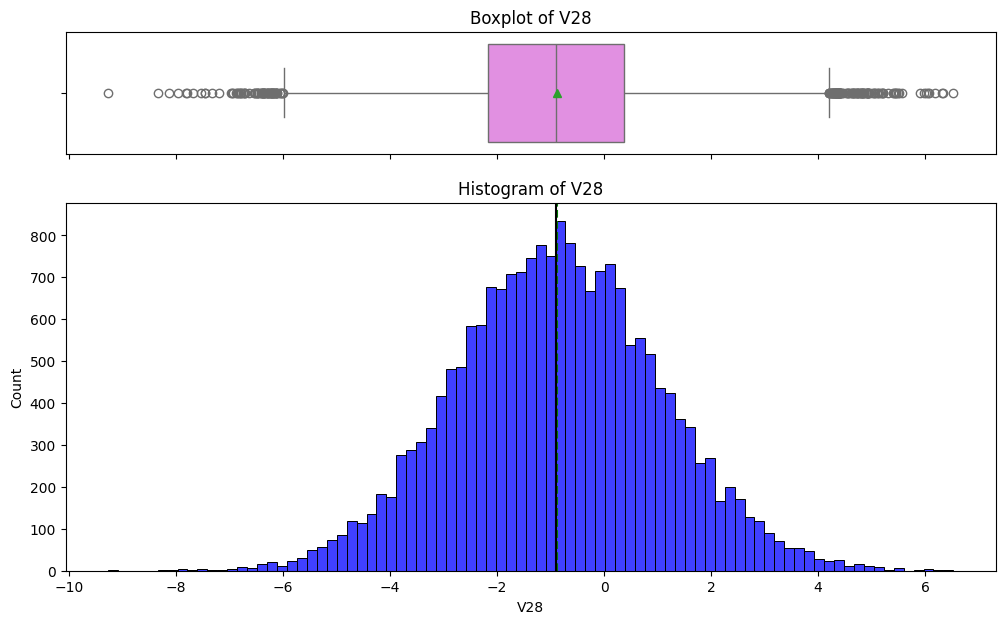

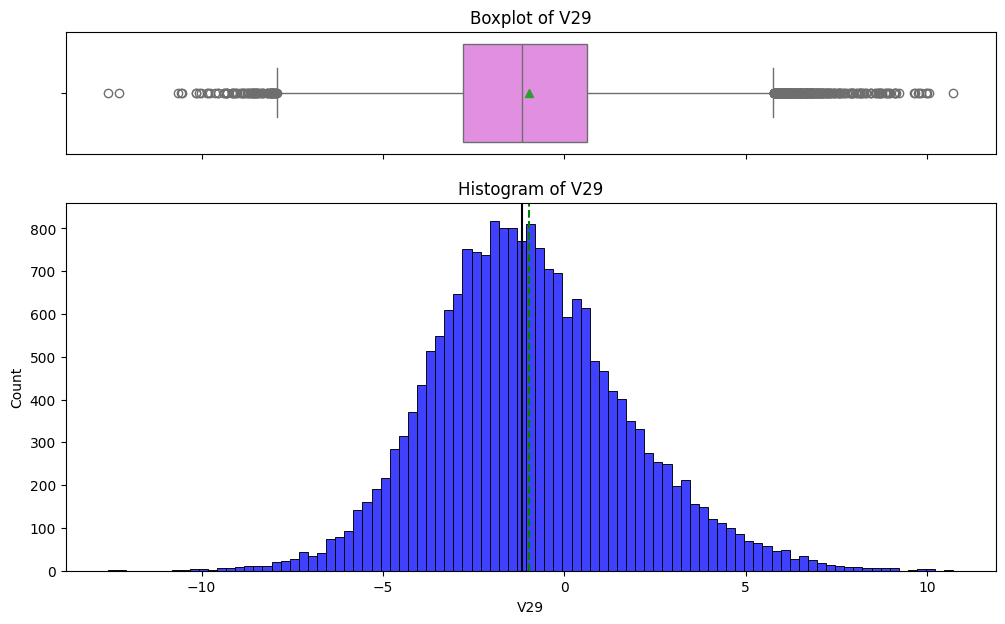

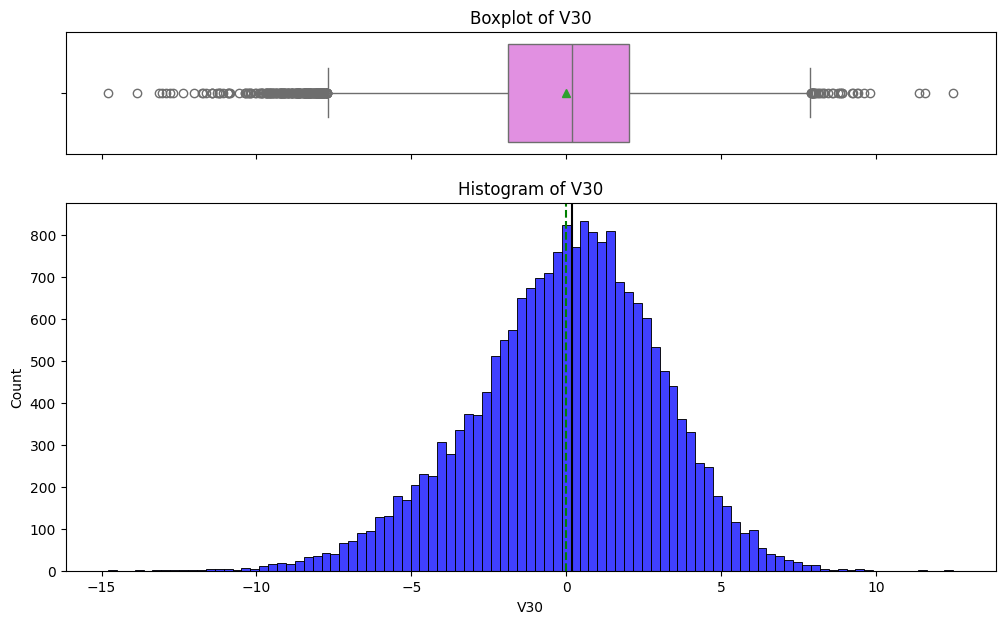

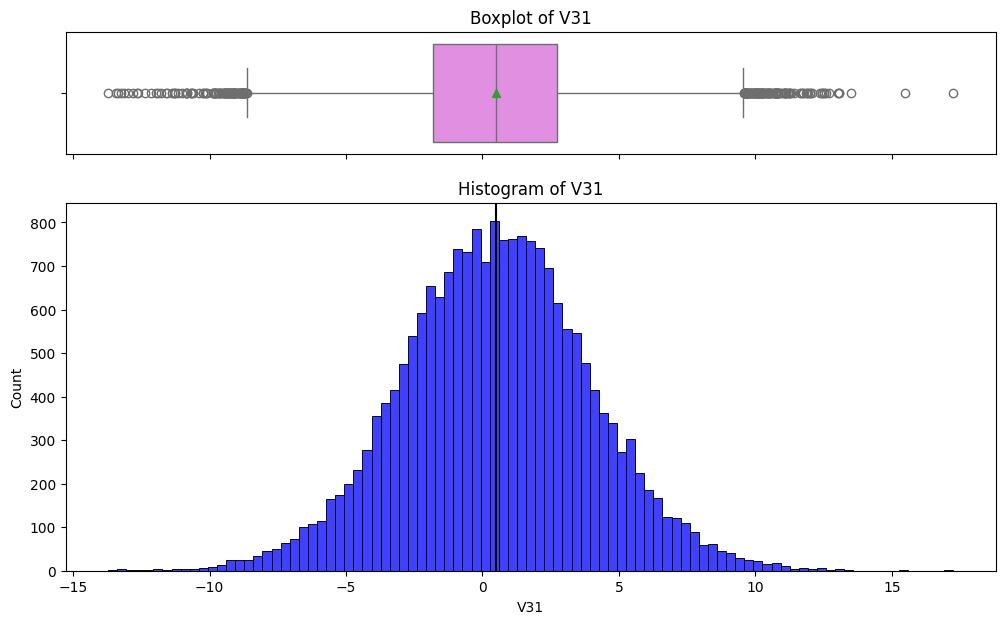

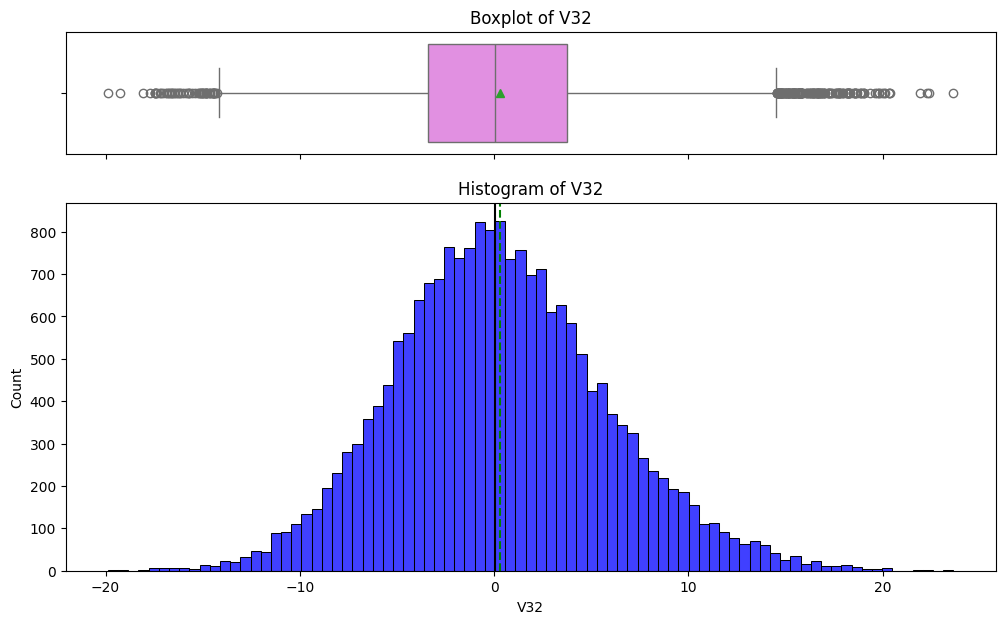

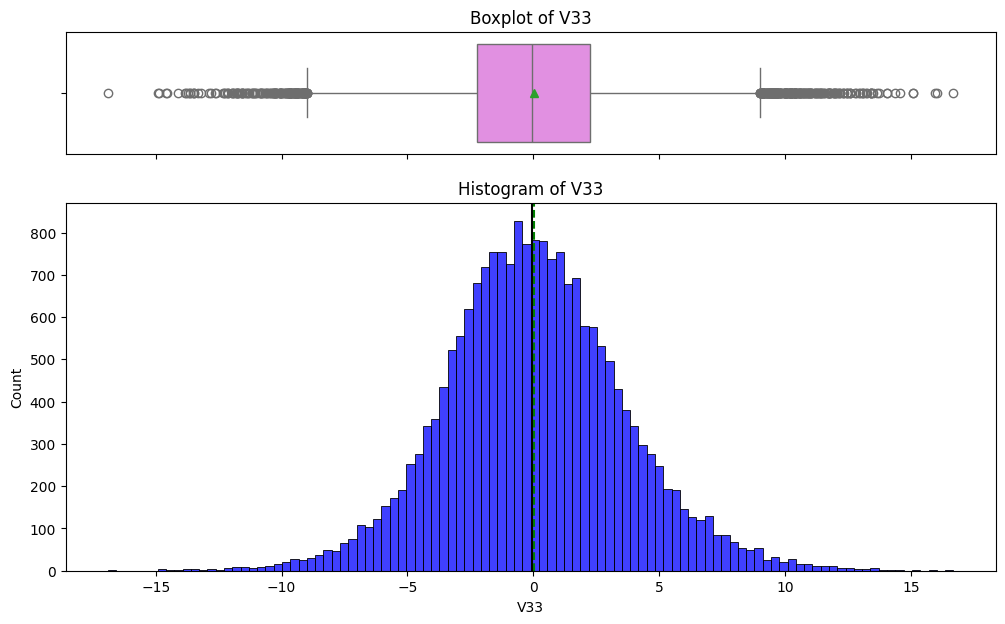

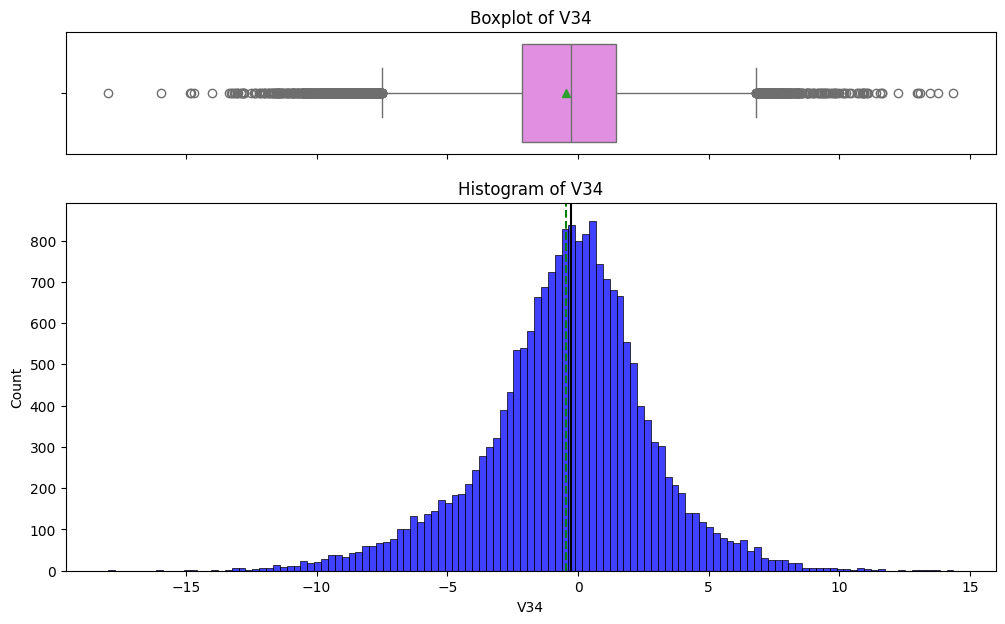

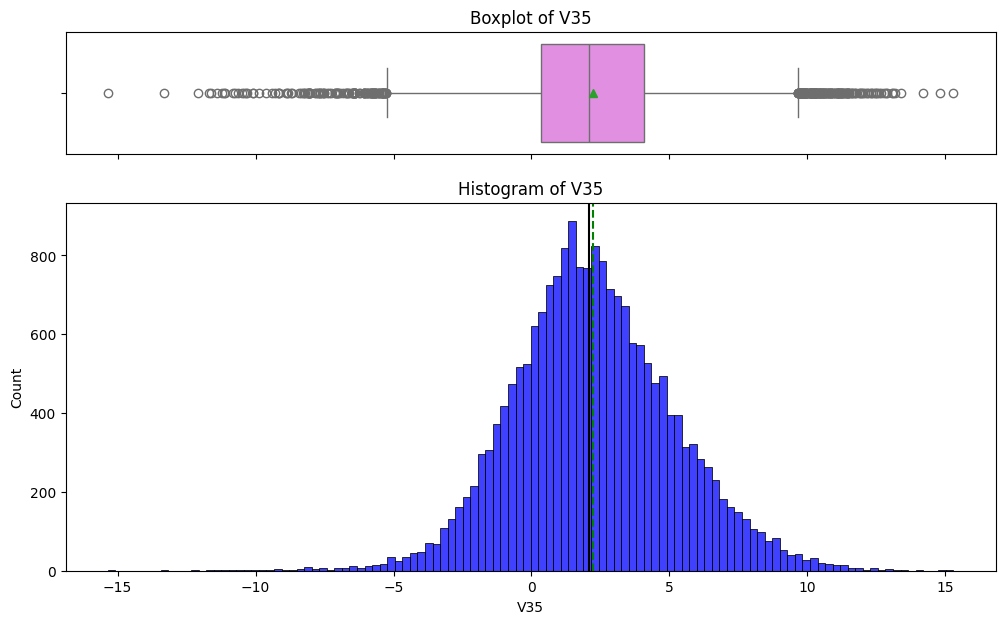

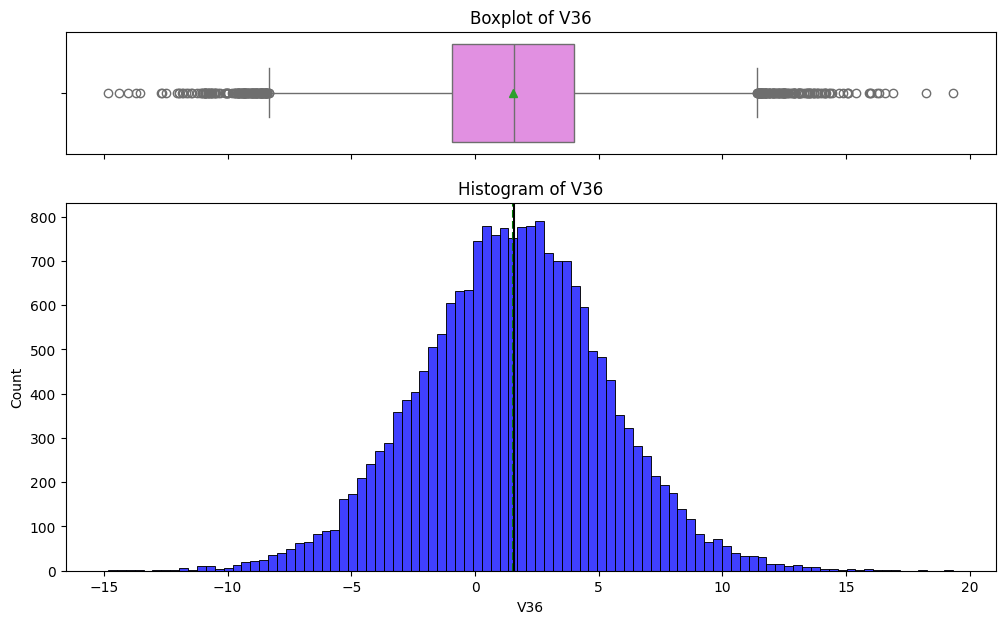

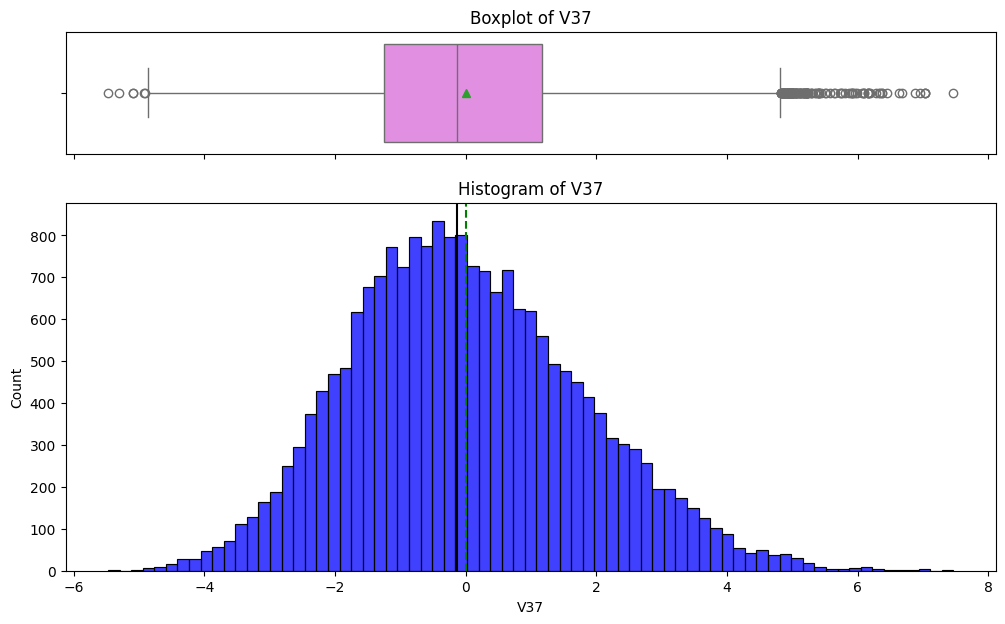

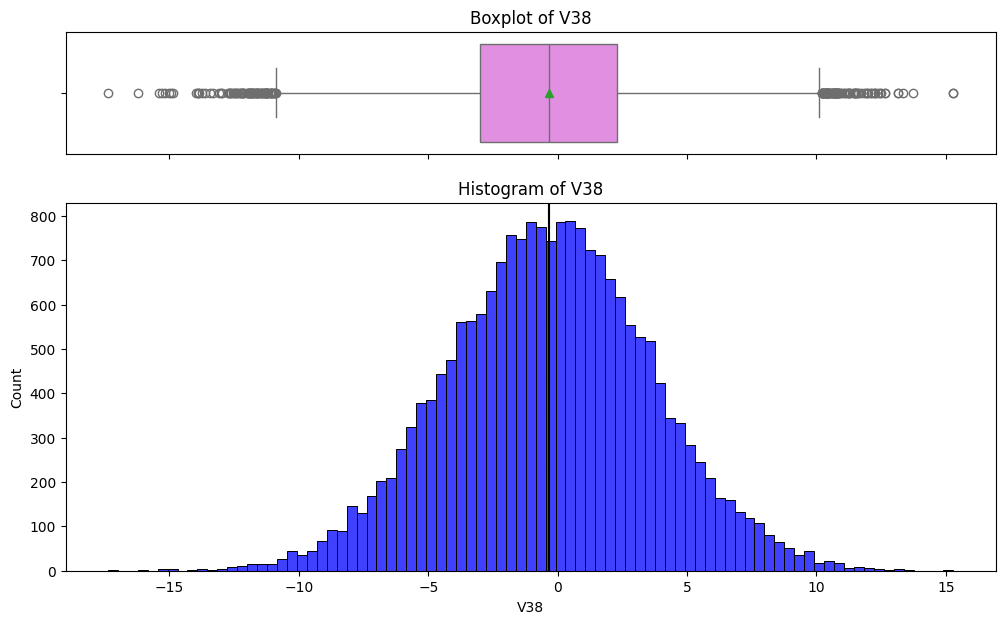

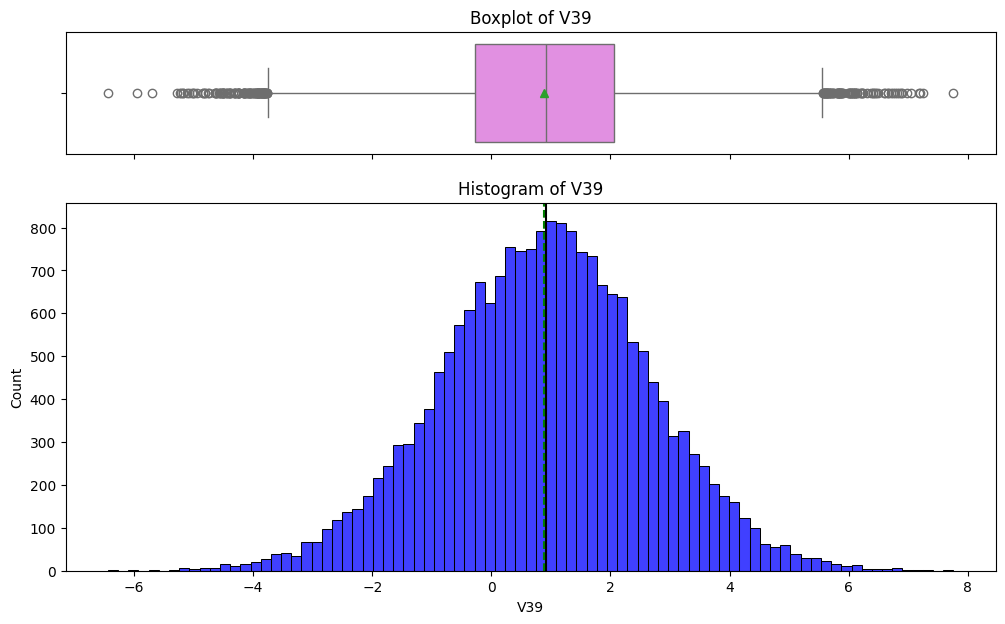

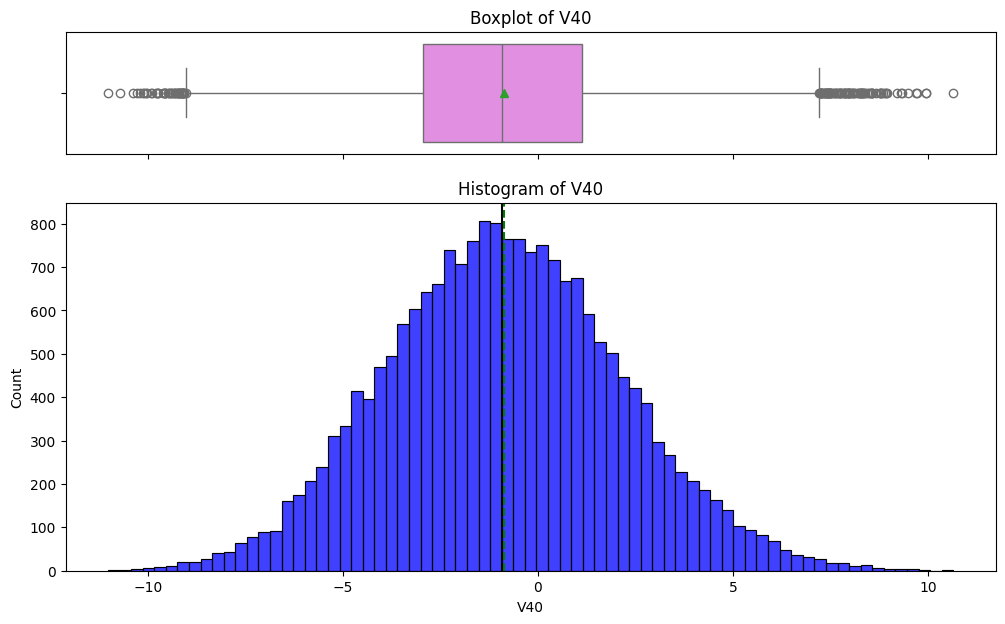

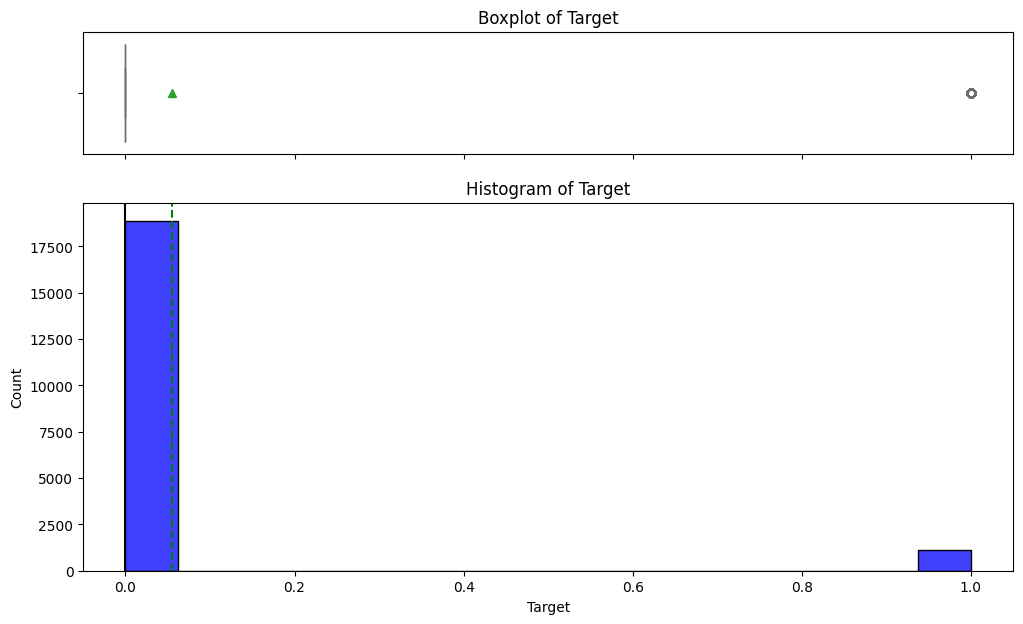

In [ ]:
# Generate boxplot and histogram for each feature in the training dataset
for feature in data_train.columns:
  # Call the histogram_boxplot function for each feature
  histogram_boxplot(
      data_train, # Source dataframe
      feature, # Feature to visualize
      figsize=(12, 7), # Set figure size
      kde=False, # Disable density curve
      bins=None # Use default histogram bins
      )

**Observations:**
* The exploratory data analysis (EDA) plots indicate that most variables (V1–V40) exhibit continuous numerical distributions with varying spreads and ranges. Several variables appear approximately symmetric around the center, while others show moderate skewness and the presence of extreme values or potential outliers, as reflected in the boxplots. The distributions also contain both negative and positive values, supporting the earlier observation that the dataset has likely undergone transformation or standardization before being provided by ReneWind.

* The histograms suggest that the variables have different distribution patterns and variances, indicating that additional feature scaling is appropriate before training the neural network model. The boxplots further show that some features contain observations far from the interquartile range, which is common in sensor-based industrial datasets and may represent operational variability or abnormal turbine conditions rather than data entry errors.

* The Target variable distribution is highly imbalanced, with the majority of observations belonging to class “0” (No Failure) and only a small proportion belonging to class “1” (Failure). This imbalance is consistent with predictive maintenance datasets, where actual machine failures occur relatively infrequently compared to normal operating conditions.

* Overall, the EDA results indicate that the dataset is numerically consistent, suitable for machine learning analysis, and appropriately prepared for subsequent classification modeling after handling missing values and applying feature scaling and standardization.

## **6.b. Bivariate Analysis**

* Bivariate analysis is conducted to examine the relationships between two variables within the dataset. This analysis helps identify patterns, associations, correlations, and differences between variables, particularly between predictor variables and the target variable.

* In this study, bivariate analysis is performed to understand how the predictor variables (V1–V40) relate to the Target variable and to evaluate the relationships among features. Visualization techniques such as correlation heatmaps, scatter plots, and comparative boxplots may be used to identify important patterns and potential predictors associated with generator failure.

* The results of bivariate analysis provide deeper insight into the dataset structure and support the development of machine learning models by identifying relevant relationships between variables.

### **6.b.1. Correlation Analysis Among Predictor Variables**

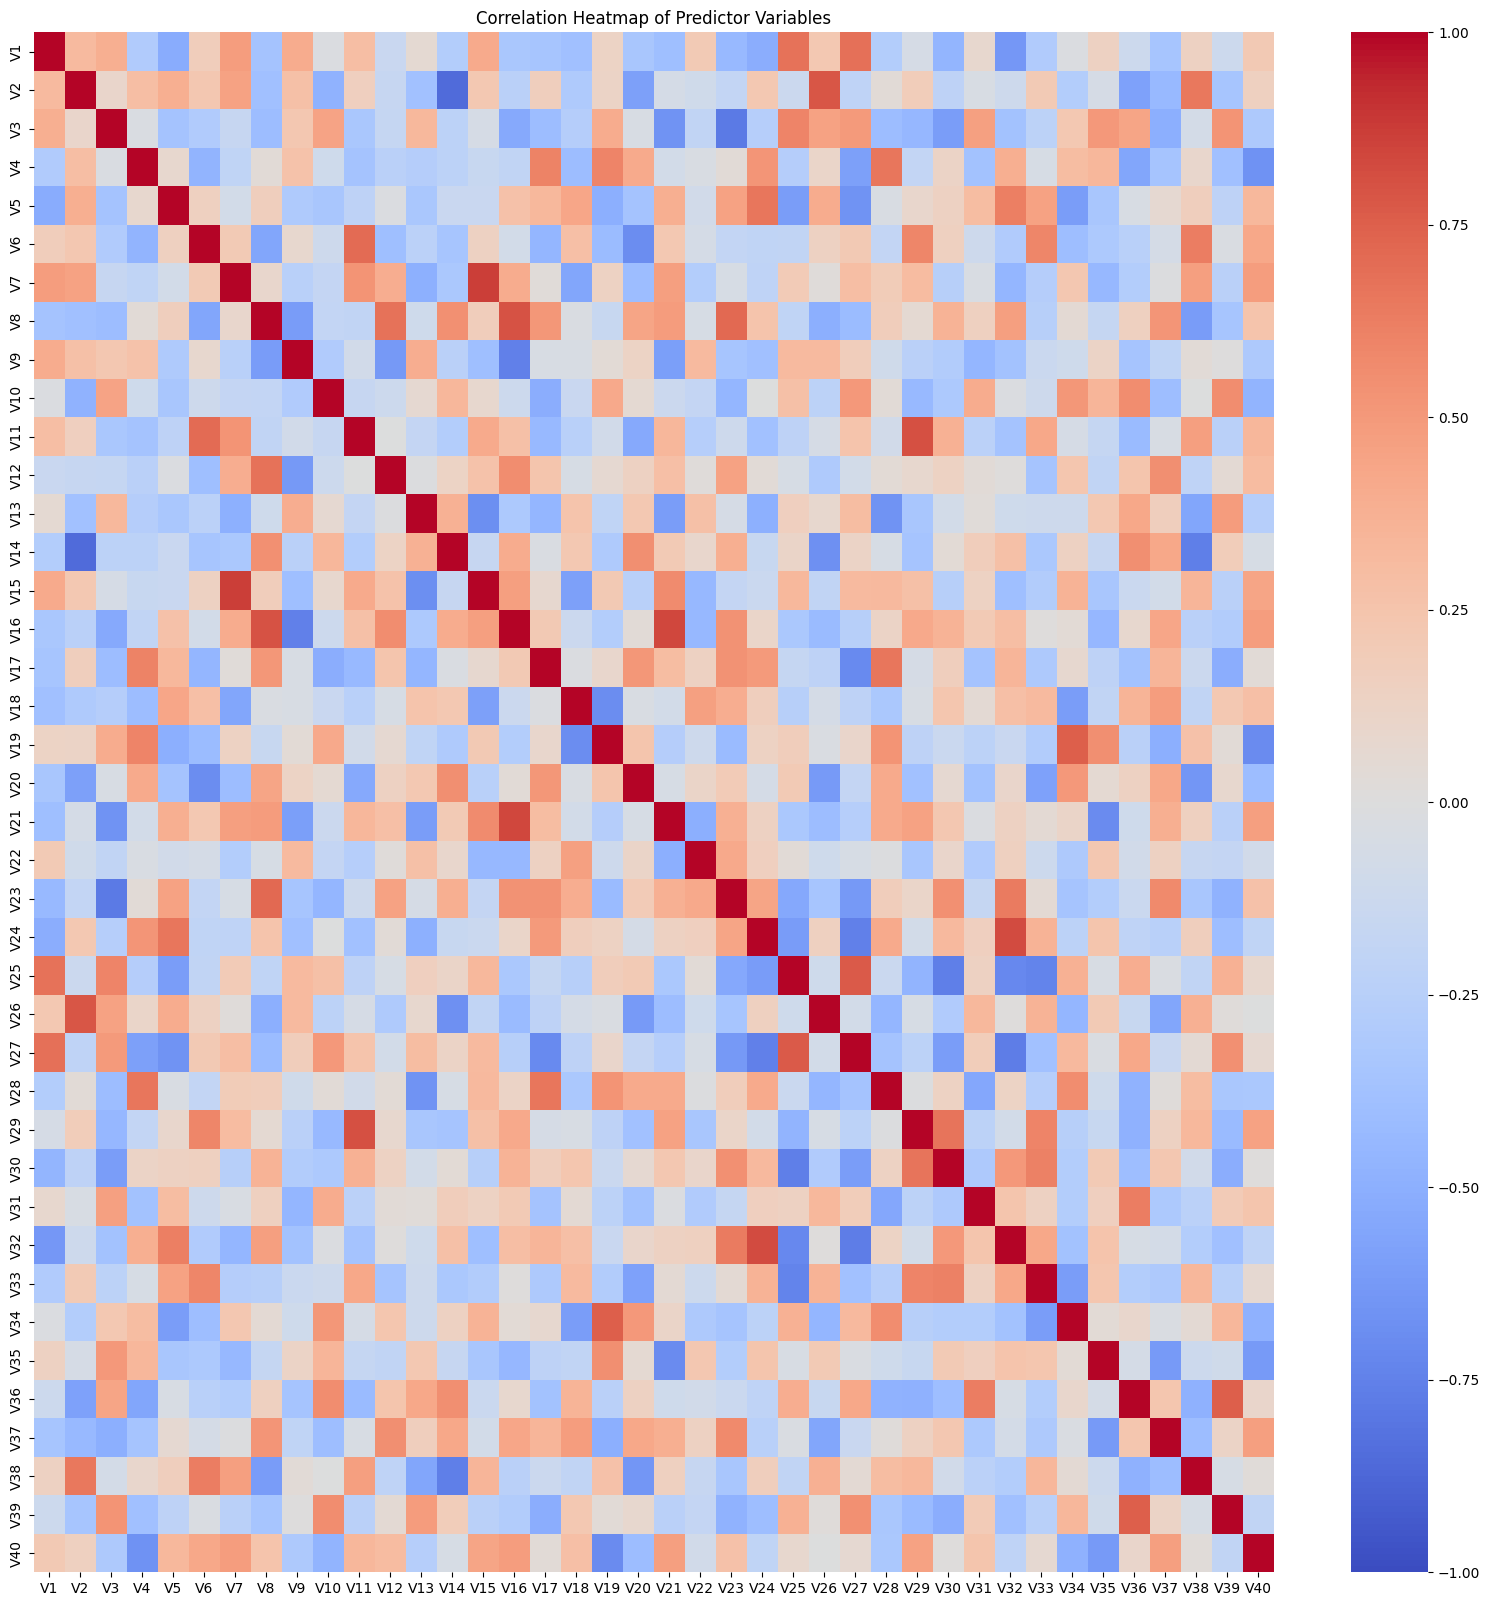

In [ ]:
# Select only numerical columns from the training dataset
cols_list = data_train.select_dtypes(include=np.number).columns.tolist()

# Remove the Target column to analyze correlations among predictor variables only
cols_list.remove("Target")

# Create figure with specified size
plt.figure(figsize=(20, 20))

# Generate correlation heatmap for predictor variables
sns.heatmap(
    data_train[cols_list].corr(),  # Compute correlation matrix for selected features
    annot=False,                   # Do not display correlation values inside cells
    cmap="coolwarm",               # Set heatmap color palette
    vmin=-1,                       # Set minimum correlation value
    vmax=1                         # Set maximum correlation value
)

# Add title to the heatmap
plt.title("Correlation Heatmap of Predictor Variables")

# Import os module for directory and file operations
import os

# Create folder
os.makedirs("2. Correlation_Heatmap_among_Predictor_Variables", exist_ok=True)

# Save figure into folder
plt.savefig(f"2. Correlation_Heatmap_among_Predictor_Variables/{feature}.png", bbox_inches='tight')

# Display the heatmap
plt.show()

**Observations:**
* The correlation heatmap illustrates the relationships among the predictor variables (V1–V40) in the training dataset. The color intensity represents the strength and direction of the correlations, where red indicates positive correlation, blue indicates negative correlation, and lighter colors indicate weak or near-zero correlation.

* Most predictor variables exhibit weak to moderate correlations with one another, suggesting that the dataset does not contain severe multicollinearity among features. Several variable pairs show moderate positive and negative relationships, which may indicate interactions among sensor measurements collected from different wind turbine components and environmental conditions.

* The strong red diagonal line from the upper-left to the lower-right corner represents perfect self-correlation, where each variable has a correlation value of 1 with itself. Outside the diagonal, the correlations are relatively distributed without extremely dominant relationships, indicating that most features provide distinct information to the machine learning model.
* Overall, the heatmap suggests that the predictor variables maintain sufficient variability and independence, making the dataset suitable for neural network modeling and predictive maintenance analysis.

### **6.b.2. Correlation Between Predictor Variables and Target Variable**

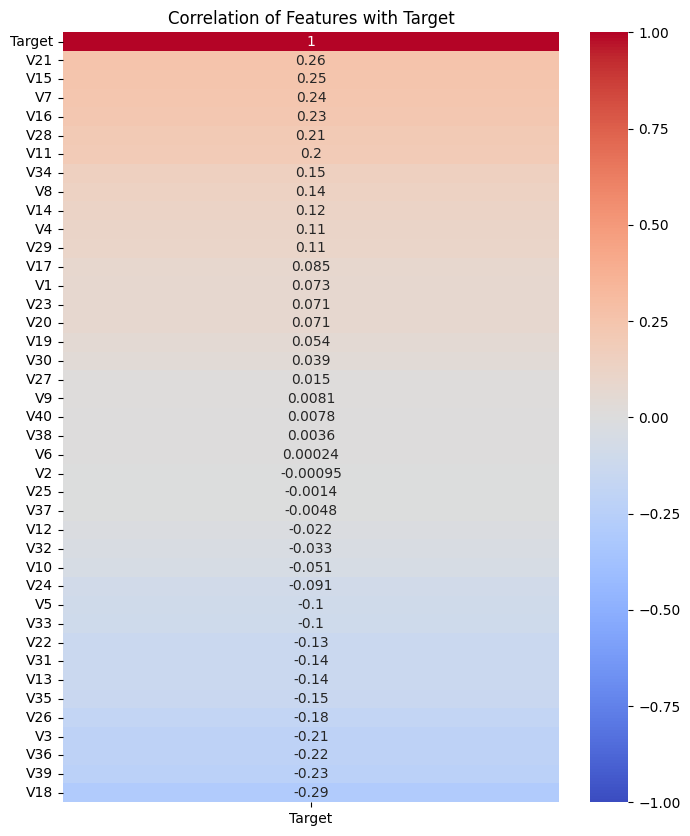

In [ ]:
# Create figure with specified size
plt.figure(figsize=(8,10))

# Compute correlations between all variables and the Target variable
target_corr = data_train.corr()[['Target']].sort_values(
    by='Target',           # Sort variables based on correlation with Target
    ascending=False        # Sort from highest to lowest correlation
)

# Generate heatmap of feature correlations with the Target variable
sns.heatmap(
    target_corr,           # Correlation values with Target
    annot=True,            # Display correlation coefficients inside cells
    cmap='coolwarm',       # Set heatmap color palette
    vmin=-1,               # Set minimum correlation value
    vmax=1                 # Set maximum correlation value
)

# Add title to the heatmap
plt.title('Correlation of Features with Target')

# Import os module for directory and file operations
import os

# Create folder
os.makedirs("3. Correlation_Features_with_Target", exist_ok=True)

# Save figure into folder
plt.savefig(f"3. Correlation_Features_with_Target/{feature}.png", bbox_inches='tight')

# Display the heatmap
plt.show()

**Observations:**
* The heatmap illustrates the correlation between each predictor variable and the Target variable in the training dataset. Positive correlation values indicate that the feature tends to increase as the likelihood of generator failure increases, while negative correlation values indicate an inverse relationship with failure occurrence.

* Several variables show moderate positive correlations with the Target variable, including V21 (0.26), V15 (0.25), V7 (0.24), V16 (0.23), and V28 (0.21). These variables may contain useful information for identifying generator failure conditions and could contribute significantly to the predictive maintenance model.

* Conversely, several variables exhibit moderate negative correlations with the Target variable, such as V18 (-0.29), V39 (-0.23), V36 (-0.22), and V3 (-0.21). These features may decrease as failure conditions occur and may also provide important predictive signals for classification.

* Most variables exhibit relatively weak to moderate correlations with the Target variable, suggesting that generator failure prediction is likely influenced by multiple interacting features rather than a single dominant predictor. This characteristic is common in industrial sensor datasets and supports the use of neural network models capable of capturing complex nonlinear relationships among variables.

### **6.b.3. Boxplot Distribution of Predictor Variables by Target Class**

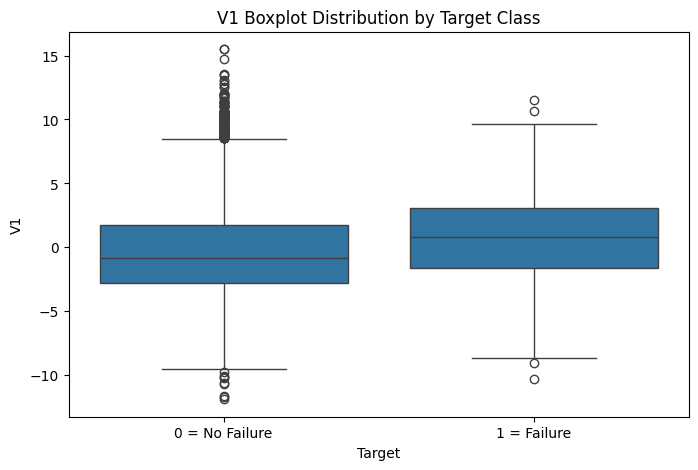

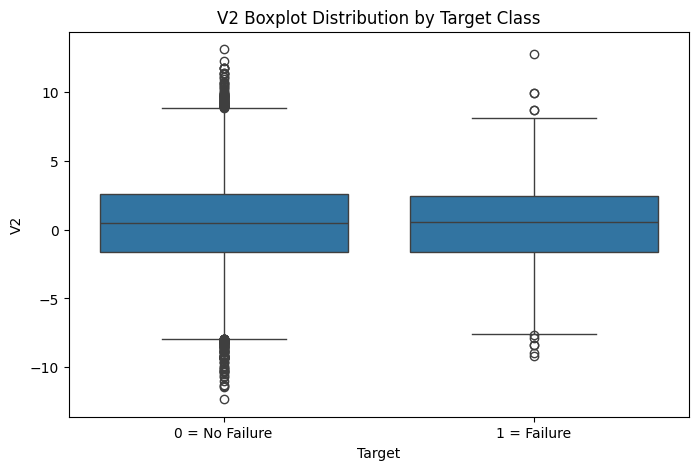

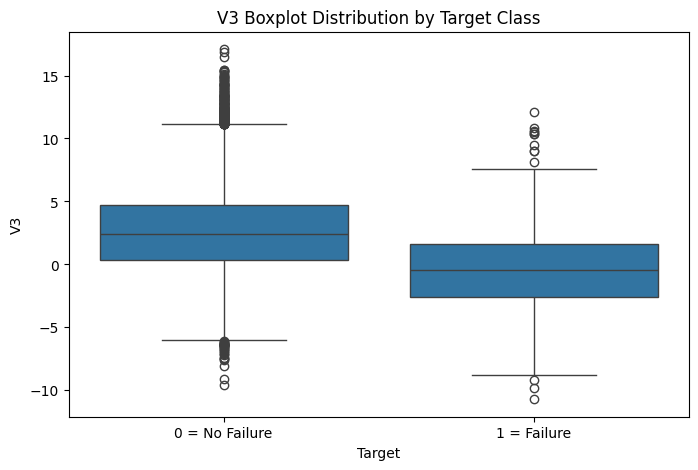

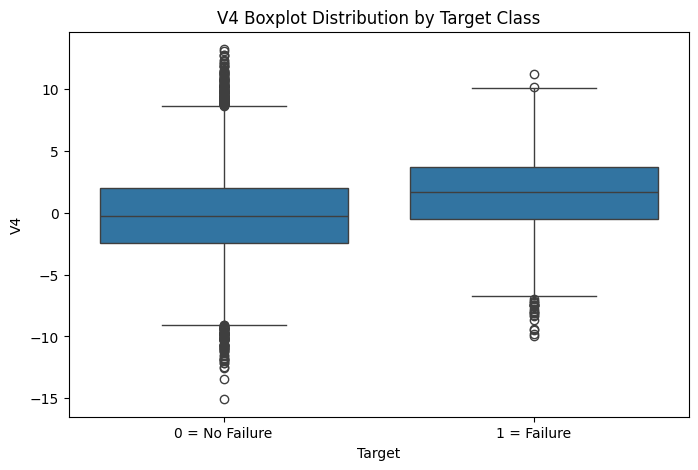

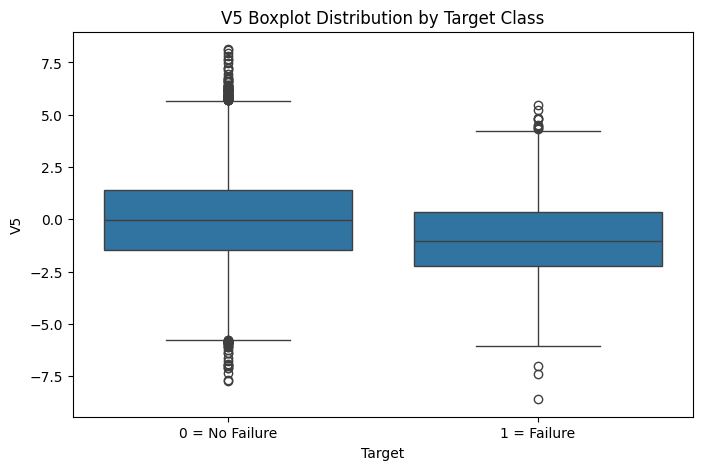

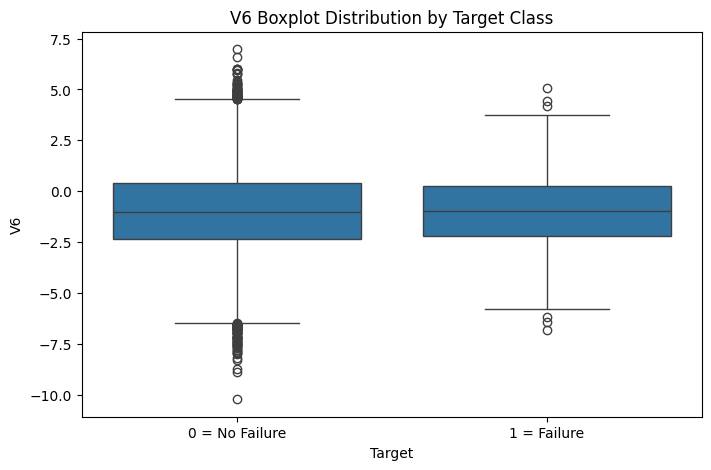

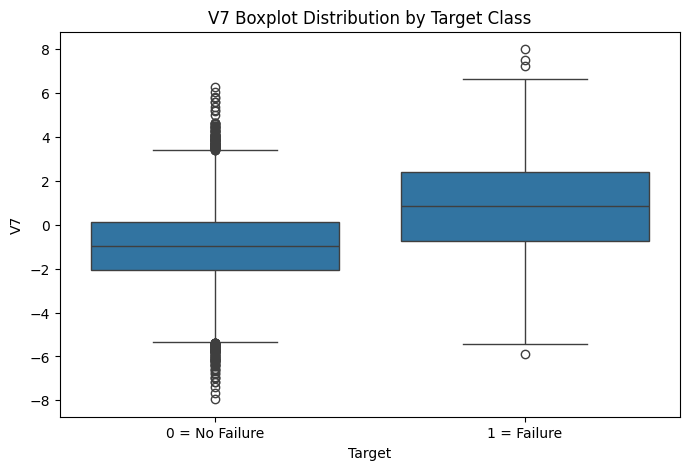

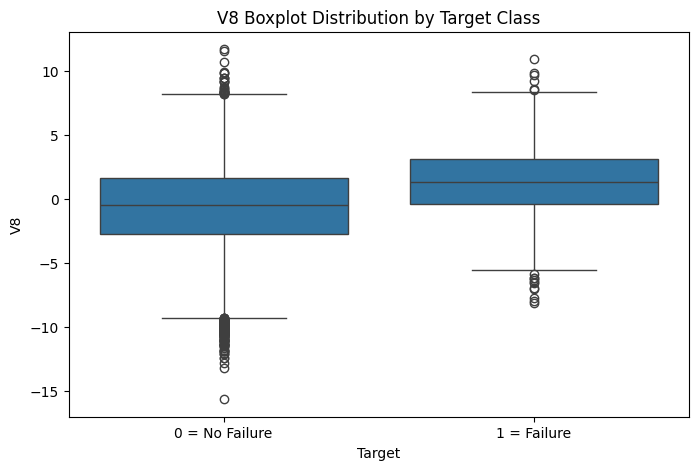

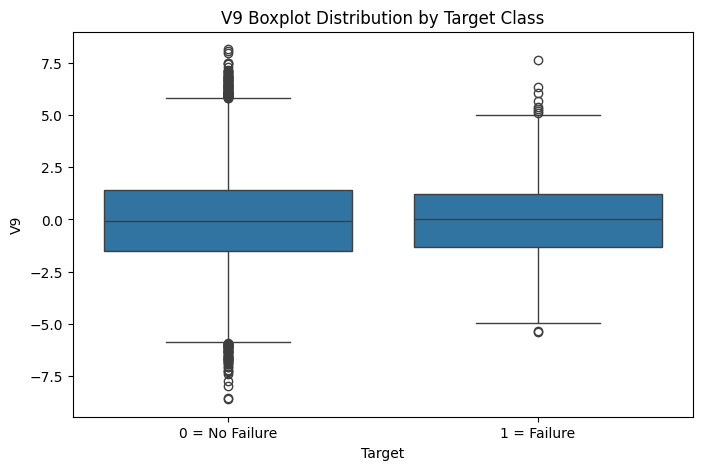

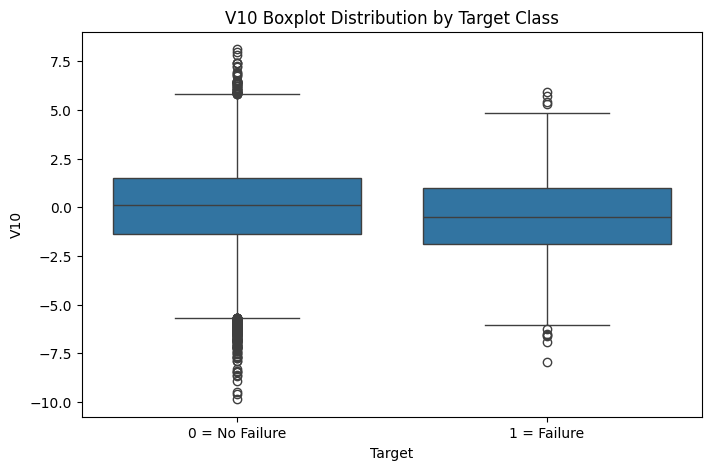

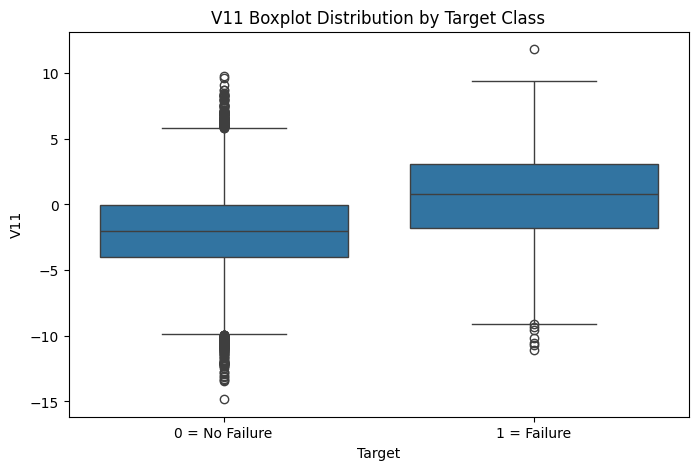

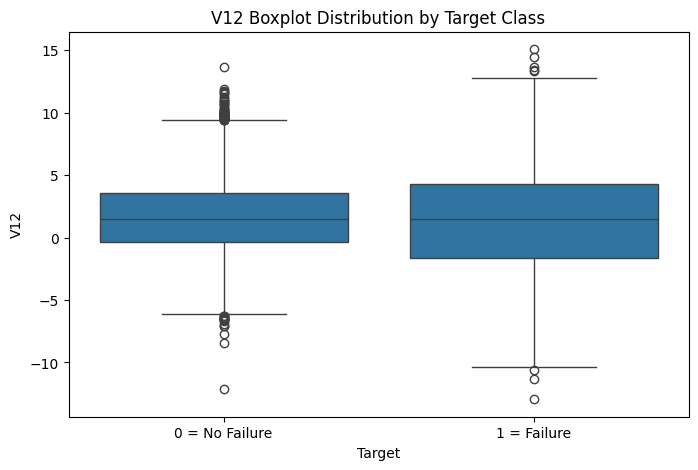

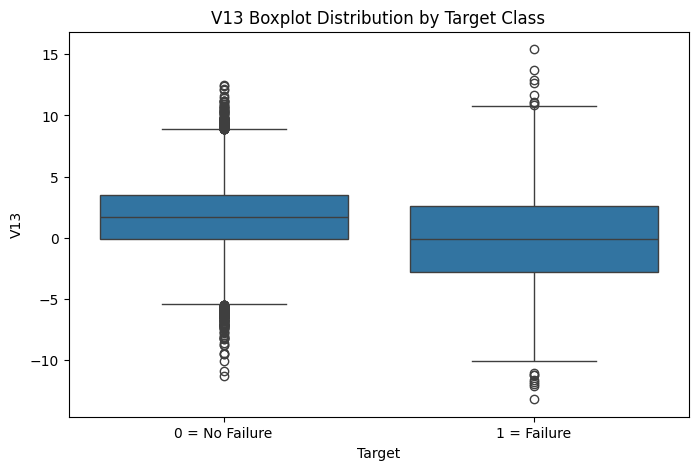

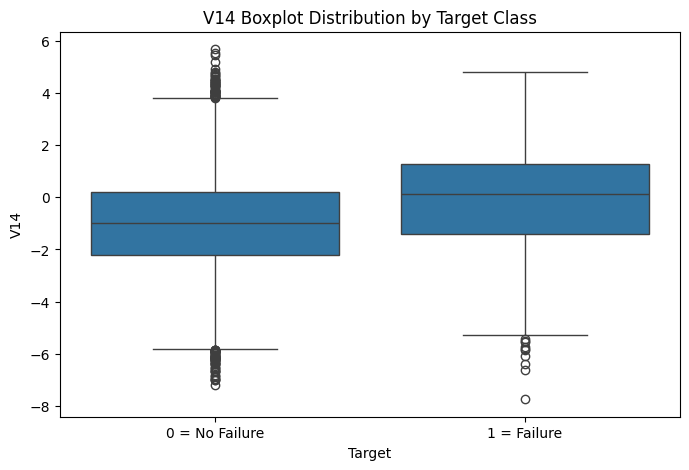

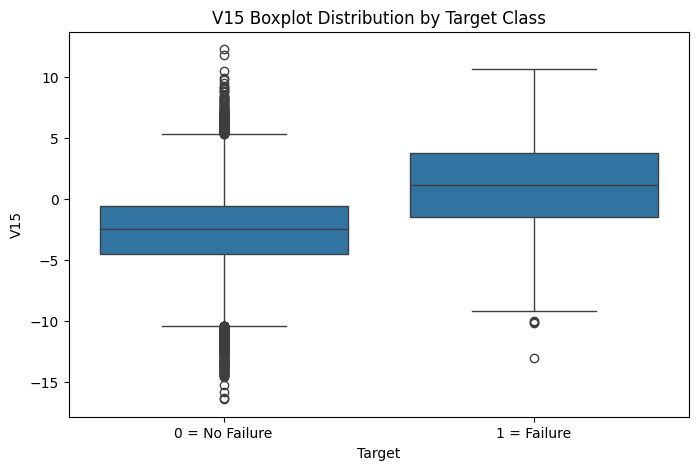

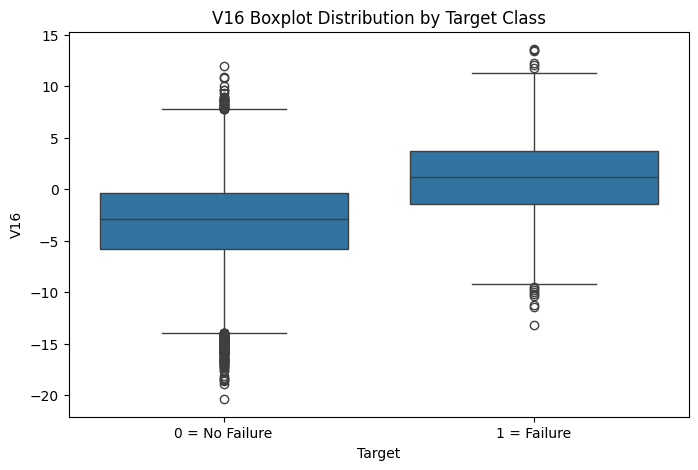

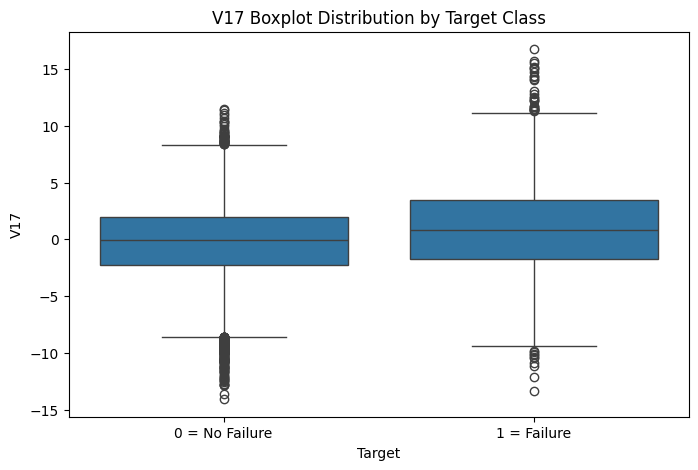

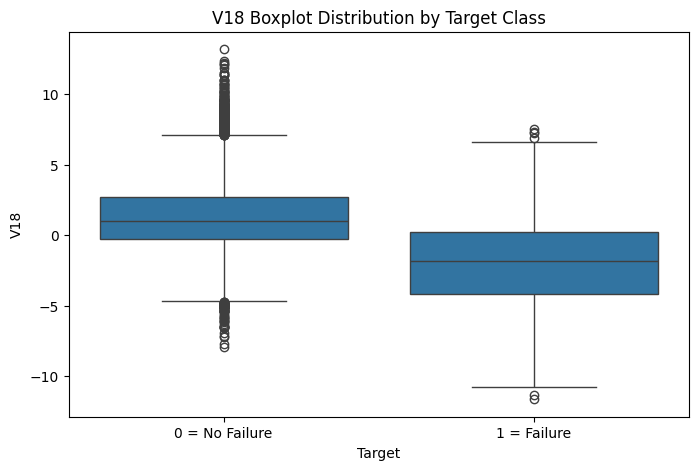

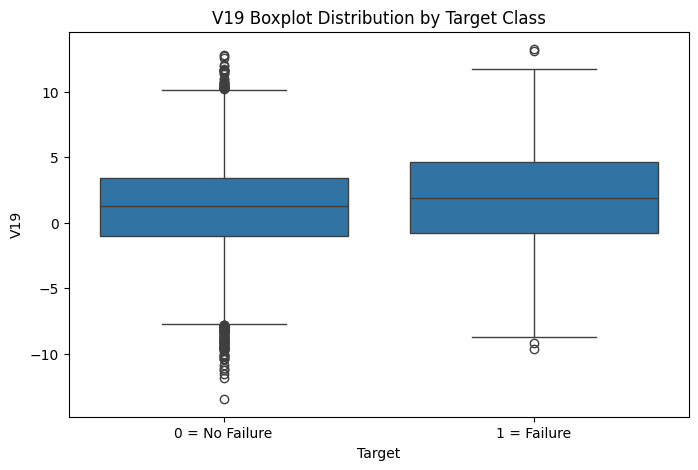

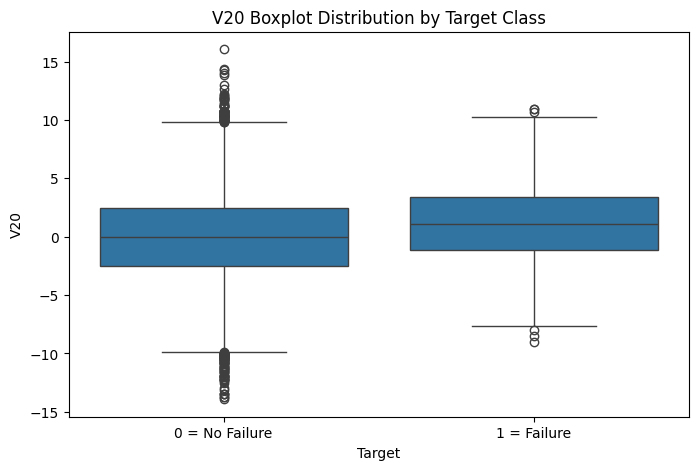

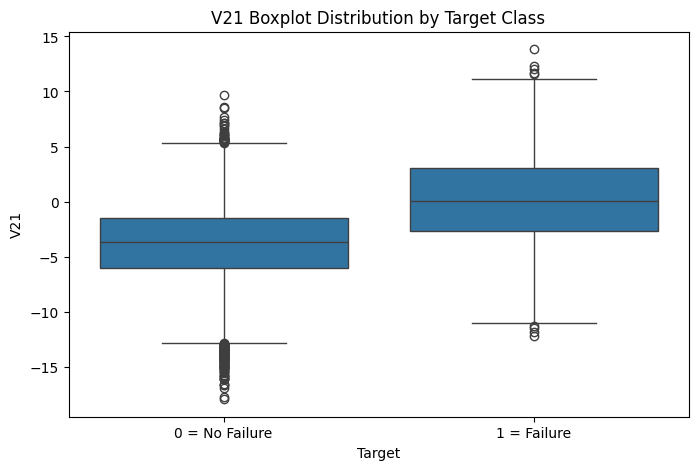

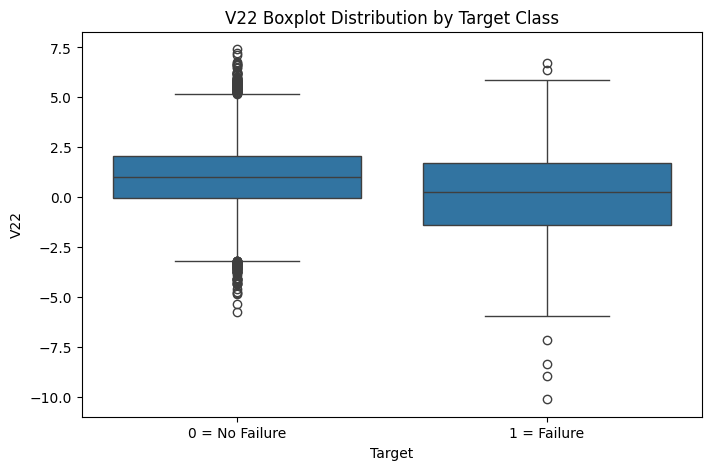

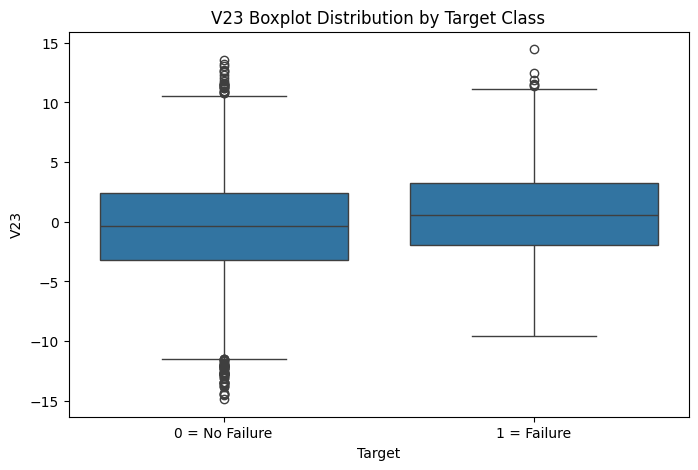

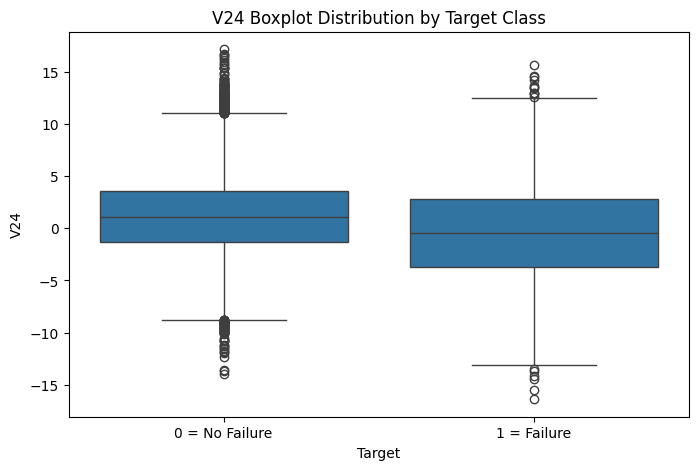

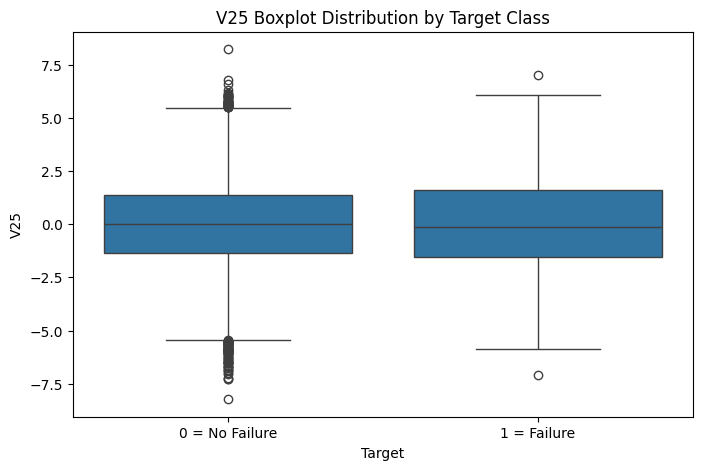

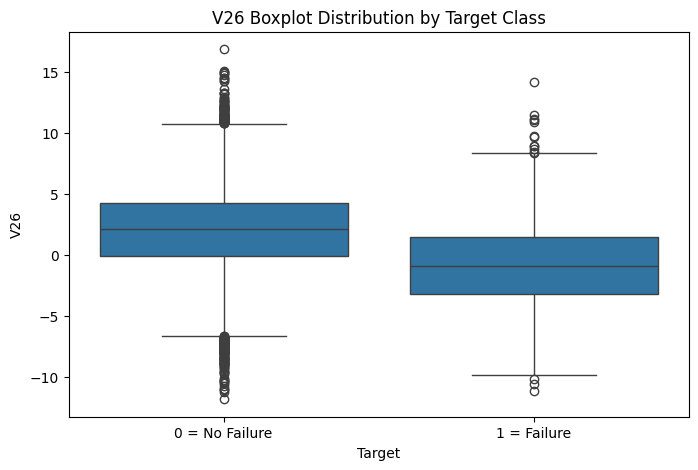

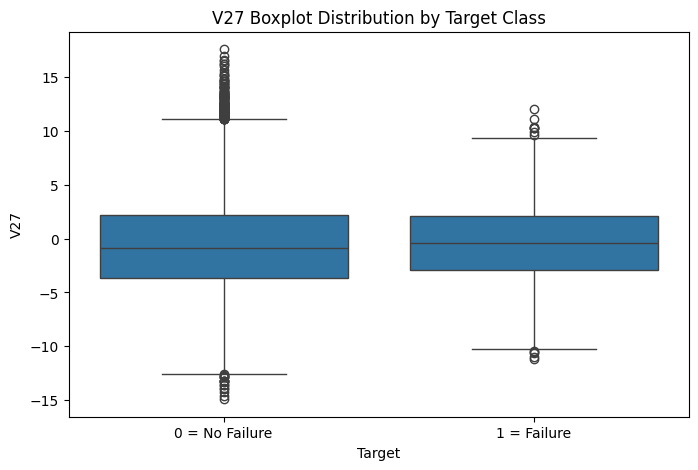

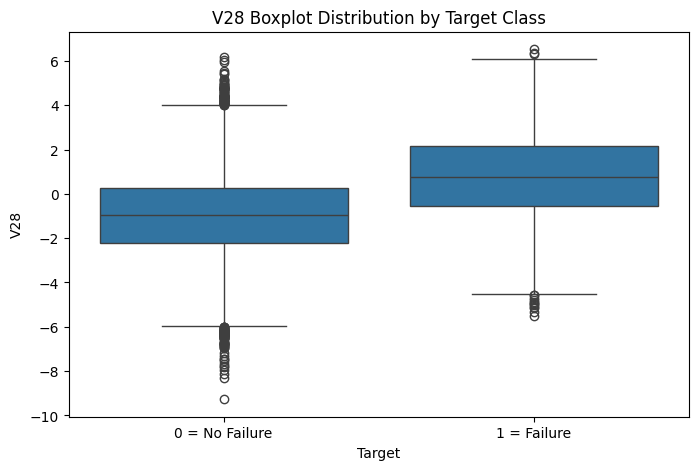

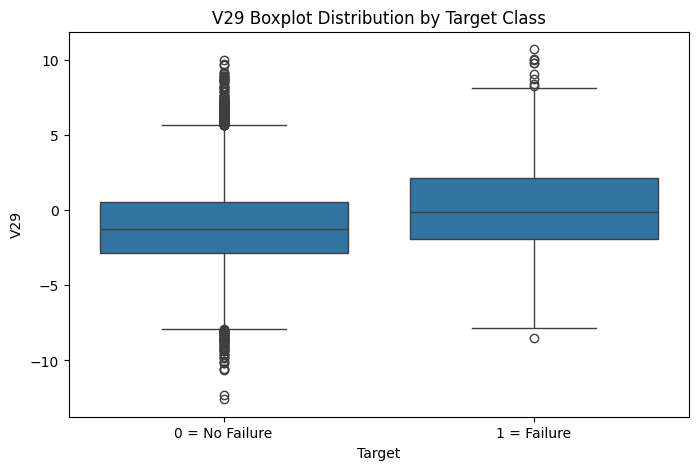

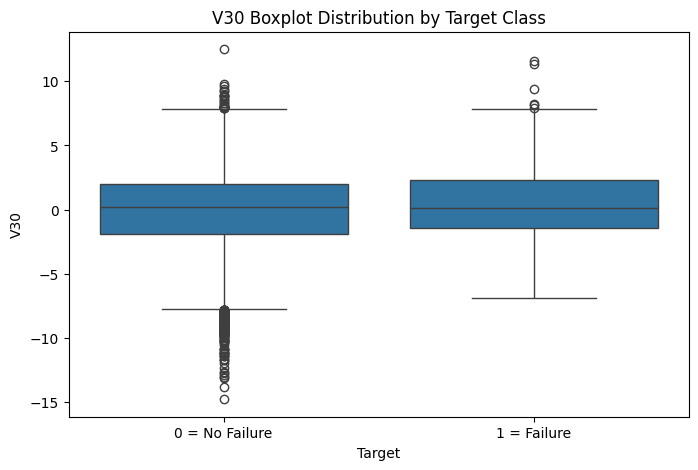

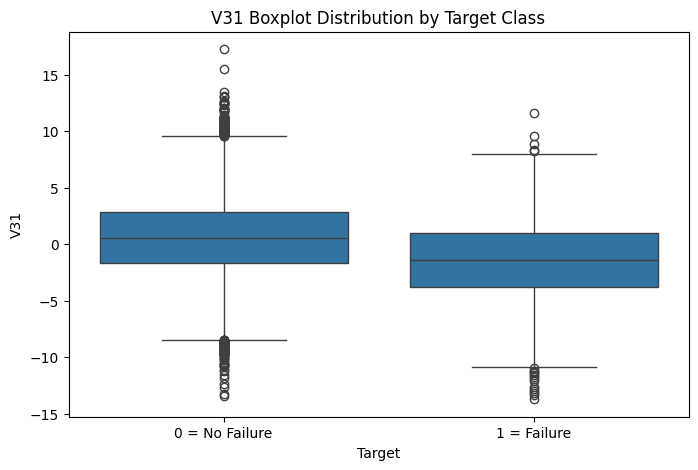

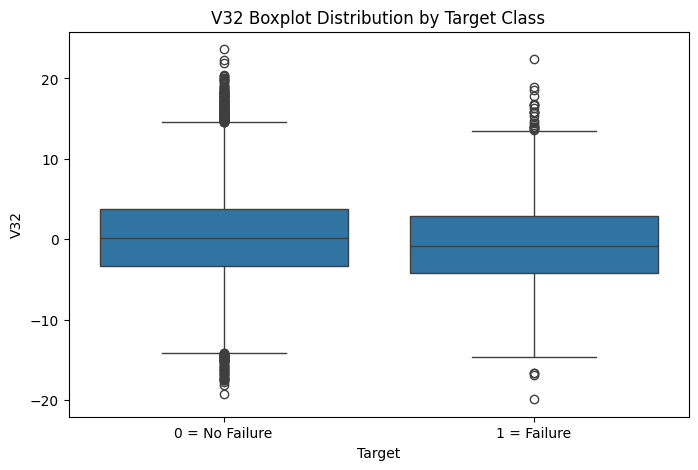

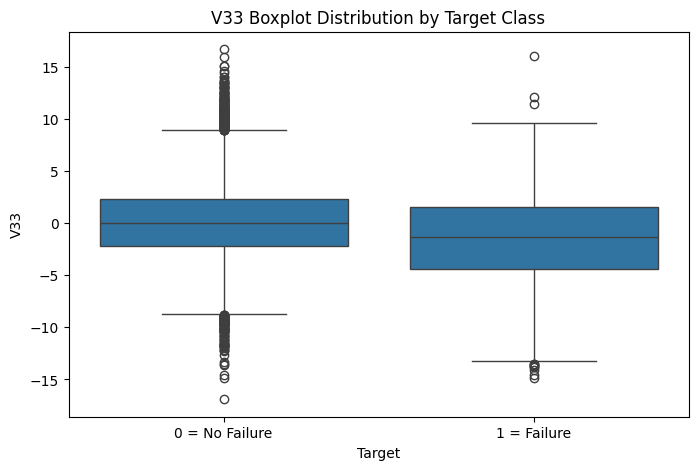

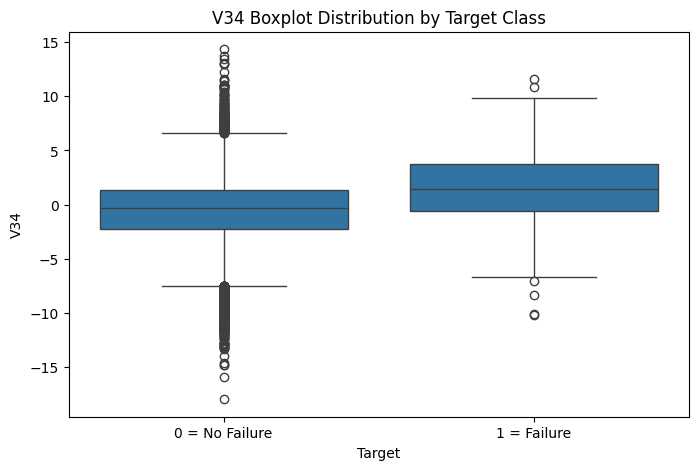

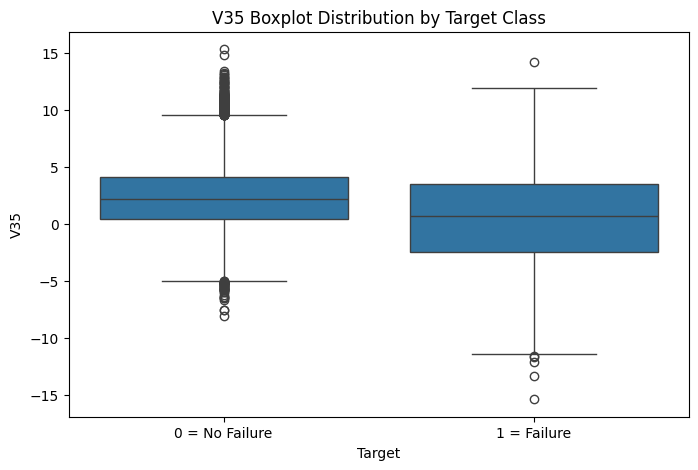

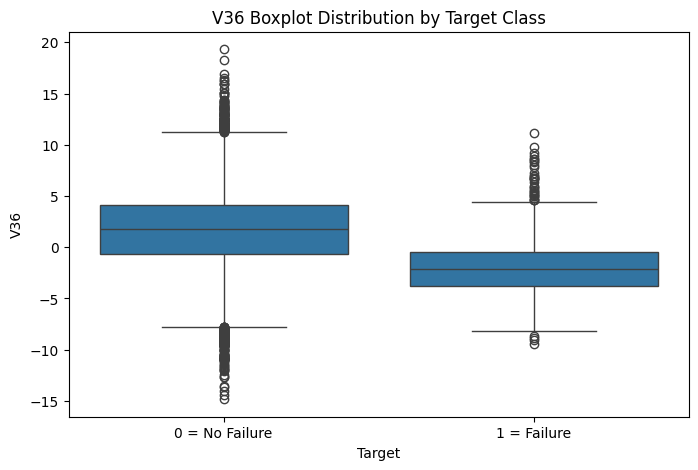

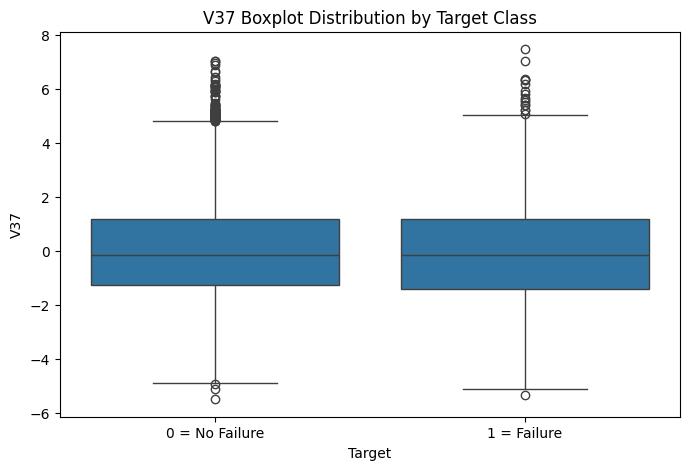

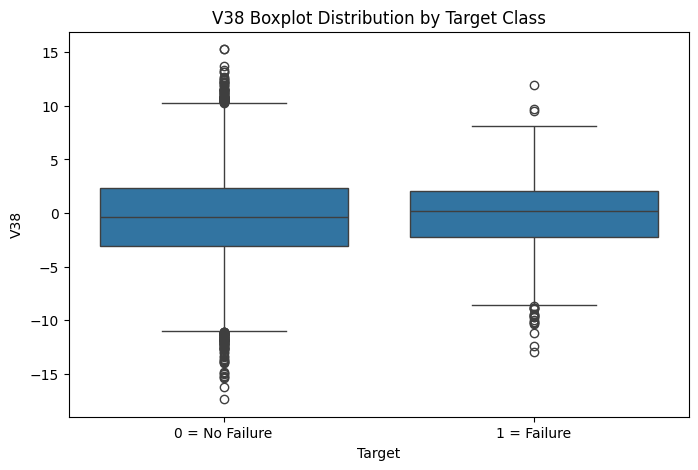

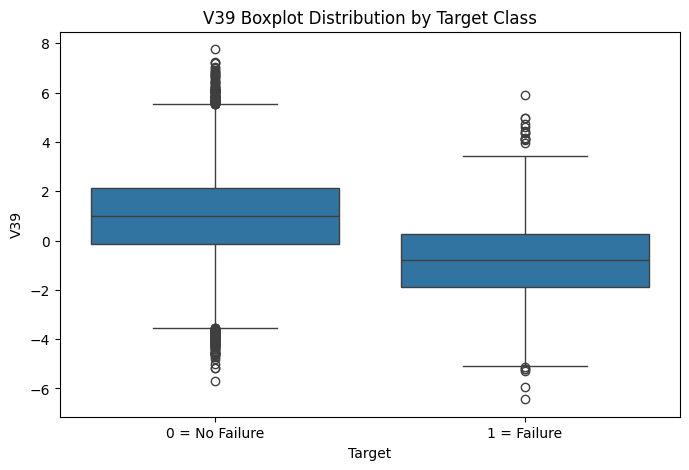

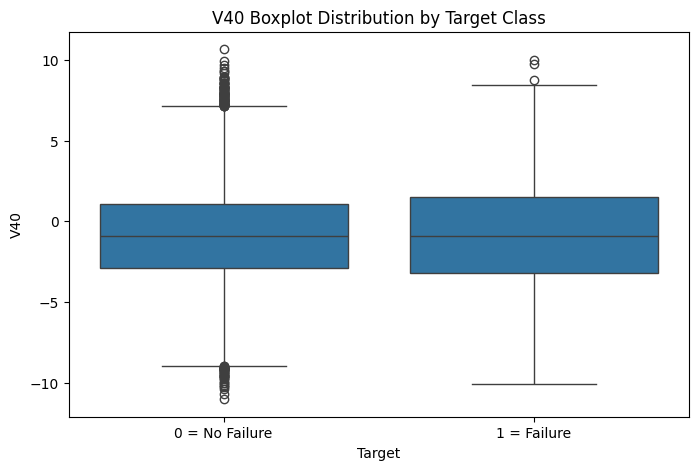

In [ ]:
# Generate boxplots for all predictor variables against the Target variable
for feature in cols_list:

    # Create figure with specified size
    plt.figure(figsize=(8, 5))

    # Create boxplot comparing feature distribution across Target classes
    sns.boxplot(
        x='Target',        # Target classes (0 = No Failure, 1 = Failure)
        y=feature,         # Predictor variable to visualize
        data=data_train    # Source dataframe
    )

    # Add custom labels for Target classes
    plt.xticks(
        ticks=[0, 1],
        labels=['0 = No Failure', '1 = Failure']
    )

    # Add plot title
    plt.title(f'{feature} Boxplot Distribution by Target Class')

    # Import os module for directory and file operations
    import os

    # Create folder
    os.makedirs("4. Boxplot_Distribution_by_Target_Class", exist_ok=True)

    # Save figure into folder
    plt.savefig(f"4. Boxplot_Distribution_by_Target_Class/{feature}.png", bbox_inches='tight')

    # Display the plot
    plt.show()

**Observations:**
* The boxplots comparing predictor variables with the Target variable illustrate the distribution of each feature across the two target classes: no failure (0) and failure (1). This analysis helps evaluate whether the predictor variables exhibit different patterns between normal operating conditions and generator failure conditions.

* Several predictor variables show noticeable differences in median values, spread, and distribution between the two target classes, indicating that these variables may contribute to distinguishing generator failures from normal operations. In some variables, the failure class (1) demonstrates wider variability and shifts in central tendency compared to the no-failure class (0), suggesting potential associations with abnormal turbine behavior.

* The boxplots also reveal the presence of outliers and extreme observations across multiple variables. In the context of predictive maintenance and industrial sensor data, these extreme values may represent unusual operating conditions or early indicators of generator failure rather than data entry errors.

* Additionally, some variables exhibit overlapping distributions between the two target classes, indicating that generator failure prediction is likely influenced by combinations of multiple features rather than a single dominant predictor. This characteristic supports the use of neural network models, which are capable of learning complex nonlinear relationships among variables.

* Overall, the bivariate analysis suggests that several predictor variables contain meaningful patterns related to the Target variable and may provide valuable information for developing an effective predictive maintenance classification model.

### **6.b.4. Exclusion of Scatter Plot Visualization in Bivariate Analysis**

* Scatter plots are not extensively used in this study because the dataset contains a large number of predictor variables (V1–V40), which would result in an excessive number of pairwise visualizations and reduce interpretability. In addition, the dataset consists of transformed numerical sensor variables with a large number of observations, causing scatter plots to become highly dense and difficult to interpret clearly.

* Instead, correlation heatmaps and comparative boxplots are considered more appropriate for this analysis because they provide more efficient visualization of relationships among variables and differences between target classes. These methods allow clearer identification of feature relationships, variable distributions, and potential predictors associated with generator failure.

## **6.c. Multivariate Analysis**

* Multivariate analysis is not extensively performed in this study because the dataset contains a large number of transformed predictor variables and the primary objective is predictive modeling using artificial neural networks. The conducted univariate and bivariate analyses are considered sufficient to understand the dataset characteristics before model development.

# **7. Data Preprocessing (contd.)**

## **7.a. Outlier Analysis**

* Outlier analysis is conducted to identify extreme observations and unusual data patterns within the predictor variables. In predictive maintenance datasets, extreme values may represent abnormal turbine conditions, operational anomalies, or early signs of generator failure rather than data entry errors. Therefore, outlier handling is performed carefully to avoid removing potentially important predictive information.

* Based on Section 6.b.3, Boxplot Distribution of Predictor Variables by Target Class, the boxplot distributions indicate the presence of outliers and extreme observations across several variables in the training dataset. Many predictor variables exhibit data points outside the whisker ranges, suggesting unusually high or low sensor measurements.

* Several variables show wider spreads and more extreme values in the failure class (1) compared to the no-failure class (0). This pattern suggests that abnormal operational conditions and generator failure events may be associated with unusual sensor readings. Variables such as V11, V14, V15, V16, V17, and V18 demonstrate noticeable differences in distribution and variability between the two target classes.

* In addition, some variables exhibit skewed distributions and substantial variability, which is common in industrial sensor datasets used for predictive maintenance. The observed outliers are likely to represent abnormal operating conditions or early indications of generator failure rather than data entry errors.
* Because the dataset was likely transformed or standardized by ReneWind before being shared, and because the study focuses on predictive maintenance, the outliers are retained rather than aggressively removed. Preserving these extreme observations is considered important because they may contain meaningful predictive information related to failure detection.

* Overall, the outlier analysis suggests that the dataset contains realistic operational variability and abnormal patterns that are relevant for machine learning model development and generator failure prediction.

* The conducted outlier analysis is considered sufficient for this study because the boxplot visualizations already provide clear insight into the distribution patterns, variability, and extreme observations across predictor variables and target classes. Since the dataset represents transformed industrial sensor data for predictive maintenance, the identified outliers are retained for model development as they may contain meaningful information related to generator failure conditions.

## **7.a. Data Preparation for Modeling**

### **7.a.1. Checking Data Shapes**

* Before developing the artificial neural network model, the prepared datasets are verified to ensure that the predictor variables and target variables have the correct dimensions and structure. Checking the dataset shapes helps confirm that the data preparation process has been completed correctly and that the datasets are ready for model training and evaluation.

In [ ]:
# Display shape of training feature dataset
print("X_train shape:", X_train.shape)

# Display shape of training target dataset
print("y_train shape:", y_train.shape)

# Display shape of test feature dataset
print("X_test shape:", X_test.shape)

# Display shape of test target dataset
print("y_test shape:", y_test.shape)

X_train shape: (20000, 40)
y_train shape: (20000,)
X_test shape: (5000, 40)
y_test shape: (5000,)


**Observations:**
* The shape verification results indicate that the training feature dataset (X_train) consists of 20,000 observations and 40 predictor variables, while the training target dataset (y_train) contains 20,000 target labels corresponding to each observation. Similarly, the test feature dataset (X_test) contains 5,000 observations with 40 predictor variables, and the test target dataset (y_test) contains 5,000 corresponding target labels.

* These results confirm that the feature and target separation process has been performed correctly and that the datasets are properly structured for artificial neural network model development and evaluation.

### **7.a.2. Checking Class Distribution**

* Class distribution analysis is performed to examine the balance between failure and no-failure observations in the dataset. Understanding the target class distribution is important because imbalanced datasets may affect machine learning model performance, particularly in predictive maintenance applications where failure events are relatively rare.

In [ ]:
# Display class distribution in training dataset
print(y_train.value_counts())

# Display percentage distribution
print(y_train.value_counts(normalize=True) * 100)

Target
0    18890
1     1110
Name: count, dtype: int64
Target
0    94.45
1     5.55
Name: proportion, dtype: float64


**Observations:**
* The class distribution results indicate that the training dataset is imbalanced. The majority class, labeled as 0 (No Failure), contains 18,890 observations or 94.45% of the dataset, while the minority class, labeled as 1 (Failure), contains 1,110 observations or 5.55% of the dataset.

* This distribution shows that generator failure events occur much less frequently than normal operating conditions, which is typical in predictive maintenance datasets. The imbalance suggests that special attention should be given during model development and evaluation to ensure that the artificial neural network can effectively detect failure cases and minimize false negatives.

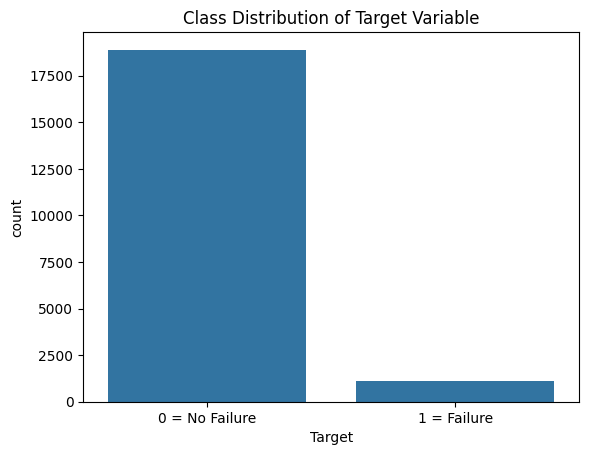

In [ ]:
# Create countplot for target classes
sns.countplot(x=y_train)

# Add title
plt.title('Class Distribution of Target Variable')

# Add custom labels
plt.xticks(
    ticks=[0,1],
    labels=['0 = No Failure', '1 = Failure']
)

# Import os module for directory and file operations
import os

# Create folder
os.makedirs("5. Class_Distribution_of_Target_Variable", exist_ok=True)

# Save figure into folder
plt.savefig(f"5. Class_Distribution_of_Target_Variable/{feature}.png", bbox_inches='tight')

# Display plot
plt.show()

**Observations:**
* The countplot illustrates the class distribution of the Target variable in the training dataset. The majority of observations belong to class 0 (No Failure), while a much smaller proportion belongs to class 1 (Failure).
* Specifically, the dataset contains 18,890 no-failure observations and 1,110 failure observations, indicating a substantial class imbalance. The no-failure class represents approximately 94.45% of the dataset, whereas the failure class represents only 5.55%.
* This imbalance is common in predictive maintenance datasets because actual generator failures occur relatively infrequently compared to normal operating conditions. The visualization confirms that the dataset is dominated by normal operational data, which may influence model learning and evaluation if not considered carefully during artificial neural network development.
* Because the business objective emphasizes accurate failure detection and minimizing false negatives, the imbalance condition should be considered during model evaluation and performance interpretation.

### **7.a.3. Preparing Data Types for Artificial Neural Network**

* The predictor variables are stored in numerical format and have been standardized prior to model development. The Target variable remains in binary integer format, where “0” represents no failure and “1” represents failure, which is appropriate for binary classification using artificial neural networks.

In [ ]:
# Check data types of training dataset
print(data_train.dtypes)

V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
V29       float64
V30       float64
V31       float64
V32       float64
V33       float64
V34       float64
V35       float64
V36       float64
V37       float64
V38       float64
V39       float64
V40       float64
Target      int64
dtype: object


**Observations:**
* The data type verification results indicate that all predictor variables (V1–V40) are stored in float64 format, which is appropriate for numerical computations and artificial neural network modeling. These variables represent continuous numerical sensor measurements that have undergone preprocessing and standardization.

* In addition, the Target variable is stored in int64 format, where the values represent binary classification labels (0 for No Failure and 1 for Failure). This format is suitable for binary classification tasks and does not require further transformation before model development.

* Overall, the dataset data types are appropriate and fully compatible with machine learning and neural network model training.

# **8. Model Building**

## **8.a. Model Evaluation Criterion**

* Model evaluation criteria are used to assess the performance of the artificial neural network model in predicting generator failures. Since the study focuses on predictive maintenance, evaluating the model accurately is essential to ensure that generator failures can be detected effectively while minimizing operational and maintenance costs.

* In this study, the performance of the classification model is evaluated using a confusion matrix, accuracy score, precision score, recall score, and F1-score. These evaluation metrics provide comprehensive insight into the model’s classification performance for both failure and no-failure conditions.

* The confusion matrix is used to summarize the classification results into four categories: true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN). In the context of predictive maintenance:
  * True Positives (TP) represent failures correctly predicted by the model and lead to repair costs.
  * False Negatives (FN) represent actual failures that are not detected by the model and may result in expensive generator replacement costs.
  * False Positives (FP) represent predicted failures that do not actually occur and may lead to unnecessary inspection costs.
  * True Negatives (TN) represent correctly identified normal operating conditions.

* Accuracy measures the proportion of correctly classified observations among all observations. However, because the dataset is imbalanced, accuracy alone may not provide sufficient evaluation of model performance.

* Precision measures the proportion of predicted failure cases that are actually failures. High precision indicates that the model produces fewer false positive predictions.

* Recall measures the proportion of actual failure cases that are successfully detected by the model. In predictive maintenance applications, recall is particularly important because failing to detect a true generator failure may result in substantial replacement costs and operational disruption.

* The F1-score represents the harmonic mean of precision and recall and provides a balanced evaluation metric when dealing with imbalanced classification datasets.

* Overall, these evaluation metrics are used together to comprehensively assess the effectiveness of the artificial neural network model in predicting generator failures and supporting predictive maintenance decision-making.

## **8.b. Initial Model Building (Model 0)**

### **8.b.1. Building the Artificial Neural Network Architecture**

* The initial artificial neural network model (Model 0) is developed using a simple architecture consisting of one hidden layer. The ReLU activation function is applied in the hidden layer because of its computational efficiency and effectiveness in deep learning models. The output layer uses the sigmoid activation function because the study involves binary classification for generator failure prediction.

In [ ]:
# Import TensorFlow library
import tensorflow as tf

# Import Sequential model
from tensorflow.keras.models import Sequential

# Import Dense layer
from tensorflow.keras.layers import Dense

# Create sequential Artificial Neural Network model
model_0 = Sequential()

# Add hidden layer with ReLU activation function
model_0.add(
    Dense(
        32,                 # Number of neurons in hidden layer
        activation='relu',  # Activation function
        input_dim=40        # Number of input features
    )
)

# Add output layer with sigmoid activation function
model_0.add(
    Dense(
        1,                    # Single neuron for binary classification
        activation='sigmoid'  # Sigmoid activation function
    )
)

### **8.b.2. Compiling the Model**

* The artificial neural network model is compiled using the Stochastic Gradient Descent (SGD) optimizer and the binary cross-entropy loss function. Accuracy is used as the initial evaluation metric to monitor the model’s classification performance during training. The SGD optimizer is selected to establish baseline model performance before further tuning and optimization.

In [ ]:
# Compile the Artificial Neural Network model
model_0.compile(

    # Optimization algorithm
    optimizer='SGD',

    # Loss function for binary classification
    loss='binary_crossentropy',

    # Evaluation metric
    metrics=['accuracy']
)

### **8.b.3. Training the Model**

* The artificial neural network model is trained using the prepared training dataset to learn the relationships between predictor variables and generator failure conditions. During the training process, the model iteratively updates its internal weights to minimize the binary cross-entropy loss function and improve classification performance. A validation split is applied to monitor model performance during training and reduce the risk of overfitting.

In [ ]:
# Train the ANN model
history = model_0.fit(

    # Training feature dataset
    X_train,

    # Training target dataset
    y_train,

    # Number of training iterations
    epochs=100,

    # Number of samples processed in each training step
    batch_size=32,

    # Reserve 20% of training data for validation
    validation_split=0.2,

    # Display training progress during execution
    verbose=1
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9447 - loss: 0.2305 - val_accuracy: 0.9490 - val_loss: 0.1696
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9574 - loss: 0.1475 - val_accuracy: 0.9615 - val_loss: 0.1389
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.1260 - val_accuracy: 0.9682 - val_loss: 0.1244
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1145 - val_accuracy: 0.9703 - val_loss: 0.1156
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9715 - loss: 0.1068 - val_accuracy: 0.9712 - val_loss: 0.1092
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.1011 - val_accuracy: 0.9725 - val_loss: 0.1043
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0964 - val_accuracy: 0.9747 - val_loss: 0.1000
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0923 - val_accu

**Observations:**
* The training results indicate that the initial artificial neural network model (Model 0) learned the dataset patterns effectively during the training process. Both training accuracy and validation accuracy improved consistently across the epochs, while the training loss and validation loss decreased steadily, indicating successful model optimization and learning convergence.

* At the beginning of training (Epoch 1), the model achieved a training accuracy of approximately 94.47% with a loss value of 0.2305, while the validation accuracy was 94.90% with a validation loss of 0.1696. As training progressed, the model continuously improved its classification performance, demonstrating effective learning of the relationships between the predictor variables and the target variable.

* By the final epoch (Epoch 100), the model achieved a training accuracy of approximately 99.06% and a validation accuracy of approximately 98.87%. At the same time, the training loss decreased to 0.0474 and the validation loss decreased to 0.0546. These results indicate that the model successfully minimized classification errors while maintaining strong generalization performance on the validation dataset.

* In addition, the relatively small difference between training accuracy and validation accuracy suggests that the model did not experience severe overfitting during training. The validation performance remained stable throughout the training process, indicating that the artificial neural network was able to generalize well to unseen data.

* Overall, the training results demonstrate that the initial ANN model with one hidden layer, ReLU activation function, and SGD optimizer achieved strong baseline performance for generator failure prediction and provides a solid foundation for further model evaluation and optimization.

### **8.b.4. Evaluating Model 0**

* After the training process is completed, Model 0 is evaluated using the test dataset to assess its classification performance in predicting generator failures. The evaluation is conducted using the confusion matrix, accuracy, precision, recall, and F1-score. These evaluation metrics provide insight into the model’s ability to correctly identify both failure and no-failure conditions. Particular attention is given to recall performance because failure detection is critical in predictive maintenance applications, where undetected failures may result in substantial operational and replacement costs.

### **8.b.4.1. Generate Prediction Probabilities**

In [ ]:
# Generate prediction probabilities for test dataset
y_pred_prob = model_0.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


**Observations:**
* The prediction process was successfully completed using the trained artificial neural network model on the test dataset (X_test). The output indicates that the model processed 157 batches of test data and generated prediction probabilities for all observations in the test dataset. These prediction probabilities represent the estimated likelihood of generator failure for each observation and are used for subsequent classification and model evaluation.

### **8.b.4.2. Convert Probabilities into Binary Classes**

In [ ]:
# Convert probabilities into binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

### **8.b.4.3. Import Evaluation Metrics**

In [ ]:
# Import evaluation metrics for classification model assessment
from sklearn.metrics import (

    # Generate confusion matrix to summarize classification results
    confusion_matrix,

    # Calculate overall classification accuracy
    accuracy_score,

    # Calculate precision score
    # Precision measures how many predicted failures are actually failures
    precision_score,

    # Calculate recall score
    # Recall measures how many actual failures are correctly detected
    recall_score,

    # Calculate F1-score
    # F1-score is the harmonic mean of precision and recall
    f1_score,

    # Generate detailed classification performance report
    classification_report
)

In [ ]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision score
precision = precision_score(y_test, y_pred)

# Calculate recall score
recall = recall_score(y_test, y_pred)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Display evaluation metric results
print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-Score:", f1)

Accuracy: 0.9878
Precision: 0.9742489270386266
Recall: 0.8049645390070922
F1-Score: 0.8815533980582524


**Observations:**
* The evaluation results indicate that the initial artificial neural network model (Model 0) achieved strong classification performance for generator failure prediction. The model obtained an accuracy score of 98.78%, indicating that the majority of observations in the test dataset were classified correctly.

* The precision score of approximately 97.42% indicates that most observations predicted as generator failures were actually true failure cases. This result suggests that the model produces relatively few false positive predictions, thereby reducing unnecessary maintenance inspections and operational interruptions.

* The recall score of approximately 80.50% indicates that the model successfully detected most actual generator failure cases. However, some failure observations were still incorrectly classified as no-failure conditions. In predictive maintenance applications, recall is particularly important because undetected failures may lead to costly generator replacement and operational downtime.

* The F1-score of approximately 88.16% demonstrates a strong balance between precision and recall. This result indicates that the model performs well in handling the imbalanced classification problem while maintaining effective failure detection capability.

* Overall, the evaluation results suggest that the initial ANN model provides strong baseline performance for predictive maintenance and generator failure classification, while still offering opportunities for further optimization and performance improvement, particularly in increasing recall and reducing false negative predictions.

### **8.b.4.4. Generate Confusion Matrix**

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4712    6]
 [  55  227]]


**Observations:**
* The confusion matrix results indicate that the artificial neural network model achieved strong classification performance on the test dataset. The model correctly classified 4,712 observations as no failure (True Negatives) and correctly identified 227 observations as failure (True Positives).

* In addition, the model incorrectly predicted 6 observations as failures when they were actually no-failure cases (False Positives), while 55 actual failure observations were incorrectly classified as no failure (False Negatives).

* The relatively low number of false positives indicates that the model rarely generates unnecessary failure alarms. Meanwhile, although some failure cases were missed, the model was still able to detect the majority of actual generator failures successfully.

* Overall, the confusion matrix demonstrates that the initial artificial neural network model achieved strong predictive performance for generator failure classification and provides a solid baseline for further model optimization and evaluation.

# **9. Model Performance Improvement**

* Although the initial artificial neural network model (Model 0) achieved strong baseline performance, further model improvement is performed to enhance classification capability and improve predictive performance. Model optimization is particularly important in predictive maintenance applications because improving failure detection and reducing false negative predictions can help minimize operational disruption and generator replacement costs.

* To improve the predictive performance of the artificial neural network model, several model improvement experiments are conducted through iterative modifications of the network architecture and training configuration. Each improved model is evaluated and compared using classification performance metrics to identify the most effective model for generator failure prediction.

## **9.a. Model 1**

* Model 1 is developed by modifying the optimization algorithm used in Model 0. The Stochastic Gradient Descent (SGD) optimizer is replaced with the Adam optimizer to improve convergence speed and enhance model learning performance. Adam is selected because it combines adaptive learning rates and momentum optimization, which often results in more efficient and stable training in deep learning models.

In [ ]:
# Clear the current Keras session to remove previously created models and layers,
# helping free memory and prevent resource accumulation during multiple model experiments.
tf.keras.backend.clear_session()

In [ ]:
# Initialize the artificial neural network model
model_1 = Sequential()

# Add first hidden layer
model_1.add(
    Dense(
        32,                     # Number of neurons in the hidden layer
        activation="relu",      # ReLU activation function
        input_dim=X_train.shape[1]  # Number of input features
    )
)

# Add second hidden layer
model_1.add(
    Dense(
        16,                     # Number of neurons in the second hidden layer
        activation="relu"       # ReLU activation function
    )
)

# Add output layer for binary classification
model_1.add(
    Dense(
        1,                      # One output neuron
        activation="sigmoid"    # Sigmoid activation for binary classification
    )
)

In [ ]:
# Display summary of the ANN architecture
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

**Observations:**
* The model summary indicates that Model 1 is constructed using a sequential artificial neural network architecture consisting of two hidden layers and one output layer. The first hidden layer (dense) contains 32 neurons and produces an output shape of (None, 32). This layer includes 1,312 trainable parameters, which consist of weights and bias values connected to the 40 input features.

* The second hidden layer (dense_1) contains 16 neurons with an output shape of (None, 16). This layer introduces additional nonlinear learning capability and contains 528 trainable parameters.

* The output layer (dense_2) consists of a single neuron with a sigmoid activation function and an output shape of (None, 1), which is appropriate for binary classification of generator failure prediction. This layer contains 17 trainable parameters.

* Overall, the model contains a total of 1,857 trainable parameters and no non-trainable parameters. The relatively small number of parameters indicates that the model architecture remains computationally efficient while increasing complexity compared to the baseline model. The additional hidden layer is intended to improve the model’s ability to learn complex patterns and relationships within the predictive maintenance dataset.

In [ ]:
# Define SGD optimizer
optimizer = tf.keras.optimizers.SGD()

# Compile Model 1
model_1.compile(

    # Loss function for binary classification
    loss='binary_crossentropy',

    # Optimization algorithm
    optimizer=optimizer,

    # Evaluation metrics
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

* The artificial neural network model is compiled using the Stochastic Gradient Descent (SGD) optimizer, binary cross-entropy loss function, and multiple evaluation metrics including accuracy, precision, and recall. The SGD optimizer is selected as the initial optimization algorithm because it provides a simple and computationally efficient baseline approach for updating model weights during training.

* The binary cross-entropy loss function is used because the study involves binary classification, where the target variable represents two classes: no failure (0) and failure (1). This loss function is widely used for binary classification problems and helps measure the difference between predicted probabilities and actual class labels.

* Accuracy is included as an evaluation metric to measure the overall proportion of correctly classified observations. Precision is used to evaluate how many predicted failure cases are actually true failures, which is important for reducing unnecessary maintenance actions caused by false positive predictions. Recall is also included because it measures the model’s ability to correctly identify actual generator failure cases. In predictive maintenance applications, recall is particularly important because undetected failures may lead to substantial operational disruption and generator replacement costs.

* Overall, these evaluation metrics are used together to provide a more comprehensive assessment of model performance, particularly in the presence of class imbalance within the predictive maintenance dataset.

In [ ]:
# Import time module
import time

# Store starting time
start = time.time()

# Train the ANN model
history = model_1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Store ending time
end = time.time()

# Display total training time in seconds
print("Time taken in seconds:", end - start)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9459 - loss: 0.2112 - precision: 0.8889 - recall: 0.0182 - val_accuracy: 0.9492 - val_loss: 0.1541 - val_precision: 0.9655 - val_recall: 0.1217
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9585 - loss: 0.1359 - precision: 0.9538 - recall: 0.2580 - val_accuracy: 0.9645 - val_loss: 0.1260 - val_precision: 0.9490 - val_recall: 0.4043
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9674 - loss: 0.1143 - precision: 0.9325 - recall: 0.4398 - val_accuracy: 0.9695 - val_loss: 0.1113 - val_precision: 0.9154 - val_recall: 0.5174
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9723 - loss: 0.1016 - precision: 0.9226 - recall: 0.5420 - val_accuracy: 0.9715 - val_loss: 0.1016 - val_precision: 0.9265 - val_recall: 0.5478
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0926 - precision: 0.9267 - recall: 0.6034 - val_accuracy: 0.9760 - val_los

**Observations:**
* The training results for Model 1 indicate that the improved artificial neural network architecture achieved strong and stable classification performance throughout the training process. Both the training and validation metrics improved consistently across the epochs, while the loss values steadily decreased, demonstrating effective learning and convergence of the model.

* At the beginning of training (Epoch 1), the model achieved a training accuracy of approximately 94.59% with a loss value of 0.2112. Although the initial recall value was relatively low at 1.82%, the model rapidly improved its ability to detect generator failures during subsequent epochs. The validation accuracy at Epoch 1 was 94.92%, with a validation recall of 12.17%.

* As training progressed, the model demonstrated substantial improvement in precision and recall performance. By Epoch 10, the training accuracy increased to approximately 98.52%, while the recall improved to approximately 75.57%. The validation recall also increased considerably, indicating that the model became more effective in identifying actual generator failure cases.

* Toward the later training stages, the model achieved highly stable performance. By Epoch 100, the model obtained a training accuracy of approximately 99.25% and a validation accuracy of approximately 99.05%. The training precision reached approximately 98.59%, while the training recall increased to approximately 87.61%. In addition, the validation precision and validation recall achieved approximately 98.98% and 84.35%, respectively.

* The decreasing loss values throughout the training process indicate that the model successfully minimized classification errors while learning meaningful patterns from the dataset. The relatively small difference between training and validation metrics suggests that the model generalized well to unseen data and did not exhibit severe overfitting.

* Compared to Model 0, Model 1 demonstrates improved learning capability and stronger failure detection performance, particularly in terms of recall. This improvement suggests that the addition of a second hidden layer enhanced the model’s ability to capture more complex nonlinear relationships among the predictor variables.

* The total training time for Model 1 was approximately 146.99 seconds, indicating that the model remained computationally efficient despite the increased architectural complexity.

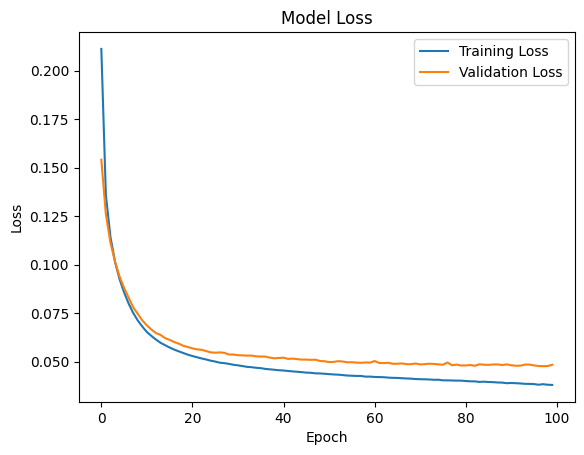

In [ ]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot training loss
plt.plot(history.history['loss'])

# Plot validation loss
plt.plot(history.history['val_loss'])

# Add plot title
plt.title('Model Loss')

# Label x-axis
plt.xlabel('Epoch')

# Label y-axis
plt.ylabel('Loss')

# Add legend
plt.legend(['Training Loss', 'Validation Loss'])

# Import os module for directory and file operations
import os

# Create folder
os.makedirs("6. Model Loss", exist_ok=True)

# Save figure into folder
plt.savefig(f"6. Model Loss/{feature}.png", bbox_inches='tight')

# Display plot
plt.show()

**Observations:**
* The model loss curve demonstrates that both the training loss and validation loss decreased consistently throughout the training process, indicating that the artificial neural network model learned effectively from the dataset. During the early epochs, both loss values declined rapidly, suggesting that the model quickly captured important patterns and relationships within the predictor variables.

* As training progressed, the loss curves gradually stabilized and converged toward lower values. By the final epochs, the training loss reached approximately 0.038, while the validation loss stabilized around 0.048. The relatively small gap between the training and validation loss curves indicates that the model generalized well to unseen validation data and did not exhibit severe overfitting.

* The validation loss remained slightly higher than the training loss across most epochs, which is expected because validation data represents unseen observations. However, the validation loss did not increase significantly during later epochs, suggesting that the model maintained stable predictive performance without substantial memorization of the training data.

* Overall, the loss curve indicates that Model 1 achieved stable convergence, effective learning behavior, and good generalization capability for generator failure prediction.

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create function to evaluate classification model performance
def model_performance_classification(model, X, y):

    # Generate prediction probabilities
    y_pred_prob = model.predict(X)

    # Convert probabilities into binary predictions
    y_pred = (y_pred_prob > 0.5).astype("int32")

    # Calculate evaluation metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    # Store results in dictionary
    performance = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    return performance

* The evaluation metrics are imported to measure the classification performance of the artificial neural network model. Accuracy, precision, recall, and F1-score are selected because they provide complementary information regarding the model’s predictive capability, particularly in handling imbalanced predictive maintenance data.

* A custom function named model_performance_classification() is developed to simplify and standardize the evaluation process across different ANN models. The function generates prediction probabilities using the trained model and converts them into binary class predictions using a classification threshold of 0.5.

* The function then calculates several important evaluation metrics. Accuracy is used to measure the overall proportion of correctly classified observations. Precision evaluates how many predicted generator failure cases are actually true failures, which is important for minimizing unnecessary maintenance actions. Recall measures the model’s ability to correctly identify actual generator failures and is especially important in predictive maintenance applications because undetected failures may result in operational disruption and costly equipment damage. The F1-score is included to provide a balanced assessment of precision and recall performance.

* Finally, the evaluation results are stored in a dictionary structure to facilitate organized performance comparison among multiple ANN models developed during the model improvement phase.

In [ ]:
# Evaluate Model 1 performance on training dataset
model_1_train_perf = model_performance_classification(
    model_1,
    X_train,
    y_train
)

# Display training performance
model_1_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


{'Accuracy': 0.99215,
 'Precision': 0.9927611168562565,
 'Recall': 0.8648648648648649,
 'F1-Score': 0.9244102070293693}

**Observations:**
* The training performance results indicate that Model 1 achieved excellent classification performance on the training dataset. The model obtained an accuracy score of approximately 99.22%, indicating that the vast majority of observations were classified correctly.

* The precision score of approximately 99.28% demonstrates that nearly all observations predicted as generator failures were actual failure cases. This result indicates that the model generated very few false positive predictions, thereby reducing unnecessary maintenance interventions and operational interruptions.

* The recall score of approximately 86.49% indicates that the model successfully detected most actual generator failure cases within the training dataset. This represents a substantial improvement in failure detection capability compared to the earlier baseline model. In predictive maintenance applications, strong recall performance is particularly important because missed failure cases may result in equipment damage, operational downtime, and increased maintenance costs.

* The F1-score of approximately 92.44% demonstrates a strong balance between precision and recall, indicating that the model performs effectively in handling the imbalanced classification problem while maintaining reliable failure detection performance.

* Overall, the results suggest that Model 1 achieved highly effective learning performance and improved generator failure classification capability through the addition of a deeper neural network architecture.

In [ ]:
# Evaluate Model 1 performance on test dataset
model_1_test_perf = model_performance_classification(
    model_1,
    X_test,
    y_test
)

# Display test performance results
model_1_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'Accuracy': 0.9896,
 'Precision': 0.9872881355932204,
 'Recall': 0.8262411347517731,
 'F1-Score': 0.8996138996138996}

* The trained artificial neural network model is evaluated using the test dataset to assess its predictive performance on unseen observations. Test evaluation is important for measuring the model’s generalization capability and determining its effectiveness for generator failure prediction in real-world predictive maintenance applications.

**Observations:**
* The test performance results indicate that Model 1 achieved excellent classification performance on unseen data. The model obtained an accuracy score of approximately 98.96%, indicating that the majority of observations in the test dataset were classified correctly.

* The precision score of approximately 98.73% demonstrates that nearly all observations predicted as generator failures were actual failure cases. This result indicates that the model produced very few false positive predictions, thereby minimizing unnecessary maintenance actions and operational interruptions.

* The recall score of approximately 82.62% indicates that the model successfully detected most actual generator failure cases within the test dataset. This reflects strong failure detection capability and represents good predictive performance for predictive maintenance applications. However, some generator failure cases were still missed, indicating that additional model optimization may further improve failure detection performance.

* The F1-score of approximately 89.96% demonstrates a strong balance between precision and recall, suggesting that the model performs effectively in handling the imbalanced classification problem while maintaining reliable predictive capability.

* Overall, the evaluation results suggest that Model 1 generalized well to unseen data and achieved improved predictive maintenance performance compared to the baseline model. The combination of high accuracy, strong precision, and improved recall indicates that the deeper artificial neural network architecture enhanced the model’s ability to capture complex relationships within the generator sensor data.

In [ ]:
# Generate prediction probabilities for training dataset
y_train_pred_1 = model_1.predict(X_train)

# Generate prediction probabilities for test dataset
y_test_pred_1 = model_1.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


* Prediction probabilities are generated using the trained artificial neural network model for both the training and test datasets. These probabilities represent the estimated likelihood of generator failure for each observation and are used for subsequent classification and model performance evaluation.

**Observations:**
* The output indicates that the trained artificial neural network model successfully generated prediction probabilities for both the training and test datasets. The first line shows that the model processed the training dataset in 625 batches, requiring approximately 2 seconds with an average processing time of 4 milliseconds per step.

* The second line indicates that the model generated predictions for the test dataset in 157 batches, requiring less than 1 second with an average processing time of 1 millisecond per step.

* These results demonstrate that the trained ANN model performs prediction tasks efficiently while handling large numbers of observations. The generated prediction probabilities are subsequently used for classification and performance evaluation of generator failure prediction.

In [ ]:
# Display title for training classification report
print("Classification Report - Train Data Model_1", end="\n\n")

# Generate classification report using training dataset
cr_train_model_1 = classification_report(
    y_train,                 # Actual training labels
    y_train_pred_1 > 0.5    # Convert probabilities into binary predictions
)

# Display classification report
print(cr_train_model_1)

Classification Report - Train Data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     18890
           1       0.99      0.86      0.92      1110

    accuracy                           0.99     20000
   macro avg       0.99      0.93      0.96     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the detailed classification performance of Model 1. The report includes precision, recall, F1-score, and support for each target class, providing a comprehensive assessment of the model’s ability to classify generator failure and no-failure observations.

**Observations:**
* The classification report for Model 1 on the training dataset indicates excellent overall classification performance. For Class 0 (No Failure), the model achieved a precision of 99% and a recall of 100%, resulting in an F1-score of 100%. This indicates that the model classified no-failure observations extremely accurately with very few misclassifications.

* For Class 1 (Failure), the model achieved a precision of 99%, indicating that nearly all predicted failure cases were actual failures. The recall value of 86% indicates that the model successfully identified most generator failure observations in the training dataset, although some failure cases were still missed. The F1-score of 92% demonstrates a strong balance between precision and recall for the failure class.

* The overall training accuracy of the model was approximately 99%, demonstrating highly effective classification capability across the dataset. The macro average F1-score of 96% indicates strong balanced performance across both classes, while the weighted average values near 99% reflect the model’s overall strong predictive performance considering the class distribution.

* Overall, the classification report suggests that Model 1 learned the training data effectively and achieved strong generator failure detection capability while maintaining very low false positive predictions.

In [ ]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split training data into training and validation datasets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

* The train_test_split() function is imported from the sklearn.model_selection library to divide the dataset into separate training and validation subsets. This process is performed to evaluate the generalization capability of the artificial neural network model on unseen data during the training process. The training dataset is divided into 80% training data and 20% validation data using the test_size = 0.2 parameter. The random_state = 42 parameter is applied to ensure reproducibility and consistency of the data splitting process across multiple runs. In addition, the stratify=y_train parameter is used to preserve the original class distribution of the target variable in both the training and validation datasets, which is particularly important because the dataset exhibits class imbalance between failure and no-failure observations.

In [ ]:
history = model_1.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0405 - precision: 0.9884 - recall: 0.8649 - val_accuracy: 0.9937 - val_loss: 0.0385 - val_precision: 0.9713 - val_recall: 0.9144
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9923 - loss: 0.0402 - precision: 0.9860 - recall: 0.8727 - val_accuracy: 0.9937 - val_loss: 0.0385 - val_precision: 0.9713 - val_recall: 0.9144
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0400 - precision: 0.9885 - recall: 0.8682 - val_accuracy: 0.9940 - val_loss: 0.0389 - val_precision: 0.9760 - val_recall: 0.9144
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0398 - precision: 0.9884 - recall: 0.8660 - val_accuracy: 0.9942 - val_loss: 0.0393 - val_precision: 0.9807 - val_recall: 0.9144
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9923 - loss: 0.0396 - precision: 0.9898 - recall: 0.8705 - val_accuracy: 0.9937 - val_los

* The artificial neural network model is trained using the training dataset (X_train_final and y_train_final) while simultaneously evaluating performance on the validation dataset (X_val and y_val) during each training epoch. The training process is conducted over 100 epochs to allow the model sufficient opportunity to learn complex patterns and relationships within the generator sensor data. A batch size of 32 is used to divide the training data into smaller subsets during each iteration, improving computational efficiency and helping stabilize the optimization process. The validation dataset is included during training to monitor the model’s generalization capability and identify potential overfitting by comparing training and validation performance throughout the learning process.

**Observations:**
* The training results of the improved artificial neural network model demonstrate strong and stable predictive performance throughout the 100 training epochs. The model achieved consistently high accuracy values during training, increasing from approximately 99.19% in the first epoch to about 99.39% in the final epoch. At the same time, the training loss gradually decreased from 0.0405 to 0.0326, indicating continuous optimization of the model parameters and improved learning performance.

* The precision values remained consistently high throughout the training process, reaching approximately 99.01% in the final epoch. This indicates that the model was highly effective in correctly identifying generator failure cases with very few false positive predictions. In addition, the recall values improved gradually from approximately 86.49% in the early epochs to approximately 89.86% in the final epoch, demonstrating improved capability in detecting actual generator failure observations.

* The validation performance also remained stable across the training process. Validation accuracy consistently ranged between approximately 99.18% and 99.42%, while validation loss remained relatively low and stable between approximately 0.0385 and 0.0436. These results indicate that the model generalized well to unseen validation data and did not exhibit substantial overfitting.

* Furthermore, the validation precision values remained high throughout training, generally exceeding 95%, while validation recall values consistently remained around 90%. This suggests that the model maintained strong capability in identifying generator failure conditions while preserving balanced classification performance on unseen data. Overall, the training results indicate that the improved artificial neural network model achieved highly effective predictive performance and stable generalization capability for generator failure prediction in predictive maintenance applications.

In [ ]:
# Generate prediction probabilities for validation dataset
y_val_pred_1 = model_1.predict(X_val)

# Display title for validation classification report
print("Classification Report - Validation Data Model_1", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_1 = classification_report(
    y_val,                 # Actual validation labels
    y_val_pred_1 > 0.5    # Convert probabilities into binary predictions
)

# Display validation classification report
print(cr_val_model_1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report - Validation Data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.96      0.91      0.93       222

    accuracy                           0.99      4000
   macro avg       0.98      0.95      0.96      4000
weighted avg       0.99      0.99      0.99      4000



* Prediction probabilities are generated for the validation dataset using the trained artificial neural network model to estimate the likelihood of generator failure for each validation observation. These prediction probabilities are subsequently converted into binary class predictions using a classification threshold of 0.5, where probabilities greater than 0.5 are classified as generator failure cases (1) and lower probabilities are classified as no-failure cases (0). A classification report is then generated to evaluate the predictive performance of Model 1 on the validation dataset. The report provides detailed evaluation metrics, including precision, recall, F1-score, and support for each target class, allowing comprehensive assessment of the model’s generalization capability and classification effectiveness on previously unseen data. This validation evaluation is particularly important in predictive maintenance applications because it helps determine the model’s ability to reliably detect generator failures while monitoring potential overfitting and ensuring stable predictive performance.

**Observations:**
* The validation classification results indicate that Model 1 achieved excellent predictive performance on unseen validation data. The model processed the validation dataset efficiently in 125 batches, requiring less than one second to generate prediction probabilities.

* For Class 0 (No Failure), the model achieved a precision of 99% and a recall of 100%, resulting in an F1-score of 100%. This indicates that the model classified no-failure observations extremely accurately with almost no misclassifications.

* For Class 1 (Failure), the model achieved a precision of 96%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of 91% demonstrates that the model successfully identified the majority of actual generator failure observations in the validation dataset. The F1-score of 93% indicates a strong balance between precision and recall for the failure class.

* The overall validation accuracy reached approximately 99%, demonstrating highly effective classification capability on unseen data. In addition, the macro average F1-score of 96% indicates balanced classification performance across both target classes despite the class imbalance within the dataset. The weighted average values near 99% further confirm the model’s strong overall predictive performance.

* Overall, the validation results suggest that Model 1 generalized well to unseen operational data and achieved reliable generator failure prediction performance without substantial overfitting.

## **9.b. Model 2**

* After evaluating the performance of Model 1, further model improvement experiments are conducted to enhance predictive performance and optimize generator failure detection capability. Model 2 is developed by modifying the neural network architecture and training configuration to improve classification performance, particularly recall and F1-score, while maintaining strong generalization capability on unseen data.

* To reduce overfitting and improve model generalization, dropout regularization is introduced in Model 2 by applying a dropout rate of 50% after the first hidden layer. This technique randomly deactivates 50% of the neurons during each training iteration before passing information to the subsequent layer. The purpose of dropout regularization is to prevent the neural network from relying excessively on specific neurons and to encourage the model to learn more generalized feature representations. This approach is expected to improve the model’s robustness and predictive performance on unseen operational data.

In [ ]:
# Clear the current Keras session to reset previously created models and layers,
# helping free memory and avoid conflicts between different ANN models.
tf.keras.backend.clear_session()

In [ ]:
# Initialize the artificial neural network model
from tensorflow.keras.layers import Dropout

model_2 = Sequential()

# First hidden layer with 64 neurons and ReLU activation function
model_2.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train.shape[1]
    )
)

# Apply dropout regularization with 50% dropout rate
model_2.add(Dropout(0.5))

# Second hidden layer with 32 neurons and ReLU activation function
model_2.add(
    Dense(
        32,
        activation="relu"
    )
)

# Third hidden layer with 16 neurons and ReLU activation function
model_2.add(
    Dense(
        16,
        activation="relu"
    )
)

# Output layer with sigmoid activation for binary classification
model_2.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

* Model 2 is developed by extending the artificial neural network architecture and incorporating dropout regularization to improve predictive performance and reduce overfitting. The model consists of three hidden layers with 64, 32, and 16 neurons, respectively, using the ReLU activation function to efficiently capture complex nonlinear relationships within the generator sensor data. A dropout layer with a dropout rate of 50% is applied after the first hidden layer to randomly deactivate half of the neurons during each training iteration. This regularization technique helps prevent the model from relying excessively on specific neurons and encourages the learning of more generalized feature representations. The output layer consists of one neuron with a sigmoid activation function, which is appropriate for binary classification problems because it produces prediction probabilities between 0 and 1 representing the likelihood of generator failure. Overall, the modified ANN architecture is designed to improve failure detection capability, enhance generalization performance, and increase model robustness for predictive maintenance applications.

In [ ]:
# Display the architecture summary of Model 2
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

* The summary() function is used to display the architecture of Model 2, including the structure of each layer, output shapes, and the number of trainable parameters within the artificial neural network. This summary helps verify the network configuration and provides an overview of the model complexity before the training process is performed.

**Observations:**
* The architecture summary of Model 2 shows that the artificial neural network consists of one dropout layer and four dense layers, including three hidden layers and one output layer. The first hidden layer contains 64 neurons and produces an output shape of (None, 64). This layer includes 2,624 trainable parameters, which consist of weights and bias values connected to the 40 input predictor variables.

* A dropout layer is applied immediately after the first hidden layer with the same output shape of (None, 64). The dropout layer does not contain trainable parameters because its function is only to randomly deactivate neurons during training as part of the regularization process to reduce overfitting.

* The second hidden layer contains 32 neurons with 2,080 trainable parameters, while the third hidden layer contains 16 neurons with 528 trainable parameters. These hidden layers are designed to progressively learn more abstract and complex feature representations from the generator sensor data.

* The output layer contains one neuron with a sigmoid activation function and 17 trainable parameters. This layer generates prediction probabilities for binary classification, representing the likelihood of generator failure.

* Overall, Model 2 contains a total of 5,249 trainable parameters, indicating a more complex neural network architecture compared to the previous models. The increased network complexity and introduction of dropout regularization are intended to improve predictive performance, enhance generalization capability, and strengthen generator failure detection in predictive maintenance applications.

In [ ]:
# Define Stochastic Gradient Descent (SGD) as the optimization algorithm
optimizer = tf.keras.optimizers.SGD()

# Compile Model 2
model_2.compile(

    # Loss function used for binary classification problems
    loss='binary_crossentropy',

    # Optimization algorithm used to update model weights
    optimizer=optimizer,

    # Evaluation metrics used to monitor model performance
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

* The Stochastic Gradient Descent (SGD) optimizer is used to optimize the learning process of Model 2 by iteratively updating the model weights to minimize prediction error. The model is compiled using the binary cross-entropy loss function because the study involves a binary classification problem consisting of generator failure and no-failure classes. In addition, several evaluation metrics are included during training, namely accuracy, precision, and recall, to comprehensively assess the classification performance of the artificial neural network model. Accuracy measures overall classification correctness, precision evaluates the reliability of predicted failure cases, and recall measures the model’s capability to correctly identify actual generator failure observations, which is particularly important in predictive maintenance applications.

In [ ]:
# Define batch size
batch_size = 32

# Define number of training epochs
epochs = 100

# Record starting time of training
start = time.time()

# Train Model 2
history = model_2.fit(

    # Training predictor variables
    X_train,

    # Training target variable
    y_train,

    # Validation dataset
    validation_data=(X_val, y_val),

    # Number of samples processed before weight update
    batch_size=batch_size,

    # Number of complete training iterations
    epochs=epochs
)

# Record ending time of training
end = time.time()

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9896 - loss: 0.0473 - precision: 0.9669 - recall: 0.8414 - val_accuracy: 0.9950 - val_loss: 0.0312 - val_precision: 0.9951 - val_recall: 0.9144
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9900 - loss: 0.0462 - precision: 0.9662 - recall: 0.8495 - val_accuracy: 0.9945 - val_loss: 0.0311 - val_precision: 0.9950 - val_recall: 0.9054
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0461 - precision: 0.9720 - recall: 0.8450 - val_accuracy: 0.9948 - val_loss: 0.0312 - val_precision: 0.9951 - val_recall: 0.9099
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0470 - precision: 0.9710 - recall: 0.8432 - val_accuracy: 0.9948 - val_loss: 0.0313 - val_precision: 0.9902 - val_recall: 0.9144
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9898 - loss: 0.0472 - precision: 0.9718 - recall: 0.8396 - val_accuracy: 0.9948 - val_los

* The batch size and number of training epochs are defined prior to the training process to control the learning configuration of the artificial neural network model. A batch size of 32 is selected, meaning that 32 observations are processed before the model weights are updated during each training iteration. This batch size is commonly used in deep learning because it provides a balance between computational efficiency and stable gradient optimization. In addition, the number of epochs is set to 100, allowing the model to perform 100 complete learning iterations through the training dataset in order to capture complex patterns and relationships within the generator sensor data.

* The training execution time is also recorded by storing the starting and ending times of the training process. This allows measurement of the computational efficiency and total training duration of Model 2.

* The artificial neural network model is then trained using the training dataset while simultaneously evaluating performance on the validation dataset during each epoch. The validation dataset is included to monitor the model’s generalization capability and detect potential overfitting throughout the learning process. During training, the model iteratively updates its parameters to minimize prediction error and improve classification performance for generator failure prediction in predictive maintenance applications.

**Observations:**
* The training results of Model 2 demonstrate highly stable and effective predictive performance throughout the 100 training epochs. During the early training stages, the model achieved a training accuracy of approximately 98.96% with a validation accuracy of approximately 99.50%, indicating strong classification capability from the beginning of the learning process. The training loss and validation loss values also remained relatively low and stable, suggesting efficient optimization and effective learning of the generator sensor data patterns.

* As the training process progressed, the model maintained consistently high performance across all evaluation metrics. The training accuracy gradually improved and remained around 99.1%, while validation accuracy consistently remained between approximately 99.45% and 99.52%. This stability indicates that the model generalized well to unseen validation data and did not exhibit significant overfitting during training.

* The precision values remained consistently high throughout the training process, generally exceeding 96% for training data and approximately 99% for validation data. These results indicate that the model produced very few false positive predictions and reliably identified generator failure cases. In addition, the recall values gradually improved during training, reaching approximately 86%–87% on the training dataset and approximately 91%–92% on the validation dataset. This demonstrates strong capability in detecting actual generator failure observations, which is particularly important in predictive maintenance applications.

* The validation loss values remained low and stable throughout training, fluctuating only slightly around approximately 0.028–0.031. This suggests that the dropout regularization successfully reduced overfitting while maintaining strong predictive performance.

* Overall, the results indicate that Model 2 achieved excellent generalization capability, stable learning behavior, and highly reliable generator failure prediction performance through the introduction of dropout regularization and the expanded artificial neural network architecture.

In [ ]:
# Display total training time in seconds
print("Time taken in seconds:", end - start)

Time taken in seconds: 195.1198811531067


* The total training duration of Model 2 is calculated by subtracting the starting training time from the ending training time. This measurement provides information regarding the computational efficiency and processing time required to train the artificial neural network model.

**Observations:**
* The training results indicate that Model 2 required approximately 195.12 seconds to complete the full training process over 100 epochs. This training duration reflects the computational time required for the artificial neural network to learn patterns and optimize model parameters using the training and validation datasets. The relatively longer training time compared to simpler models is expected because Model 2 includes a more complex neural network architecture with additional hidden layers and dropout regularization, which increase the computational workload during the learning process. Overall, the training duration remains reasonable for deep learning model development and demonstrates acceptable computational efficiency for predictive maintenance applications.

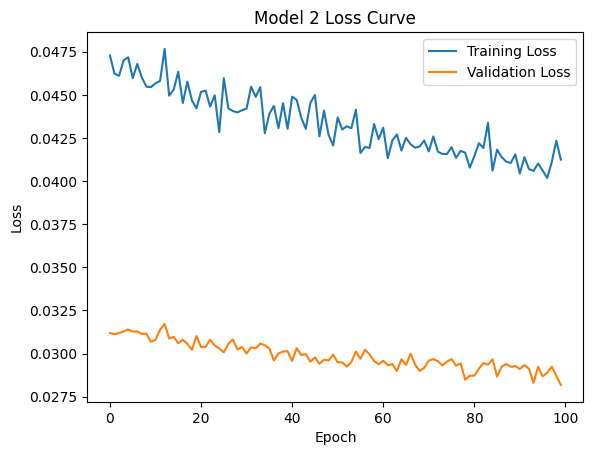

In [ ]:
# Plot training and validation loss across epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add title and axis labels
plt.title('Model 2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Display legend
plt.legend()

# Import os module for directory and file operations
import os

# Create folder
os.makedirs("7. Model 2 Loss Curve", exist_ok=True)

# Save figure into folder
plt.savefig(f"7. Model 2 Loss Curve/{feature}.png", bbox_inches='tight')

# Show plot
plt.show()

**Observations:**
* The loss curve of Model 2 demonstrates stable and effective learning performance throughout the training process. The training loss gradually decreased from approximately 0.047 to around 0.041 over the 100 training epochs, indicating that the artificial neural network continuously improved its ability to minimize prediction error on the training dataset.

* Similarly, the validation loss consistently decreased from approximately 0.031 to around 0.028 during training. The validation loss remained lower than the training loss throughout the learning process, suggesting that the model generalized well to unseen validation data and that the dropout regularization effectively reduced overfitting.

* The relatively smooth decline of both training and validation loss curves indicates stable optimization behavior and successful convergence of the model. In addition, the absence of large fluctuations or divergence between the two curves suggests that Model 2 maintained balanced learning performance without significant overfitting or underfitting.

* Overall, the loss curve results indicate that the introduction of dropout regularization and the expanded neural network architecture contributed to improved generalization capability and stable predictive performance for generator failure prediction.

In [ ]:
# Evaluate Model 2 performance using the training dataset
model_2_train_perf = model_performance_classification(
    model_2,
    X_train,
    y_train
)

# Display training performance metrics
model_2_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


{'Accuracy': 0.99325,
 'Precision': 0.9919273461150353,
 'Recall': 0.8855855855855855,
 'F1-Score': 0.9357448833888624}

* The performance of Model 2 on the training dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the predictive capability of the artificial neural network model on the training data. The results help determine how effectively the model learned patterns within the dataset and provide insight into the overall training performance of Model 2.

**Observations:**
* The training performance results indicate that Model 2 achieved excellent classification capability on the training dataset. The model processed the training data in 625 batches and required approximately 4 seconds to generate prediction probabilities and evaluation metrics.

* Model 2 achieved an overall training accuracy of approximately 99.33%, indicating that the artificial neural network correctly classified the vast majority of observations in the training dataset. The precision value of approximately 99.19% demonstrates that nearly all observations predicted as generator failure cases were actual failure cases, indicating very few false positive predictions.

* The recall value of approximately 88.56% indicates that the model successfully identified most of the actual generator failure observations within the training dataset. This result demonstrates strong failure detection capability, which is particularly important in predictive maintenance applications because undetected failures may lead to operational disruption and increased maintenance costs.

* In addition, the F1-score of approximately 93.57% indicates a strong balance between precision and recall, suggesting that Model 2 achieved highly reliable and balanced classification performance.

* Overall, these results demonstrate that the expanded neural network architecture and dropout regularization contributed to improved predictive capability and effective learning performance on the training dataset.

In [ ]:
# Evaluate Model 2 performance using the validation dataset
model_2_val_perf = model_performance_classification(
    model_2,
    X_val,
    y_val
)

# Display validation performance metrics
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'Accuracy': 0.99475,
 'Precision': 0.9902439024390244,
 'Recall': 0.9144144144144144,
 'F1-Score': 0.9508196721311475}

* The performance of Model 2 on the validation dataset is evaluated using the model_performance_classification() function. This evaluation calculates classification metrics, including accuracy, precision, recall, and F1-score, to assess the generalization capability of the artificial neural network model on previously unseen validation data. The validation performance results are important for determining whether the model can maintain stable and reliable predictive capability beyond the training dataset while minimizing overfitting.

**Observations:**
* The validation performance results indicate that Model 2 achieved excellent predictive capability and strong generalization performance on unseen validation data. The model processed the validation dataset in 125 batches and required less than one second to generate prediction probabilities and evaluation metrics.

* Model 2 achieved an overall validation accuracy of approximately 99.48%, indicating that the artificial neural network correctly classified nearly all observations within the validation dataset. The precision value of approximately 99.02% demonstrates that the model produced very few false positive predictions, meaning that almost all predicted generator failure cases were actual failures.

* The recall value of approximately 91.44% indicates that the model successfully detected the majority of actual generator failure observations in the validation dataset. This result reflects improved failure detection capability and demonstrates the effectiveness of the modified neural network architecture and dropout regularization in identifying generator failures.

* In addition, the F1-score of approximately 95.08% indicates a highly balanced relationship between precision and recall, suggesting strong overall classification performance. Compared to previous models, the improved recall and F1-score values indicate that Model 2 achieved better balance between minimizing false positives and maximizing failure detection capability.

* Overall, the validation results suggest that Model 2 generalized very well to unseen data and achieved highly reliable predictive performance for generator failure prediction in predictive maintenance applications.

In [ ]:
# Generate prediction probabilities for the training dataset
y_train_pred_2 = model_2.predict(X_train)

# Generate prediction probabilities for the validation dataset
y_val_pred_2 = model_2.predict(X_val)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


* Prediction probabilities are generated for both the training and validation datasets using the trained Model 2 artificial neural network. These prediction probabilities represent the likelihood of generator failure for each observation and are subsequently used for classification performance evaluation, including the generation of classification reports and additional performance metrics. Evaluating predictions on both datasets helps assess the model’s learning capability on training data as well as its generalization performance on unseen validation data.

**Observations:**
* The trained Model 2 artificial neural network successfully generated prediction probabilities for both the training and validation datasets. The prediction process for the training dataset was completed in 625 batches and required approximately 2 seconds, while the prediction process for the validation dataset was completed in 125 batches and required less than one second.

* These results indicate that the model performed prediction computations efficiently despite the increased complexity of the neural network architecture and the inclusion of dropout regularization. The generated prediction probabilities are subsequently used for classification performance evaluation, including the calculation of accuracy, precision, recall, F1-score, and classification reports for both training and validation datasets.

* Overall, the prediction process demonstrates that Model 2 maintained good computational efficiency while achieving strong predictive capability for generator failure prediction.

In [ ]:
# Display title for training classification report
print("Classification Report - Training Data Model_2", end="\n\n")

# Generate classification report using training dataset
cr_train_model_2 = classification_report(

    # Actual training labels
    y_train,

    # Convert prediction probabilities into binary predictions
    y_train_pred_2 > 0.5
)

# Display training classification report
print(cr_train_model_2)

Classification Report - Training Data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     18890
           1       0.99      0.89      0.94      1110

    accuracy                           0.99     20000
   macro avg       0.99      0.94      0.97     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the predictive performance of Model 2 in detail. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before performance evaluation is conducted. The classification report provides comprehensive evaluation metrics, including precision, recall, F1-score, and support for each target class, allowing detailed assessment of the model’s classification capability and learning performance on the training dataset.

**Observations:**
* The classification report for the training dataset indicates that Model 2 achieved excellent predictive performance and highly balanced classification capability. For Class 0 (No Failure), the model achieved a precision of 99% and a recall of 100%, resulting in an F1-score of 100%. These results indicate that the model classified no-failure observations with extremely high accuracy and produced almost no misclassification errors for the majority class.

* For Class 1 (Failure), the model achieved a precision of 99%, indicating that nearly all observations predicted as generator failures were actual failure cases. The recall value of 89% demonstrates that the model successfully identified most of the actual generator failure observations within the training dataset. In addition, the F1-score of 94% indicates a strong balance between precision and recall for generator failure detection.

* The overall training accuracy reached approximately 99%, confirming that the artificial neural network model correctly classified the vast majority of observations in the training dataset. The macro average F1-score of approximately 97% further demonstrates balanced classification performance across both target classes despite the class imbalance in the dataset. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive performance.

* Overall, the training classification results suggest that Model 2 effectively learned the underlying patterns within the generator sensor data and achieved strong generator failure prediction capability while maintaining balanced classification performance.

In [ ]:
# Display title for validation classification report
print("Classification Report - Validation Data Model_2", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_2 = classification_report(

    # Actual validation labels
    y_val,

    # Convert prediction probabilities into binary predictions
    y_val_pred_2 > 0.5
)

# Display validation classification report
print(cr_val_model_2)

Classification Report - Validation Data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.99      0.91      0.95       222

    accuracy                           0.99      4000
   macro avg       0.99      0.96      0.97      4000
weighted avg       0.99      0.99      0.99      4000



* A classification report is generated for the validation dataset to evaluate

**Observations:**
* The classification report for the validation dataset indicates that Model 2 achieved excellent predictive performance and strong generalization capability on unseen data. For Class 0 (No Failure), the model achieved a precision of 99% and a recall of 100%, resulting in an F1-score of 100%. These results indicate that the model classified no-failure observations with extremely high accuracy and produced almost no false positive or false negative predictions for the majority class.

* For Class 1 (Failure), the model achieved a precision of 99%, indicating that nearly all observations predicted as generator failures were actual failure cases. The recall value of 91% demonstrates that the model successfully identified most of the actual generator failure observations in the validation dataset. In addition, the F1-score of 95% indicates a highly balanced relationship between precision and recall for generator failure detection.

* The overall validation accuracy reached approximately 99%, demonstrating that the artificial neural network correctly classified nearly all observations within the validation dataset. Furthermore, the macro average F1-score of approximately 97% indicates balanced classification performance across both classes despite the imbalanced dataset distribution. The weighted average values close to 99% further confirm the model’s strong and reliable overall predictive capability.

* Overall, the validation classification results suggest that Model 2 generalized very effectively to unseen operational data and achieved highly reliable generator failure prediction performance while maintaining strong balance between failure detection capability and classification precision.

## **9.c. Model 3**

* After evaluating the performance of Model 2, additional model improvement experiments are conducted to further enhance predictive capability and optimize generator failure detection performance. Model 3 is developed by introducing additional architectural and training modifications aimed at improving model generalization, classification stability, and failure detection capability while maintaining high predictive accuracy.

In [ ]:
# Calculate class weights to handle class imbalance in the dataset
cw = (
    y_train.shape[0] /                     # Total number of training observations
    np.bincount(y_train.astype(int))      # Count observations in each target class
)

# Create dictionary to store class weights
cw_dict = {}

# Assign calculated weight to each class label
for i in range(cw.shape[0]):

    # Map class index to corresponding class weight
    cw_dict[i] = cw[i]

# Display class weight dictionary
cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

* Class weights are calculated to address the class imbalance present within the generator failure prediction dataset. Because failure observations occur less frequently than no-failure observations, the artificial neural network may become biased toward the majority class during training. To mitigate this issue, class weights are computed based on the distribution of target classes within the training dataset. Higher weights are assigned to minority failure observations, allowing the model to place greater emphasis on correctly identifying generator failures during the learning process. The calculated class weights are subsequently stored in a dictionary structure for integration into the neural network training procedure.

**Observations:**
* The calculated class weight results indicate that the dataset is highly imbalanced between the no-failure class (0) and the failure class (1). Class 0 was assigned a weight of approximately 1.06, while Class 1 received a substantially larger weight of approximately 18.02.

* This difference in class weights means that the artificial neural network model will place much greater importance on correctly classifying generator failure observations during training. Because failure cases occur far less frequently than no-failure observations, the larger weight assigned to Class 1 helps compensate for the imbalance by increasing the penalty when the model incorrectly predicts failure observations.

* The relatively small weight assigned to Class 0 indicates that no-failure observations dominate the dataset and therefore require less emphasis during training. In contrast, the much larger weight for Class 1 encourages the model to improve failure detection capability, reduce false negative predictions, and increase recall performance.

* Overall, the calculated class weights help improve balanced classification learning and strengthen the model’s ability to detect generator failures effectively in predictive maintenance applications.

In [ ]:
# Clear the current Keras session to reset previously created models and layers,
# helping free memory and prevent conflicts between different ANN model experiments.
tf.keras.backend.clear_session()

In [ ]:
# Initialize Model 3 artificial neural network
model_3 = Sequential()

# First hidden layer with 64 neurons and ReLU activation function
model_3.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train.shape[1]
    )
)

# Apply dropout regularization with 50% dropout rate
model_3.add(
    Dropout(0.5)
)

# Second hidden layer with 32 neurons and ReLU activation function
model_3.add(
    Dense(
        32,
        activation="relu"
    )
)

# Third hidden layer with 16 neurons and ReLU activation function
model_3.add(
    Dense(
        16,
        activation="relu"
    )
)

# Output layer with sigmoid activation function for binary classification
model_3.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

* Model 3 is developed using a multilayer artificial neural network architecture consisting of three hidden layers with 64, 32, and 16 neurons, respectively. The ReLU activation function is applied in each hidden layer to efficiently learn complex nonlinear relationships within the generator sensor data. Dropout regularization with a dropout rate of 50% is introduced after the first hidden layer to reduce overfitting and improve model generalization capability. The output layer contains one neuron with a sigmoid activation function to generate prediction probabilities for the binary classification problem of generator failure prediction. The architecture of Model 3 is designed to improve predictive performance, enhance failure detection capability, and strengthen classification stability in predictive maintenance applications.

In [ ]:
# Display the architecture summary of Model 3
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

* The summary() function is used to display the complete architecture of Model 3, including the structure of each neural network layer, output dimensions, and the number of trainable parameters. This summary provides an overview of the complexity and configuration of the artificial neural network model before the training process is performed.

**Observations:**
* The architecture summary of Model 3 shows that the artificial neural network consists of four dense layers and one dropout regularization layer. The first hidden layer contains 64 neurons and produces an output shape of (None, 64). This layer includes 2,624 trainable parameters, representing the weights and bias values connected to the 40 input predictor variables.

* A dropout layer is applied immediately after the first hidden layer with the same output shape of (None, 64). The dropout layer contains no trainable parameters because its purpose is solely to randomly deactivate neurons during training to reduce overfitting and improve generalization capability.

* The second hidden layer contains 32 neurons with 2,080 trainable parameters, while the third hidden layer contains 16 neurons with 528 trainable parameters. These additional hidden layers allow the model to progressively learn more abstract and complex feature representations from the generator sensor data.

* The output layer contains one neuron with a sigmoid activation function and 17 trainable parameters. This output layer generates prediction probabilities between 0 and 1 for the binary classification task of generator failure prediction.

* Overall, Model 3 contains a total of 5,249 trainable parameters with no non-trainable parameters. The architecture demonstrates a relatively deep and moderately complex neural network structure designed to improve predictive performance, strengthen failure detection capability, and enhance generalization performance for predictive maintenance applications.

In [ ]:
# Define Adam optimizer for Model 3
optimizer = tf.keras.optimizers.Adam()

# Compile Model 3
model_3.compile(

    # Loss function used for binary classification problems
    loss='binary_crossentropy',

    # Optimization algorithm used to update model weights
    optimizer=optimizer,

    # Evaluation metrics used to monitor model performance
    metrics=[

        # Measure overall classification accuracy
        'accuracy',

        # Measure reliability of positive failure predictions
        tf.keras.metrics.Precision(),

        # Measure ability to correctly detect actual failures
        tf.keras.metrics.Recall()
    ]
)

* The Adam optimizer is selected for Model 3 to improve optimization efficiency and accelerate convergence during the neural network training process. Adam is an adaptive optimization algorithm that automatically adjusts learning rates for individual parameters, allowing more stable and efficient weight updates compared to conventional stochastic gradient descent optimization.

* Model 3 is compiled using the binary cross-entropy loss function because the study involves a binary classification problem consisting of generator failure and no-failure observations. In addition, multiple evaluation metrics are included during training, namely accuracy, precision, and recall, to comprehensively assess classification performance. Accuracy measures overall prediction correctness, precision evaluates the reliability of predicted failure cases, and recall measures the model’s capability to correctly identify actual generator failures, which is particularly important in predictive maintenance applications where undetected failures may lead to operational disruption and increased maintenance costs.

In [ ]:
# Record starting time of Model 3 training
start = time.time()

# Train Model 3 using training and validation datasets
history = model_3.fit(

    # Training predictor variables
    X_train,

    # Training target variable
    y_train,

    # Validation dataset used to monitor generalization performance
    validation_data=(X_val, y_val),

    # Number of observations processed before updating model weights
    batch_size=batch_size,

    # Number of complete training iterations through the dataset
    epochs=epochs,

    # Apply class weights to handle imbalanced class distribution
    class_weight=cw_dict
)

# Record ending time of Model 3 training
end = time.time()

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8012 - loss: 0.9243 - precision: 0.1895 - recall: 0.7883 - val_accuracy: 0.8935 - val_loss: 0.3318 - val_precision: 0.3339 - val_recall: 0.9234
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9003 - loss: 0.6258 - precision: 0.3426 - recall: 0.8676 - val_accuracy: 0.9388 - val_loss: 0.2415 - val_precision: 0.4732 - val_recall: 0.9144
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9346 - loss: 0.5401 - precision: 0.4538 - recall: 0.8757 - val_accuracy: 0.9753 - val_loss: 0.1498 - val_precision: 0.7189 - val_recall: 0.9099
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9485 - loss: 0.4821 - precision: 0.5215 - recall: 0.8856 - val_accuracy: 0.9852 - val_loss: 0.1343 - val_precision: 0.8382 - val_recall: 0.9099
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9533 - loss: 0.4765 - precision: 0.5497 - recall: 0.8766 - val_accuracy: 0.9715 - val_los

* Model 3 is trained using the training dataset while simultaneously evaluating performance on the validation dataset during each training epoch. The validation dataset is included to monitor the model’s generalization capability and detect potential overfitting throughout the learning process. The training process uses the predefined batch size and number of epochs to iteratively optimize the neural network parameters and improve predictive performance.

* In addition, class weights are incorporated into the training process to address the imbalanced distribution between generator failure and no-failure observations. By assigning proportionally greater importance to minority failure cases, the artificial neural network is encouraged to improve failure detection capability and reduce bias toward the majority class. The training execution time is also recorded to evaluate the computational efficiency and training duration of Model 3.

**Observations:**
* The training results for Model 3 indicate that the artificial neural network achieved strong predictive performance and improved generator failure detection capability throughout the training process. The model was trained for 100 epochs using class weights to address the imbalanced dataset distribution, and both training and validation performance metrics showed substantial improvement over time.

* During the early training epochs, the model initially achieved relatively lower precision values while maintaining high recall performance. For example, in Epoch 1, the model achieved a training accuracy of approximately 80.12%, precision of 18.95%, and recall of 78.83%, while validation recall already reached approximately 92.34%. This indicates that the model initially prioritized identifying as many generator failure observations as possible, even though many false positive predictions were still present.

* As training progressed, both training and validation performance improved substantially. The model gradually learned more discriminative feature representations, resulting in increasing precision, accuracy, and stable recall values. By the middle training epochs, validation accuracy consistently exceeded 99%, while validation recall remained above 91%, demonstrating strong and stable generator failure detection capability. The inclusion of dropout regularization and class weighting contributed to improved generalization performance and reduced model bias toward the majority class.

* Toward the final training epochs, the model achieved highly stable performance metrics. At Epoch 100, the model achieved training accuracy of approximately 98.44%, precision of 82.61%, and recall of 91.17%, while the validation dataset achieved approximately 99.23% validation accuracy, 93.61% validation precision, and 92.34% validation recall. These results indicate that the model successfully balanced precision and recall while maintaining excellent classification capability on unseen validation data.

* The consistently high validation recall throughout the training process demonstrates that the use of class weights effectively improved the model’s capability to identify minority generator failure observations. This is particularly important in predictive maintenance applications because minimizing false negative predictions helps reduce the risk of undetected generator failures and operational disruption.

* Overall, the training results suggest that Model 3 achieved strong generalization capability, reliable predictive performance, and improved failure detection effectiveness compared to previous ANN models.

In [ ]:
# Display total training time for Model 3 in seconds
print("Time taken in seconds:", end - start)

Time taken in seconds: 243.6975016593933


**Observations:**
* The training process for Model 3 required approximately 243.70 seconds, or about 4.06 minutes, to complete 100 training epochs. This training duration reflects the computational time needed for the artificial neural network to iteratively learn patterns from the generator sensor dataset while applying dropout regularization, class weighting, and validation monitoring throughout the training process.

* Compared to the previous models, the longer training time is expected because Model 3 incorporates a more complex training configuration, including deeper network architecture, dropout regularization, adaptive optimization using the Adam optimizer, and class weighting for handling imbalanced data. In addition, the model continuously evaluated validation performance during each epoch, which also contributed to the total execution time.

* Despite the increased computational time, the training duration remains computationally reasonable considering the improved predictive performance, stronger generator failure detection capability, and enhanced generalization performance achieved by Model 3.

* Overall, the results indicate that the artificial neural network model maintained good computational efficiency while successfully optimizing predictive maintenance performance for generator failure prediction.

In [ ]:
# Import matplotlib library for visualization
import matplotlib.pyplot as plt

# Create function to plot training history
def plot(history, metric):

    # Plot training metric values
    plt.plot(history.history[metric])

    # Plot validation metric values
    plt.plot(history.history['val_' + metric])

    # Set plot title
    plt.title('Model ' + metric)

    # Set y-axis label
    plt.ylabel(metric)

    # Set x-axis label
    plt.xlabel('Epoch')

    # Define legend labels
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Display plot
    plt.show()

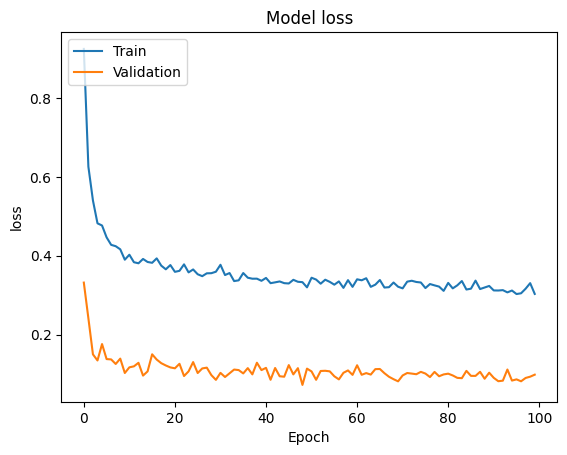

In [ ]:
# Plot training and validation loss curves
plot(history, 'loss')

**Observations:**
* The loss curve for Model 3 demonstrates that the artificial neural network achieved stable and effective learning performance throughout the training process. Both the training loss and validation loss decreased substantially during the early training epochs, indicating that the model successfully learned meaningful patterns from the generator sensor dataset and progressively reduced prediction errors.

* At the beginning of training, the training loss was relatively high, reflecting the initial learning stage where the model weights had not yet been optimized. However, the training loss rapidly decreased during the first several epochs, showing that the neural network quickly improved its predictive capability. Similarly, the validation loss also decreased sharply, indicating strong generalization performance on unseen validation data.

* As training progressed, both curves gradually stabilized and continued decreasing more slowly, suggesting that the model approached convergence and achieved stable optimization. The validation loss consistently remained lower than the training loss throughout the training process. This behavior is expected because Model 3 incorporates dropout regularization and class weighting during training. Dropout randomly deactivates neurons during training, making the training process more challenging and resulting in slightly higher training loss values, whereas validation evaluation is performed without dropout regularization.

* The absence of a substantial gap or divergence between the training and validation loss curves suggests that Model 3 did not experience severe overfitting. Instead, the model maintained stable learning behavior and demonstrated strong generalization capability on unseen validation data. The slight fluctuations observed in the training loss curve are normal in artificial neural network training, especially when using dropout regularization, adaptive optimization with the Adam optimizer, and class weighting for imbalanced data handling.

* Overall, the loss curve indicates that Model 3 achieved stable convergence, effective learning performance, improved generalization capability, and reliable predictive maintenance performance for generator failure prediction.

In [ ]:
# Evaluate Model 3 performance using the training dataset
model_3_train_perf = model_performance_classification(
    model_3,
    X_train,
    y_train
)

# Display training performance metrics
model_3_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


{'Accuracy': 0.9927,
 'Precision': 0.9496268656716418,
 'Recall': 0.9171171171171171,
 'F1-Score': 0.9330889092575618}

* The performance of Model 3 on the training dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the learning capability and predictive performance of the artificial neural network on the training data. The resulting metrics provide insight into the model’s ability to correctly classify generator failure and no-failure observations while handling the imbalanced class distribution.

**Observations:**
* The training performance results indicate that Model 3 achieved excellent predictive capability and strong classification performance on the training dataset. The artificial neural network processed the training dataset in 625 batches and required approximately one second to generate prediction probabilities and evaluation metrics.

* Model 3 achieved an overall training accuracy of approximately 99.27%, indicating that the model correctly classified nearly all observations within the training dataset. The precision value of approximately 94.96% demonstrates that most observations predicted as generator failures were actual failure cases, indicating a relatively low number of false positive predictions.

* The recall value of approximately 91.71% indicates that the model successfully identified the majority of actual generator failure observations within the training dataset. This result demonstrates strong generator failure detection capability and reflects the effectiveness of applying dropout regularization, class weighting, and adaptive optimization during training.

* In addition, the F1-score of approximately 93.31% indicates a strong balance between precision and recall, suggesting that Model 3 achieved highly reliable and balanced classification performance. The relatively high recall value is particularly important in predictive maintenance applications because it helps minimize false negative predictions, where actual generator failures could remain undetected.

* Overall, the training results suggest that Model 3 effectively learned the underlying patterns within the generator sensor data and achieved strong predictive maintenance performance while maintaining balanced classification capability across both target classes.

In [ ]:
# Evaluate Model 3 performance using the validation dataset
model_3_val_perf = model_performance_classification(
    model_3,
    X_val,
    y_val
)

# Display validation performance metrics
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'Accuracy': 0.99225,
 'Precision': 0.9360730593607306,
 'Recall': 0.9234234234234234,
 'F1-Score': 0.9297052154195011}

* The performance of Model 3 on the validation dataset is evaluated using the model_performance_classification() function. This evaluation calculates classification metrics, including accuracy, precision, recall, and F1-score, to assess the generalization capability and predictive performance of the artificial neural network on unseen validation data. The validation performance results help determine whether the model can maintain stable and reliable generator failure prediction capability while minimizing overfitting and improving balanced classification performance.

**Observations:**
* The validation performance results indicate that Model 3 achieved excellent predictive capability and strong generalization performance on unseen validation data. The artificial neural network processed the validation dataset in 125 batches and required less than one second to generate prediction probabilities and evaluation metrics.

* Model 3 achieved an overall validation accuracy of approximately 99.23%, indicating that the model correctly classified nearly all observations within the validation dataset. This high accuracy demonstrates that the model maintained stable predictive performance and generalized effectively beyond the training data.

* The precision value of approximately 93.61% indicates that most observations predicted as generator failures were actual failure cases, demonstrating a relatively low number of false positive predictions. In addition, the recall value of approximately 92.34% shows that the model successfully identified the majority of actual generator failure observations within the validation dataset. This strong recall performance is particularly important in predictive maintenance applications because it helps minimize false negative predictions and reduces the risk of undetected generator failures.

* Furthermore, the F1-score of approximately 92.97% indicates a strong balance between precision and recall, demonstrating that Model 3 achieved highly reliable and balanced classification performance. The similarity between training and validation performance metrics also suggests that the model generalized well and did not experience severe overfitting.

* Overall, the validation results demonstrate that Model 3 achieved strong predictive maintenance performance, reliable generator failure detection capability, and effective generalization on unseen operational data.

In [ ]:
# Generate prediction probabilities for training dataset
y_train_pred_3 = model_3.predict(X_train)

# Generate prediction probabilities for validation dataset
y_val_pred_3 = model_3.predict(X_val)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


* Prediction probabilities are generated for both the training and validation datasets using Model 3. These predictions represent the probability of each observation belonging to the generator failure class. The generated prediction probabilities are subsequently used for classification performance evaluation, including the calculation of accuracy, precision, recall, F1-score, and classification reports for both training and validation datasets.

**Observations:**
* The prediction process results indicate that Model 3 successfully generated prediction probabilities for both the training and validation datasets. The artificial neural network processed the training dataset in 625 batches and required approximately one second to complete prediction generation. Similarly, the validation dataset was processed in 125 batches and required less than one second to generate prediction probabilities.

* These results demonstrate that Model 3 achieved efficient computational performance during the prediction stage despite incorporating a deeper neural network architecture, dropout regularization, adaptive optimization, and class weighting. The relatively short prediction time indicates that the trained model can perform generator failure prediction efficiently and may be suitable for practical predictive maintenance applications that require timely failure detection and operational monitoring.

* The generated prediction probabilities are subsequently converted into binary class predictions using a threshold value of 0.5 and are used for further classification performance evaluation, including the generation of classification reports and additional performance metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
# Display title for training classification report
print("Classification Report - Training Data Model_3", end="\n\n")

# Generate classification report using training dataset
cr_train_model_3 = classification_report(

    # Actual training labels
    y_train,

    # Convert prediction probabilities into binary class predictions
    y_train_pred_3 > 0.5
)

# Display training classification report
print(cr_train_model_3)

Classification Report - Training Data Model_3

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18890
           1       0.95      0.92      0.93      1110

    accuracy                           0.99     20000
   macro avg       0.97      0.96      0.96     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the detailed classification performance of Model 3. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before performance evaluation is conducted. The classification report provides comprehensive performance metrics, including precision, recall, F1-score, and support for each target class, allowing detailed assessment of the model’s generator failure prediction capability and balanced classification performance on the training dataset.

**Observations:**
* The classification report for the training dataset indicates that Model 3 achieved excellent predictive performance and highly balanced classification capability. For Class 0 (No Failure), the model achieved perfect precision, recall, and F1-score values of 100%, indicating that nearly all no-failure observations were classified correctly with almost no misclassification errors.

* For Class 1 (Failure), the model achieved a precision of approximately 95%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the training dataset. In addition, the F1-score of approximately 93% indicates a strong balance between precision and recall for generator failure detection.

* The overall training accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the training dataset. The macro average F1-score of approximately 96% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive performance.

* Compared to previous models, Model 3 achieved stronger recall performance while maintaining high precision and accuracy. This improvement suggests that the combination of dropout regularization, adaptive optimization using the Adam optimizer, and class weighting effectively enhanced the model’s capability to detect generator failures while maintaining stable generalization performance.

* Overall, the training classification results demonstrate that Model 3 effectively learned the underlying patterns within the generator sensor data and achieved strong predictive maintenance capability with improved generator failure detection performance.

In [ ]:
# Display title for validation classification report
print("Classification Report - Validation Data Model_3", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_3 = classification_report(

    # Actual validation labels
    y_val,

    # Convert prediction probabilities into binary class predictions
    y_val_pred_3 > 0.5
)

# Display validation classification report
print(cr_val_model_3)

Classification Report - Validation Data Model_3

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3778
           1       0.94      0.92      0.93       222

    accuracy                           0.99      4000
   macro avg       0.97      0.96      0.96      4000
weighted avg       0.99      0.99      0.99      4000



* A classification report is generated for the validation dataset to evaluate the detailed predictive performance and generalization capability of Model 3 on unseen data. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before evaluation is performed. The classification report provides important performance metrics, including precision, recall, F1-score, and support for each target class, allowing comprehensive assessment of the model’s generator failure detection capability and balanced classification performance on the validation dataset.

**Observations:**
* The classification report for the validation dataset indicates that Model 3 achieved excellent predictive performance and strong generalization capability on unseen validation data. For Class 0 (No Failure), the model achieved perfect precision, recall, and F1-score values of 100%, indicating that nearly all no-failure observations were classified correctly with minimal misclassification errors.

* For Class 1 (Failure), the model achieved a precision of approximately 94%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the validation dataset. In addition, the F1-score of approximately 93% indicates a strong balance between precision and recall for generator failure detection performance.

* The overall validation accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the validation dataset. The macro average F1-score of approximately 96% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* The similarity between the training and validation classification results suggests that Model 3 generalized effectively and did not experience severe overfitting. The incorporation of dropout regularization, adaptive optimization using the Adam optimizer, and class weighting successfully improved the model’s capability to detect generator failures while maintaining stable and reliable classification performance.

* Overall, the validation classification results demonstrate that Model 3 achieved strong predictive maintenance performance, effective generator failure detection capability, and robust generalization performance on unseen operational data.

## **9.d. Model 4**

* After evaluating the performance of Model 3, additional optimization experiments are conducted to further improve neural network stability and predictive performance. Model 4 introduces batch normalization into the artificial neural network architecture to stabilize learning behavior, improve convergence efficiency, and enhance generalization capability during generator failure prediction.

In [ ]:
# Clear the current Keras session to remove previously created models and layers,
# helping free memory resources and prevent conflicts between ANN model experiments.
tf.keras.backend.clear_session()

In [ ]:
# Import BatchNormalization layer
from tensorflow.keras.layers import BatchNormalization

# Initialize Model 4 artificial neural network
model_4 = Sequential()

# First hidden layer with 64 neurons and ReLU activation function
model_4.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train.shape[1]
    )
)

# Apply batch normalization to stabilize training
model_4.add(
    BatchNormalization()
)

# Apply dropout regularization
model_4.add(
    Dropout(0.5)
)

# Second hidden layer with 32 neurons and ReLU activation function
model_4.add(
    Dense(
        32,
        activation="relu"
    )
)

# Apply batch normalization
model_4.add(
    BatchNormalization()
)

# Third hidden layer with 16 neurons and ReLU activation function
model_4.add(
    Dense(
        16,
        activation="relu"
    )
)

# Output layer with sigmoid activation for binary classification
model_4.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

* Model 4 is developed by extending the previous artificial neural network architecture through the incorporation of batch normalization layers in addition to dropout regularization. The model consists of three hidden layers containing 64, 32, and 16 neurons, respectively, with the ReLU activation function applied to each hidden layer to learn nonlinear relationships within the generator sensor dataset.

* Batch normalization layers are introduced after selected hidden layers to stabilize the learning process, improve gradient flow, accelerate convergence, and enhance generalization capability during training. Dropout regularization with a dropout rate of 50% is also retained to reduce overfitting by randomly deactivating neurons during training.

* The output layer contains one neuron with a sigmoid activation function to generate prediction probabilities for the binary classification task of generator failure prediction. The architecture of Model 4 is designed to further improve predictive performance, training stability, and generator failure detection capability in predictive maintenance applications.

In [ ]:
# Display the architecture summary of Model 4
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 192 (768.00 B)

* The summary() function is used to display the complete architecture of Model 4, including the structure of each neural network layer, output dimensions, and the number of trainable parameters. The summary also provides information regarding the incorporation of batch normalization and dropout regularization layers within the artificial neural network architecture. This overview helps evaluate the complexity and configuration of the model before the training process is performed.

**Observations:**
* The architecture summary of Model 4 indicates that the artificial neural network consists of four dense layers, two batch normalization layers, and one dropout regularization layer. The first hidden layer contains 64 neurons and produces an output shape of (None, 64). This layer includes 2,624 trainable parameters, representing the weights and bias values connected to the 40 input predictor variables.

* Following the first hidden layer, a batch normalization layer is applied with 256 parameters. Batch normalization standardizes the activations within the neural network during training, helping stabilize learning behavior, improve gradient flow, and accelerate convergence. Among these parameters, some are trainable while others are non-trainable statistical parameters used to store running averages of the batch statistics.

* A dropout layer is subsequently applied after batch normalization with the same output shape of (None, 64). The dropout layer contains no trainable parameters because its primary purpose is to randomly deactivate neurons during training to reduce overfitting and improve model generalization capability.

* The second hidden layer contains 32 neurons with 2,080 trainable parameters, followed by a second batch normalization layer containing 128 parameters. The third hidden layer contains 16 neurons with 528 trainable parameters, allowing the model to progressively learn more abstract and complex feature representations from the generator sensor dataset.

* The output layer contains one neuron with a sigmoid activation function and 17 trainable parameters. This output layer generates prediction probabilities between 0 and 1 for the binary classification task of generator failure prediction.

* Overall, Model 4 contains a total of 5,633 parameters, including 5,441 trainable parameters and 192 non-trainable parameters associated with the batch normalization layers. Compared to previous models, Model 4 incorporates additional normalization mechanisms designed to improve training stability, convergence efficiency, and generalization capability while maintaining strong predictive maintenance performance for generator failure prediction.

In [ ]:
# Define Adam optimizer for Model 4
optimizer = tf.keras.optimizers.Adam()

# Compile Model 4
model_4.compile(

    # Loss function used for binary classification problems
    loss='binary_crossentropy',

    # Optimization algorithm used to update neural network weights
    optimizer=optimizer,

    # Evaluation metrics used to monitor model performance
    metrics=[

        # Measure overall classification accuracy
        'accuracy',

        # Measure reliability of positive failure predictions
        tf.keras.metrics.Precision(),

        # Measure capability to correctly identify actual failures
        tf.keras.metrics.Recall()
    ]
)

* Model 4 is compiled using the Adam optimization algorithm and the binary cross-entropy loss function. The Adam optimizer is selected because it adaptively adjusts learning rates during training, enabling faster convergence, improved optimization stability, and more efficient neural network learning. This optimization approach is particularly suitable for deep artificial neural network architectures involving dropout regularization and batch normalization.

* The binary cross-entropy loss function is applied because the study involves a binary classification problem consisting of generator failure and no-failure observations. In addition, multiple evaluation metrics are incorporated during training, including accuracy, precision, and recall, to comprehensively evaluate model performance. Accuracy measures overall classification correctness, precision evaluates the reliability of predicted generator failure observations, and recall measures the model’s capability to correctly identify actual generator failures. Monitoring these metrics is especially important in predictive maintenance applications where failure detection capability directly influences operational reliability and maintenance effectiveness.

In [ ]:
# Record starting time of Model 4 training
start = time.time()

# Train Model 4 using training and validation datasets
history = model_4.fit(

    # Training predictor variables
    X_train,

    # Training target variable
    y_train,

    # Validation dataset used to monitor generalization performance
    validation_data=(X_val, y_val),

    # Number of observations processed before updating model weights
    batch_size=batch_size,

    # Number of complete training iterations through the dataset
    epochs=epochs,

    # Apply class weights to handle imbalanced class distribution
    class_weight=cw_dict
)

# Record ending time of Model 4 training
end = time.time()

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7903 - loss: 0.8772 - precision: 0.1830 - recall: 0.8018 - val_accuracy: 0.9265 - val_loss: 0.2403 - val_precision: 0.4247 - val_recall: 0.9144
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9133 - loss: 0.6018 - precision: 0.3772 - recall: 0.8622 - val_accuracy: 0.9475 - val_loss: 0.1909 - val_precision: 0.5152 - val_recall: 0.9189
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9307 - loss: 0.5356 - precision: 0.4379 - recall: 0.8766 - val_accuracy: 0.9715 - val_loss: 0.1360 - val_precision: 0.6800 - val_recall: 0.9189
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9387 - loss: 0.5035 - precision: 0.4720 - recall: 0.8793 - val_accuracy: 0.9682 - val_loss: 0.1371 - val_precision: 0.6518 - val_recall: 0.9189
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9480 - loss: 0.4799 - precision: 0.5185 - recall: 0.8838 - val_accuracy: 0.9678 - val_los

* Model 4 is trained using the training dataset while simultaneously evaluating performance on the validation dataset during each training epoch. The training process uses batch normalization, dropout regularization, adaptive optimization with the Adam optimizer, and class weighting to improve neural network stability, generalization capability, and generator failure detection performance.

* The validation dataset is incorporated during training to monitor model generalization performance and identify potential overfitting throughout the learning process. In addition, class weights are applied to address the imbalanced distribution between generator failure and no-failure observations, allowing the model to place greater emphasis on correctly identifying minority failure cases.

* The training process is performed using the predefined batch size and number of epochs, while the total training execution time is recorded to evaluate the computational efficiency and scalability of Model 4 for predictive maintenance applications.

**Observations:**
* The training results for Model 4 indicate that the artificial neural network achieved strong predictive performance, stable convergence behavior, and improved generalization capability throughout the 100 training epochs. The incorporation of batch normalization, dropout regularization, the Adam optimizer, and class weighting contributed to stable neural network learning and effective generator failure detection performance.

* During the early training epochs, the model initially achieved lower precision values while maintaining relatively high recall performance. For example, in Epoch 1, the model achieved approximately 79.03% training accuracy, 18.30% precision, and 80.18% recall, while validation recall already reached approximately 91.44%. This behavior indicates that the model initially focused on identifying as many generator failure observations as possible, although many false positive predictions were still present at the beginning of training.

* As training progressed, the model demonstrated substantial improvement in both training and validation performance metrics. The training and validation accuracy steadily increased, while loss values gradually decreased, indicating successful optimization and effective feature learning. Validation accuracy consistently exceeded 98% after the early epochs, while validation recall remained highly stable around 91–93%, demonstrating strong generator failure detection capability throughout the training process.

* The validation precision also improved substantially during training. In the early epochs, validation precision was below 50%, but it progressively increased to above 90% in later epochs. This improvement indicates that the model became more reliable in distinguishing actual generator failure observations from normal operating conditions while reducing false positive predictions.

* Toward the final training epochs, Model 4 achieved highly stable performance metrics. At Epoch 100, the model achieved approximately 98.09% training accuracy, 78.04% training precision, and 91.26% training recall, while the validation dataset achieved approximately 99.12% validation accuracy, 91.56% validation precision, and 92.79% validation recall. These results indicate that the model maintained excellent generalization performance and balanced classification capability on unseen validation data.

* The relatively stable validation loss and the absence of significant divergence between training and validation metrics suggest that Model 4 did not experience severe overfitting. The incorporation of batch normalization helped stabilize training behavior and improve convergence efficiency, while dropout regularization reduced excessive dependency on specific neurons during training.

* Overall, the training results demonstrate that Model 4 achieved strong predictive maintenance performance, reliable generator failure detection capability, stable convergence behavior, and effective generalization performance for predictive maintenance applications.

In [ ]:
# Display total training time for Model 4 in seconds
print("Time taken in seconds:", end - start)

Time taken in seconds: 281.9668490886688


**Observations:**
* The training process for Model 4 required approximately 281.97 seconds, or about 4.70 minutes, to complete 100 training epochs. This training duration reflects the computational time required for the artificial neural network to learn patterns from the generator sensor dataset while incorporating batch normalization, dropout regularization, adaptive optimization using the Adam optimizer, and class weighting for handling imbalanced data.

* Compared to the previous models, the slightly longer training time is expected because Model 4 includes additional batch normalization layers, which introduce extra computations during the forward and backward propagation processes. In addition, the model continuously evaluated validation performance during each epoch, contributing to the overall execution time.

* Despite the increased computational complexity, the training duration remains computationally reasonable considering the improved training stability, stronger generalization capability, and enhanced generator failure detection performance achieved by Model 4. The relatively efficient training time also suggests that the proposed artificial neural network architecture remains practical and scalable for predictive maintenance applications involving real-world operational monitoring systems.

* Overall, the results indicate that Model 4 successfully balanced computational efficiency and predictive performance while achieving stable neural network optimization and reliable generator failure prediction capability.

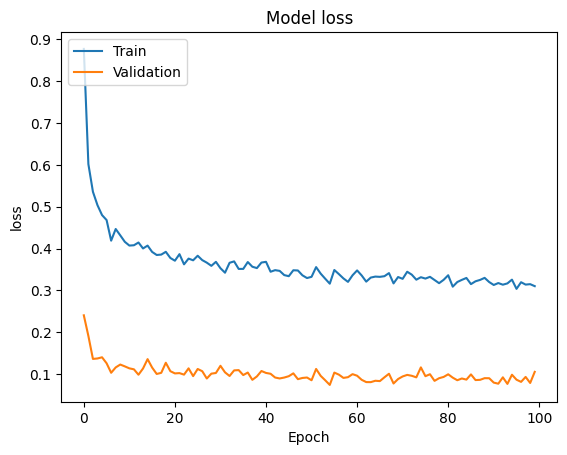

In [ ]:
# Plot training and validation loss curves for Model 4
plot(history, 'loss')

**Observations:**
* The loss curve for Model 4 indicates that the artificial neural network achieved stable convergence and effective learning performance throughout the training process. Both the training loss and validation loss decreased substantially during the early training epochs, demonstrating that the model successfully learned meaningful patterns from the generator sensor dataset and progressively reduced prediction errors.

* At the beginning of training, the training loss was relatively high, reflecting the initial stage of neural network optimization where the model weights had not yet adapted to the dataset. However, the training loss rapidly decreased within the first several epochs, indicating that the model quickly improved its predictive capability and successfully optimized the network parameters.

* The validation loss also decreased sharply during the early epochs and remained consistently lower than the training loss throughout most of the training process. This behavior is expected because dropout regularization is applied only during training, making the training process more challenging and resulting in slightly higher training loss values. In addition, batch normalization helped stabilize learning behavior and improve convergence efficiency across the training epochs.

* As training progressed, both curves gradually stabilized and exhibited relatively small fluctuations, suggesting that the model achieved stable optimization and effective generalization capability. The absence of a substantial divergence between the training and validation loss curves indicates that Model 4 did not experience severe overfitting and maintained strong performance on unseen validation data.

* The validation loss remained relatively low and stable throughout the later training epochs, demonstrating that the model generalized effectively and maintained reliable generator failure prediction capability. The slight fluctuations observed in the curves are normal in artificial neural network training, especially when dropout regularization, batch normalization, adaptive optimization, and class weighting are simultaneously applied.

* Overall, the loss curve demonstrates that Model 4 achieved stable convergence, strong generalization performance, effective training stability, and reliable predictive maintenance capability for generator failure prediction.

In [ ]:
# Evaluate Model 4 performance using the training dataset
model_4_train_perf = model_performance_classification(
    model_4,
    X_train,
    y_train
)

# Display training performance metrics
model_4_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


{'Accuracy': 0.99135,
 'Precision': 0.9216921692169217,
 'Recall': 0.9225225225225225,
 'F1-Score': 0.9221071589374156}

* The performance of Model 4 on the training dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the predictive capability and learning performance of the artificial neural network on the training data. The resulting performance metrics provide insight into the model’s ability to correctly classify generator failure and no-failure observations while maintaining balanced classification performance despite the imbalanced dataset distribution.

**Observations:**
* The training performance results indicate that Model 4 achieved excellent predictive capability and highly balanced classification performance on the training dataset. The artificial neural network processed the training dataset in 625 batches and required approximately three seconds to generate prediction probabilities and evaluation metrics.

* Model 4 achieved an overall training accuracy of approximately 99.14%, indicating that the model correctly classified nearly all observations within the training dataset. The precision value of approximately 92.17% demonstrates that most observations predicted as generator failures were actual failure cases, indicating a relatively low number of false positive predictions.

* The recall value of approximately 92.25% indicates that the model successfully identified the majority of actual generator failure observations within the training dataset. This strong recall performance demonstrates effective generator failure detection capability and reflects the contribution of batch normalization, dropout regularization, adaptive optimization, and class weighting during training.

* In addition, the F1-score of approximately 92.21% indicates a strong balance between precision and recall, suggesting that Model 4 achieved reliable and balanced classification performance across both target classes. The similarity between precision and recall values further indicates that the model maintained stable predictive behavior without excessively favoring either false positive reduction or failure detection sensitivity.

* Overall, the training results demonstrate that Model 4 effectively learned meaningful patterns from the generator sensor data and achieved strong predictive maintenance performance while maintaining balanced generator failure detection capability.

In [ ]:
# Evaluate Model 4 performance using the validation dataset
model_4_val_perf = model_performance_classification(
    model_4,
    X_val,
    y_val
)

# Display validation performance metrics
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'Accuracy': 0.99125,
 'Precision': 0.9155555555555556,
 'Recall': 0.9279279279279279,
 'F1-Score': 0.9217002237136466}

* The performance of Model 4 on the validation dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the generalization capability and predictive performance of the artificial neural network on unseen validation data. The resulting validation metrics help determine whether the model can maintain stable and reliable generator failure prediction capability while minimizing overfitting and improving balanced classification performance.

**Observations:**
* The validation performance results indicate that Model 4 achieved excellent predictive capability and strong generalization performance on unseen validation data. The artificial neural network processed the validation dataset in 125 batches and required approximately one second to generate prediction probabilities and evaluation metrics.

* Model 4 achieved an overall validation accuracy of approximately 99.13%, indicating that the model correctly classified nearly all observations within the validation dataset. This high accuracy demonstrates that the model generalized effectively beyond the training data and maintained stable predictive performance on unseen observations.

* The precision value of approximately 91.56% indicates that most observations predicted as generator failures were actual failure cases, demonstrating a relatively low number of false positive predictions. In addition, the recall value of approximately 92.79% shows that the model successfully identified the majority of actual generator failure observations within the validation dataset. This strong recall performance is particularly important in predictive maintenance applications because it helps minimize false negative predictions and reduces the risk of undetected generator failures.

* Furthermore, the F1-score of approximately 92.17% indicates a strong balance between precision and recall, demonstrating that Model 4 achieved reliable and balanced classification performance. The similarity between the training and validation performance metrics also suggests that the model generalized well and did not experience severe overfitting despite the relatively complex neural network architecture.

* Overall, the validation results demonstrate that Model 4 achieved strong predictive maintenance capability, stable generalization performance, and reliable generator failure detection performance on unseen operational data.

In [ ]:
# Generate prediction probabilities for training dataset
y_train_pred_4 = model_4.predict(X_train)

# Generate prediction probabilities for validation dataset
y_val_pred_4 = model_4.predict(X_val)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


* Prediction probabilities are generated for both the training and validation datasets using Model 4. These predictions represent the probability of each observation belonging to the generator failure class. The generated prediction probabilities are subsequently used to evaluate classification performance, including the calculation of accuracy, precision, recall, F1-score, and classification reports for both training and validation datasets. This evaluation helps assess the predictive capability and generalization performance of the artificial neural network model.

**Observations:**
* The prediction process results indicate that Model 4 successfully generated prediction probabilities for both the training and validation datasets. The artificial neural network processed the training dataset in 625 batches and required approximately two seconds to complete prediction generation. Similarly, the validation dataset was processed in 125 batches and required less than one second to generate prediction probabilities.

* These results demonstrate that Model 4 maintained efficient computational performance during the prediction stage despite incorporating a deeper neural network architecture, dropout regularization, batch normalization, adaptive optimization using the Adam optimizer, and class weighting for handling imbalanced data. The relatively short prediction time indicates that the trained model can perform generator failure prediction efficiently and may be suitable for practical predictive maintenance applications requiring timely operational monitoring and failure detection.

* The generated prediction probabilities are subsequently converted into binary class predictions using a threshold value of 0.5 and are used for further classification performance evaluation, including the generation of classification reports and additional performance metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
# Display title for training classification report
print("Classification Report - Training Data Model_4", end="\n\n")

# Generate classification report using training dataset
cr_train_model_4 = classification_report(

    # Actual training labels
    y_train,

    # Convert prediction probabilities into binary class predictions
    y_train_pred_4 > 0.5
)

# Display training classification report
print(cr_train_model_4)

Classification Report - Training Data Model_4

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18890
           1       0.92      0.92      0.92      1110

    accuracy                           0.99     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the detailed classification performance of Model 4. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before performance evaluation is performed. The classification report provides comprehensive performance metrics, including precision, recall, F1-score, and support for each target class, allowing detailed assessment of the model’s generator failure detection capability and balanced classification performance on the training dataset.

**Observations:**
* The classification report for the training dataset indicates that Model 4 achieved excellent predictive performance and highly balanced classification capability. For Class 0 (No Failure), the model achieved perfect precision, recall, and F1-score values of 100%, indicating that nearly all no-failure observations were classified correctly with minimal misclassification errors.

* For Class 1 (Failure), the model achieved precision, recall, and F1-score values of approximately 92%. The precision value indicates that most observations predicted as generator failures were actual failure cases, while the recall value demonstrates that the model successfully identified the majority of actual generator failure observations within the training dataset. The balanced precision and recall values suggest that Model 4 maintained stable classification performance without excessively favoring either false positive reduction or failure detection sensitivity.

* The overall training accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the training dataset. The macro average F1-score of approximately 96% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* Compared to the previous models, Model 4 maintained strong and stable generator failure detection capability while incorporating batch normalization to improve training stability and convergence efficiency. The similarity between the precision and recall values also indicates that the model achieved well-balanced predictive performance for both majority and minority classes.

* Overall, the training classification results demonstrate that Model 4 effectively learned meaningful patterns from the generator sensor data and achieved strong predictive maintenance capability with reliable and balanced generator failure detection performance.

In [ ]:
# Display title for validation classification report
print("Classification Report - Validation Data Model_4", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_4 = classification_report(

    # Actual validation labels
    y_val,

    # Convert prediction probabilities into binary class predictions
    y_val_pred_4 > 0.5
)

# Display validation classification report
print(cr_val_model_4)

Classification Report - Validation Data Model_4

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3778
           1       0.92      0.93      0.92       222

    accuracy                           0.99      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.99      0.99      0.99      4000



* A classification report is generated for the validation dataset to evaluate the detailed predictive performance and generalization capability of Model 4 on unseen data. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before evaluation is performed. The classification report provides important performance metrics, including precision, recall, F1-score, and support for each target class, allowing comprehensive assessment of the model’s generator failure detection capability and balanced classification performance on the validation dataset.

**Observations:**
* The classification report for the validation dataset indicates that Model 4 achieved excellent predictive performance and strong generalization capability on unseen validation data. For Class 0 (No Failure), the model achieved precision and F1-score values of approximately 100%, while the recall value was approximately 99%, indicating that nearly all no-failure observations were classified correctly with very few misclassification errors.

* For Class 1 (Failure), the model achieved a precision value of approximately 92%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 93% demonstrates that the model successfully identified the majority of actual generator failure observations within the validation dataset. In addition, the F1-score of approximately 92% indicates a strong balance between precision and recall for generator failure detection performance.

* The overall validation accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the validation dataset. The macro average F1-score of approximately 96% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* The similarity between the training and validation classification results suggests that Model 4 generalized effectively and did not experience severe overfitting. The incorporation of batch normalization, dropout regularization, adaptive optimization using the Adam optimizer, and class weighting successfully improved training stability, generalization capability, and balanced generator failure detection performance.

* Overall, the validation classification results demonstrate that Model 4 achieved strong predictive maintenance performance, reliable generator failure detection capability, and robust generalization performance on unseen operational data.

## **9.e. Model 5**

* After evaluating the performance of Model 4, additional optimization experiments are conducted to further improve convergence stability and predictive performance. Model 5 introduces learning rate optimization within the Adam optimizer to enhance neural network training efficiency, stabilize gradient updates, and improve generator failure detection capability.

In [ ]:
# Clear the current Keras session to remove previously created models and layers,
# helping free memory resources and prevent conflicts between ANN model experiments.
tf.keras.backend.clear_session()

In [ ]:
# Import required neural network layers
from tensorflow.keras.layers import Dropout, BatchNormalization

# Initialize Model 5 artificial neural network
model_5 = Sequential()

# First hidden layer with 64 neurons and ReLU activation function
model_5.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train.shape[1]
    )
)

# Apply batch normalization
model_5.add(
    BatchNormalization()
)

# Apply dropout regularization with 50% dropout rate
model_5.add(
    Dropout(0.5)
)

# Second hidden layer with 32 neurons and ReLU activation function
model_5.add(
    Dense(
        32,
        activation="relu"
    )
)

# Apply batch normalization
model_5.add(
    BatchNormalization()
)

# Third hidden layer with 16 neurons and ReLU activation function
model_5.add(
    Dense(
        16,
        activation="relu"
    )
)

# Output layer with sigmoid activation function for binary classification
model_5.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

* Model 5 is developed using a multilayer artificial neural network architecture consisting of three hidden layers with 64, 32, and 16 neurons, respectively. The ReLU activation function is applied to each hidden layer to enable the neural network to learn complex nonlinear relationships within the generator sensor dataset.

* Batch normalization layers are incorporated after selected hidden layers to stabilize the training process, improve gradient flow, accelerate convergence, and enhance generalization capability. In addition, dropout regularization with a dropout rate of 50% is applied after the first hidden layer to reduce overfitting by randomly deactivating neurons during training.

* The output layer contains one neuron with a sigmoid activation function to generate prediction probabilities for the binary classification task of generator failure prediction. Model 5 retains the optimized neural network architecture from Model 4 while preparing for further optimization experiments through learning rate adjustment within the Adam optimization algorithm.

In [ ]:
# Display the architecture summary of Model 5
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 192 (768.00 B)

* The summary() function is used to display the complete architecture of Model 5, including the structure of each neural network layer, output dimensions, and the number of trainable parameters. The summary also provides information regarding the incorporation of batch normalization and dropout regularization layers within the artificial neural network architecture. This overview helps evaluate the complexity, parameter distribution, and overall configuration of the model before the training process is performed.

**Observations:**
* The architecture summary of Model 5 indicates that the artificial neural network consists of four dense layers, two batch normalization layers, and one dropout regularization layer. The overall architecture of Model 5 is identical to Model 4 because the primary experimental focus in Model 5 is learning rate optimization within the Adam optimizer rather than architectural modification.

* The first hidden layer contains 64 neurons and produces an output shape of (None, 64). This layer includes 2,624 trainable parameters, representing the weights and bias values connecting the input features to the first hidden layer. Following this layer, a batch normalization layer is applied with 256 parameters to stabilize neural network training, improve gradient flow, and accelerate convergence.

* A dropout layer is subsequently incorporated after batch normalization with the same output shape of (None, 64). The dropout layer contains no trainable parameters because its primary function is to randomly deactivate neurons during training to reduce overfitting and improve generalization capability.

* The second hidden layer contains 32 neurons with 2,080 trainable parameters and is followed by a second batch normalization layer containing 128 parameters. The third hidden layer contains 16 neurons with 528 trainable parameters, allowing the model to progressively learn more abstract feature representations from the generator sensor dataset.

* The output layer contains one neuron with a sigmoid activation function and 17 trainable parameters. This output layer generates prediction probabilities between 0 and 1 for the binary classification task of generator failure prediction.

* Overall, Model 5 contains a total of 5,633 parameters, including 5,441 trainable parameters and 192 non-trainable parameters associated with the batch normalization layers. The incorporation of dropout regularization, batch normalization, and the optimized neural network structure is designed to improve training stability, convergence efficiency, generalization capability, and predictive maintenance performance for generator failure prediction.

In [ ]:
# Define Adam optimizer with optimized learning rate
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

# Compile Model 5
model_5.compile(

    # Loss function used for binary classification problems
    loss='binary_crossentropy',

    # Optimization algorithm used to update neural network weights
    optimizer=optimizer,

    # Evaluation metrics used to monitor model performance
    metrics=[

        # Measure overall classification accuracy
        'accuracy',

        # Measure reliability of positive failure predictions
        tf.keras.metrics.Precision(),

        # Measure capability to correctly identify actual failures
        tf.keras.metrics.Recall()
    ]
)

* Model 5 is compiled using the Adam optimization algorithm with a reduced learning rate of 0.0005 and the binary cross-entropy loss function. Learning rate optimization is introduced in Model 5 to improve training stability, reduce oscillations during gradient updates, and enhance convergence behavior throughout the neural network training process.

* The Adam optimizer is selected because it adaptively adjusts learning rates during training, enabling efficient optimization and faster convergence for deep artificial neural network architectures. Reducing the learning rate allows the model to perform more stable and gradual weight updates, which may improve predictive performance and generalization capability on unseen validation data.

* The binary cross-entropy loss function is applied because the study involves a binary classification problem consisting of generator failure and no-failure observations. In addition, multiple evaluation metrics are incorporated during training, including accuracy, precision, and recall, to comprehensively evaluate predictive maintenance performance. These metrics are particularly important for assessing balanced classification capability and generator failure detection effectiveness in imbalanced operational datasets.

In [ ]:
# Record starting time of Model 5 training
start = time.time()

# Train Model 5 using training and validation datasets
history = model_5.fit(

    # Training predictor variables
    X_train,

    # Training target variable
    y_train,

    # Validation dataset used to monitor generalization performance
    validation_data=(X_val, y_val),

    # Number of observations processed before updating model weights
    batch_size=batch_size,

    # Number of complete training iterations through the dataset
    epochs=epochs,

    # Apply class weights to handle imbalanced class distribution
    class_weight=cw_dict
)

# Record ending time of Model 5 training
end = time.time()

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7682 - loss: 0.9534 - precision: 0.1644 - recall: 0.7784 - val_accuracy: 0.9467 - val_loss: 0.2247 - val_precision: 0.5117 - val_recall: 0.8874
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8926 - loss: 0.6638 - precision: 0.3227 - recall: 0.8514 - val_accuracy: 0.9638 - val_loss: 0.1571 - val_precision: 0.6177 - val_recall: 0.9099
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9148 - loss: 0.5980 - precision: 0.3820 - recall: 0.8667 - val_accuracy: 0.9670 - val_loss: 0.1420 - val_precision: 0.6433 - val_recall: 0.9099
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9217 - loss: 0.5721 - precision: 0.4032 - recall: 0.8559 - val_accuracy: 0.9710 - val_loss: 0.1388 - val_precision: 0.6779 - val_recall: 0.9099
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9326 - loss: 0.5287 - precision: 0.4457 - recall: 0.8802 - val_accuracy: 0.9852 - val_lo

* Model 5 is trained using the training dataset while simultaneously evaluating performance on the validation dataset during each training epoch. The training process incorporates dropout regularization, batch normalization, adaptive optimization using the Adam optimizer with a reduced learning rate, and class weighting to improve convergence stability, generalization capability, and generator failure detection performance.

* The validation dataset is included during training to monitor model generalization performance and identify potential overfitting throughout the neural network learning process. In addition, class weights are applied to address the imbalanced distribution between generator failure and no-failure observations, allowing the model to place greater emphasis on correctly identifying minority failure cases.

* The training process is performed using the predefined batch size and number of epochs, while the total training execution time is recorded to evaluate the computational efficiency and scalability of Model 5 for predictive maintenance applications.

**Observations:**
* The training results for Model 5 indicate that the artificial neural network achieved stable convergence behavior, strong predictive performance, and effective generalization capability throughout the 100 training epochs. Model 5 incorporated dropout regularization, batch normalization, class weighting, and learning rate optimization using the Adam optimizer with a reduced learning rate of 0.0005, which contributed to more stable gradient updates and smoother training behavior.

* During the early training epochs, the model initially achieved relatively lower precision values while maintaining strong recall performance. For example, in Epoch 1, the model achieved approximately 76.82% training accuracy, 16.44% precision, and 77.84% recall, while validation recall already reached approximately 88.74%. This behavior indicates that the model initially prioritized identifying generator failure observations, although false positive predictions were still relatively high during the early learning stages.

* As training progressed, both training and validation performance metrics improved substantially. Training accuracy steadily increased while training and validation loss values gradually decreased, indicating successful optimization and effective neural network learning. Validation accuracy consistently remained above 98% after the early epochs, while validation recall remained highly stable around 91–93%, demonstrating strong generator failure detection capability throughout the training process.

* The validation precision also improved significantly during training. In the early epochs, validation precision was approximately 51%, but it progressively increased to approximately 88–92% in the later epochs. This improvement indicates that Model 5 became increasingly reliable in distinguishing actual generator failure observations from normal operational conditions while reducing false positive predictions.

* Compared to Model 4, the reduced learning rate in Model 5 produced smoother and more stable convergence behavior. The validation loss remained relatively stable throughout the later training epochs, indicating improved optimization stability and reduced oscillation during weight updates. The smaller learning rate allowed the neural network to perform more gradual parameter adjustments, contributing to stable generalization performance on unseen validation data.

* Toward the final training epochs, Model 5 achieved highly stable validation performance. At Epoch 100, the model achieved approximately 97.77% training accuracy, 74.67% training precision, and 90.54% training recall, while the validation dataset achieved approximately 98.93% validation accuracy, 88.74% validation precision, and 92.34% validation recall. These results demonstrate that the model maintained strong generator failure detection capability while achieving reliable predictive performance on unseen operational data.

* The absence of substantial divergence between the training and validation metrics suggests that Model 5 generalized effectively and did not experience severe overfitting. The incorporation of batch normalization, dropout regularization, class weighting, and learning rate optimization successfully improved training stability, convergence behavior, and balanced classification performance.

* Overall, the training results demonstrate that Model 5 achieved stable neural network optimization, strong predictive maintenance performance, reliable generator failure detection capability, and effective generalization performance for predictive maintenance applications.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  295.1832323074341


**Observations:**
* The training process for Model 5 required approximately 295.18 seconds, or about 4.92 minutes, to complete 100 training epochs. This training duration reflects the computational time required for the artificial neural network to learn patterns from the generator sensor dataset while incorporating dropout regularization, batch normalization, class weighting, and learning rate optimization using the Adam optimizer with a reduced learning rate.

* Compared to the previous models, the slightly longer training time is expected because Model 5 applied a smaller learning rate of 0.0005, causing the neural network to perform more gradual and stable weight updates during optimization. Smaller learning rates generally improve convergence stability and reduce oscillations during training, although they often require longer computational time to complete the learning process.

* In addition, the incorporation of batch normalization and dropout regularization layers contributed additional computations during forward and backward propagation. The continuous evaluation of validation performance during each epoch also increased the total training execution time.

* Despite the increased computational duration, the training time remains computationally reasonable considering the improved convergence stability, smoother learning behavior, strong generalization capability, and reliable generator failure detection performance achieved by Model 5. The results indicate that the optimized artificial neural network architecture remains practical and scalable for predictive maintenance applications involving real-world operational monitoring systems.

* Overall, the training time demonstrates that Model 5 successfully balanced computational efficiency, stable optimization behavior, and strong predictive maintenance performance while maintaining reliable generator failure detection capability

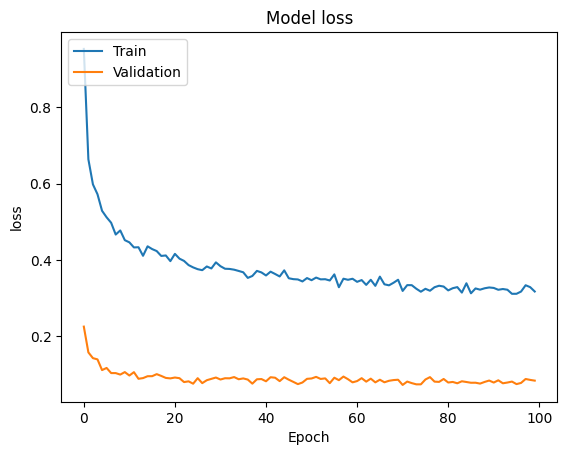

In [ ]:
# Plot training and validation loss curves for Model 5
plot(history, 'loss')

**Observations:**
* The loss curve for Model 5 demonstrates stable convergence behavior and effective neural network optimization throughout the training process. Both the training loss and validation loss decrease substantially during the early training epochs, indicating that the artificial neural network successfully learned meaningful patterns from the generator sensor dataset and progressively minimized prediction errors.

* At the beginning of training, the training loss was relatively high because the network weights were still randomly initialized and had not yet adapted to the dataset. However, the training loss rapidly decreased during the first several epochs, demonstrating that the model quickly improved its predictive capability and optimized the neural network parameters effectively.

* The validation loss also decreased sharply during the early epochs and remained consistently lower than the training loss throughout the majority of the training process. This behavior is expected because dropout regularization is applied only during training, making the training process more challenging and producing slightly higher training loss values. In addition, batch normalization and learning rate optimization contributed to more stable and smoother convergence behavior.

* As training progressed, both curves gradually stabilized with relatively small fluctuations, indicating that the model achieved stable optimization and strong generalization capability. The validation loss remained low and stable throughout the later training epochs, suggesting that Model 5 generalized effectively to unseen validation data and did not experience severe overfitting.

* Compared to the previous models, the loss curve for Model 5 appears smoother and more stable. The reduced learning rate of the Adam optimizer allowed the model to perform more gradual weight updates, reducing oscillation and improving convergence stability during training. The relatively small gap between the training and validation loss curves further demonstrates balanced learning behavior and effective regularization performance.

* Overall, the loss curve indicates that Model 5 achieved stable convergence, effective optimization, strong generalization performance, and reliable generator failure prediction capability for predictive maintenance applications.

In [ ]:
# Evaluate Model 5 performance using the training dataset
model_5_train_perf = model_performance_classification(
    model_5,
    X_train,
    y_train
)

# Display training performance metrics
model_5_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


{'Accuracy': 0.98945,
 'Precision': 0.8939526730937774,
 'Recall': 0.918918918918919,
 'F1-Score': 0.9062638827187917}

* The performance of Model 5 on the training dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the predictive capability and learning performance of the artificial neural network on the training data. The resulting performance metrics provide insight into the model’s ability to correctly classify generator failure and no-failure observations while maintaining balanced classification performance despite the imbalanced dataset distribution.

**Observations:**
* The training performance results indicate that Model 5 achieved excellent predictive capability and balanced classification performance on the training dataset. The artificial neural network processed the training dataset in 625 batches and required approximately one second to generate prediction probabilities and evaluation metrics.

* Model 5 achieved an overall training accuracy of approximately 98.95%, indicating that the model correctly classified nearly all observations within the training dataset. The precision value of approximately 89.40% demonstrates that most observations predicted as generator failures were actual failure cases, indicating a relatively low number of false positive predictions.

* The recall value of approximately 91.89% indicates that the model successfully identified the majority of actual generator failure observations within the training dataset. This strong recall performance demonstrates effective generator failure detection capability and reflects the contribution of dropout regularization, batch normalization, class weighting, and learning rate optimization during training.

* In addition, the F1-score of approximately 90.63% indicates a strong balance between precision and recall, suggesting that Model 5 achieved reliable and balanced classification performance across both target classes. The relatively close precision and recall values further indicate that the model maintained stable predictive behavior without excessively prioritizing either false positive reduction or failure detection sensitivity.

* Compared to the previous models, Model 5 achieved slightly smoother and more balanced performance due to the reduced learning rate within the Adam optimizer. The optimized learning rate contributed to more stable convergence behavior and improved generalization capability while maintaining strong predictive maintenance performance.

* Overall, the training results demonstrate that Model 5 effectively learned meaningful patterns from the generator sensor data and achieved strong predictive maintenance capability with reliable and balanced generator failure detection performance.

In [ ]:
# Evaluate Model 5 performance using the validation dataset
model_5_val_perf = model_performance_classification(
    model_5,
    X_val,
    y_val
)

# Display validation performance metrics
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'Accuracy': 0.98925,
 'Precision': 0.8874458874458875,
 'Recall': 0.9234234234234234,
 'F1-Score': 0.9050772626931567}

* The performance of Model 5 on the validation dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the generalization capability and predictive performance of the artificial neural network on unseen validation data. The resulting validation metrics help determine whether the model can maintain stable and reliable generator failure prediction capability while minimizing overfitting and improving balanced classification performance.

**Observations:**
* The validation performance results indicate that Model 5 achieved excellent predictive capability and strong generalization performance on unseen validation data. The artificial neural network processed the validation dataset in 125 batches and required less than one second to generate prediction probabilities and evaluation metrics.

* Model 5 achieved an overall validation accuracy of approximately 98.93%, indicating that the model correctly classified nearly all observations within the validation dataset. This high accuracy demonstrates that the model generalized effectively beyond the training data and maintained stable predictive performance on unseen operational observations.

* The precision value of approximately 88.74% indicates that most observations predicted as generator failures were actual failure cases, demonstrating a relatively low number of false positive predictions. In addition, the recall value of approximately 92.34% shows that the model successfully identified the majority of actual generator failure observations within the validation dataset. This strong recall performance is particularly important in predictive maintenance applications because it helps minimize false negative predictions and reduces the risk of undetected generator failures.

* Furthermore, the F1-score of approximately 90.51% indicates a strong balance between precision and recall, demonstrating that Model 5 achieved reliable and balanced classification performance. The similarity between the training and validation performance metrics also suggests that the model generalized effectively and did not experience severe overfitting despite the relatively complex neural network architecture.

* Compared to the previous models, Model 5 demonstrated smoother convergence behavior and stable validation performance due to the reduced learning rate within the Adam optimizer. The smaller learning rate contributed to more gradual and stable weight updates, improving convergence stability and reducing oscillation during optimization.

* Overall, the validation results demonstrate that Model 5 achieved strong predictive maintenance capability, reliable generator failure detection performance, stable convergence behavior, and robust generalization performance on unseen operational data.

In [ ]:
# Generate prediction probabilities for training dataset
y_train_pred_5 = model_5.predict(X_train)

# Generate prediction probabilities for validation dataset
y_val_pred_5 = model_5.predict(X_val)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


* Prediction probabilities are generated for both the training and validation datasets using Model 5. These predictions represent the probability of each observation belonging to the generator failure class. The generated prediction probabilities are subsequently used to evaluate classification performance, including the calculation of accuracy, precision, recall, F1-score, and classification reports for both training and validation datasets. This evaluation helps assess the predictive capability, generalization performance, and generator failure detection effectiveness of the artificial neural network model.

**Observations:**
* The prediction process results indicate that Model 5 successfully generated prediction probabilities for both the training and validation datasets. The artificial neural network processed the training dataset in 625 batches and required approximately two seconds to complete prediction generation. Similarly, the validation dataset was processed in 125 batches and required less than one second to generate prediction probabilities.

* These results demonstrate that Model 5 maintained efficient computational performance during the prediction stage despite incorporating a deeper neural network architecture, dropout regularization, batch normalization, adaptive optimization using the Adam optimizer with a reduced learning rate, and class weighting for handling imbalanced data. The relatively short prediction time indicates that the trained model can perform generator failure prediction efficiently and may be suitable for practical predictive maintenance applications requiring timely operational monitoring and failure detection.

* The generated prediction probabilities are subsequently converted into binary class predictions using a threshold value of 0.5 and are used for further classification performance evaluation, including the generation of classification reports and additional performance metrics such as accuracy, precision, recall, and F1-score.

* Overall, the prediction results suggest that Model 5 achieved strong computational efficiency while maintaining stable predictive maintenance performance and reliable generator failure detection capability.

In [ ]:
# Display title for training classification report
print("Classification Report - Training Data Model_5", end="\n\n")

# Generate classification report using training dataset
cr_train_model_5 = classification_report(

    # Actual training labels
    y_train,

    # Convert prediction probabilities into binary class predictions
    y_train_pred_5 > 0.5
)

# Display training classification report
print(cr_train_model_5)

Classification Report - Training Data Model_5

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18890
           1       0.89      0.92      0.91      1110

    accuracy                           0.99     20000
   macro avg       0.94      0.96      0.95     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the detailed classification performance of Model 5. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before performance evaluation is performed. The classification report provides comprehensive performance metrics, including precision, recall, F1-score, and support for each target class, allowing detailed assessment of the model’s generator failure detection capability and balanced classification performance on the training dataset.

**Observations:**
* The classification report for the training dataset indicates that Model 5 achieved excellent predictive performance and balanced classification capability. For Class 0 (No Failure), the model achieved precision and F1-score values close to 100%, while the recall value was approximately 99%, indicating that nearly all no-failure observations were classified correctly with very few misclassification errors.

* For Class 1 (Failure), the model achieved a precision value of approximately 89%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the training dataset. In addition, the F1-score of approximately 91% indicates a strong balance between precision and recall for generator failure detection performance.

* The overall training accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the training dataset. The macro average F1-score of approximately 95% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* Compared to the previous models, Model 5 demonstrated stable and balanced predictive performance while incorporating learning rate optimization within the Adam optimizer. The reduced learning rate contributed to smoother convergence behavior, improved training stability, and effective generalization capability during neural network optimization.

* Overall, the training classification results demonstrate that Model 5 effectively learned meaningful patterns from the generator sensor data and achieved strong predictive maintenance capability with reliable and balanced generator failure detection performance.

In [ ]:
# Display title for validation classification report
print("Classification Report - Validation Data Model_5", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_5 = classification_report(

    # Actual validation labels
    y_val,

    # Convert prediction probabilities into binary class predictions
    y_val_pred_5 > 0.5
)

# Display validation classification report
print(cr_val_model_5)

Classification Report - Validation Data Model_5

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3778
           1       0.89      0.92      0.91       222

    accuracy                           0.99      4000
   macro avg       0.94      0.96      0.95      4000
weighted avg       0.99      0.99      0.99      4000



* A classification report is generated for the validation dataset to evaluate the detailed predictive performance and generalization capability of Model 5 on unseen data. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before evaluation is performed. The classification report provides important performance metrics, including precision, recall, F1-score, and support for each target class, allowing comprehensive assessment of the model’s generator failure detection capability and balanced classification performance on the validation dataset.

**Observations:**
* The classification report for the validation dataset indicates that Model 5 achieved excellent predictive performance and strong generalization capability on unseen validation data. For Class 0 (No Failure), the model achieved precision and F1-score values close to 100%, while the recall value was approximately 99%, indicating that nearly all no-failure observations were classified correctly with very few misclassification errors.

* For Class 1 (Failure), the model achieved a precision value of approximately 89%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the validation dataset. In addition, the F1-score of approximately 91% indicates a strong balance between precision and recall for generator failure detection performance.

* The overall validation accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the validation dataset. The macro average F1-score of approximately 95% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* The similarity between the training and validation classification results suggests that Model 5 generalized effectively and did not experience severe overfitting. The incorporation of dropout regularization, batch normalization, class weighting, and learning rate optimization successfully improved convergence stability, generalization capability, and balanced generator failure detection performance.

* Compared to the previous models, Model 5 demonstrated smoother convergence behavior and more stable optimization due to the reduced learning rate within the Adam optimizer. The smaller learning rate enabled more gradual weight updates, contributing to improved training stability and reliable predictive performance on unseen operational data.

* Overall, the validation classification results demonstrate that Model 5 achieved strong predictive maintenance performance, reliable generator failure detection capability, stable convergence behavior, and robust generalization performance for predictive maintenance applications.

## **9.f. Model 6**

* After evaluating the performance of Model 5, additional optimization experiments are conducted to further improve generalization capability and training efficiency. Model 6 introduces an early stopping mechanism to automatically terminate training when validation performance no longer improves, thereby reducing overfitting and improving computational efficiency during neural network optimization.

In [ ]:
# Clear the current Keras session to remove previously created models and layers,
# helping free memory resources and prevent conflicts between ANN model experiments.
tf.keras.backend.clear_session()

In [ ]:
# Import required neural network layers
from tensorflow.keras.layers import Dropout, BatchNormalization

# Initialize Model 6 artificial neural network
model_6 = Sequential()

# First hidden layer with 64 neurons and ReLU activation function
model_6.add(
    Dense(
        64,
        activation="relu",
        input_dim=X_train.shape[1]
    )
)

# Apply batch normalization
model_6.add(
    BatchNormalization()
)

# Apply dropout regularization with 50% dropout rate
model_6.add(
    Dropout(0.5)
)

# Second hidden layer with 32 neurons and ReLU activation function
model_6.add(
    Dense(
        32,
        activation="relu"
    )
)

# Apply batch normalization
model_6.add(
    BatchNormalization()
)

# Third hidden layer with 16 neurons and ReLU activation function
model_6.add(
    Dense(
        16,
        activation="relu"
    )
)

# Output layer with sigmoid activation function for binary classification
model_6.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

* Model 6 is developed using a multilayer artificial neural network architecture consisting of three hidden layers containing 64, 32, and 16 neurons, respectively. The ReLU activation function is applied to each hidden layer to enable the neural network to learn complex nonlinear relationships within the generator sensor dataset.

* Batch normalization layers are incorporated after selected hidden layers to stabilize the training process, improve gradient flow, accelerate convergence, and enhance generalization capability. In addition, dropout regularization with a dropout rate of 50% is applied after the first hidden layer to reduce overfitting by randomly deactivating neurons during training.

* The output layer contains one neuron with a sigmoid activation function to generate prediction probabilities for the binary classification task of generator failure prediction. Model 6 retains the optimized neural network architecture from Model 5 while preparing for additional optimization through the implementation of an early stopping mechanism during training.

In [ ]:
# Display the architecture summary of Model 6
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 192 (768.00 B)

* The summary() function is used to display the complete architecture of Model 6, including the structure of each neural network layer, output dimensions, and the number of trainable parameters. The summary also provides information regarding the incorporation of batch normalization and dropout regularization layers within the artificial neural network architecture. This overview helps evaluate the complexity, parameter distribution, and overall configuration of the model before the training process is performed.

**Observations:**
* The architecture summary of Model 6 indicates that the artificial neural network consists of four dense layers, two batch normalization layers, and one dropout regularization layer. The overall architecture of Model 6 is identical to Models 4 and 5 because the primary experimental focus in Model 6 is the implementation of an early stopping mechanism during training rather than architectural modification.

* The first hidden layer contains 64 neurons and produces an output shape of (None, 64). This layer includes 2,624 trainable parameters, representing the weights and bias values connecting the input features to the first hidden layer. Following this layer, a batch normalization layer is applied with 256 parameters to stabilize neural network training, improve gradient flow, and accelerate convergence.

* A dropout layer is subsequently incorporated after batch normalization with the same output shape of (None, 64). The dropout layer contains no trainable parameters because its primary purpose is to randomly deactivate neurons during training to reduce overfitting and improve generalization capability.

* The second hidden layer contains 32 neurons with 2,080 trainable parameters and is followed by a second batch normalization layer containing 128 parameters. The third hidden layer contains 16 neurons with 528 trainable parameters, enabling the model to progressively learn more abstract feature representations from the generator sensor dataset.

* The output layer contains one neuron with a sigmoid activation function and 17 trainable parameters. This output layer generates prediction probabilities between 0 and 1 for the binary classification task of generator failure prediction.

* Overall, Model 6 contains a total of 5,633 parameters, including 5,441 trainable parameters and 192 non-trainable parameters associated with the batch normalization layers. The incorporation of dropout regularization, batch normalization, class weighting, learning rate optimization, and early stopping is designed to improve training stability, convergence efficiency, generalization capability, computational efficiency, and predictive maintenance performance for generator failure prediction.

In [ ]:
# Define Adam optimizer with optimized learning rate
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

# Compile Model 6
model_6.compile(

    # Loss function used for binary classification problems
    loss='binary_crossentropy',

    # Optimization algorithm used to update neural network weights
    optimizer=optimizer,

    # Evaluation metrics used to monitor model performance
    metrics=[

        # Measure overall classification accuracy
        'accuracy',

        # Measure reliability of positive failure predictions
        tf.keras.metrics.Precision(),

        # Measure capability to correctly identify actual failures
        tf.keras.metrics.Recall()
    ]
)

* Model 6 is compiled using the Adam optimization algorithm with a reduced learning rate of 0.0005 and the binary cross-entropy loss function. The Adam optimizer is selected because it adaptively adjusts learning rates during training, enabling efficient optimization, stable convergence, and improved learning performance for deep artificial neural network architectures.

* The reduced learning rate is retained from Model 5 to maintain gradual and stable weight updates during optimization, thereby reducing oscillation and improving convergence stability throughout the training process. In Model 6, the primary additional optimization strategy is the incorporation of an early stopping mechanism to automatically terminate training when validation performance no longer improves.

* The binary cross-entropy loss function is applied because the study involves a binary classification problem consisting of generator failure and no-failure observations. In addition, multiple evaluation metrics are incorporated during training, including accuracy, precision, and recall, to comprehensively evaluate predictive maintenance performance and generator failure detection capability within the imbalanced operational dataset.

In [ ]:
# Record starting time of training
start = time.time()

# Train Model 6 using training and validation datasets
history = model_6.fit(

    # Training predictor variables
    X_train,

    # Training target variable
    y_train,

    # Validation dataset used to monitor generalization performance
    validation_data=(X_val, y_val),

    # Number of observations processed before updating model weights
    batch_size=batch_size,

    # Number of complete training iterations through the dataset
    epochs=epochs,

    # Apply class weights to handle imbalanced class distribution
    class_weight=cw_dict
)

# Record ending time of training
end = time.time()

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7702 - loss: 0.9471 - precision: 0.1680 - recall: 0.7946 - val_accuracy: 0.9003 - val_loss: 0.3284 - val_precision: 0.3492 - val_recall: 0.9234
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8939 - loss: 0.6715 - precision: 0.3255 - recall: 0.8514 - val_accuracy: 0.9423 - val_loss: 0.2192 - val_precision: 0.4893 - val_recall: 0.9234
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9182 - loss: 0.5901 - precision: 0.3921 - recall: 0.8622 - val_accuracy: 0.9680 - val_loss: 0.1637 - val_precision: 0.6497 - val_recall: 0.9189
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9290 - loss: 0.5423 - precision: 0.4306 - recall: 0.8694 - val_accuracy: 0.9778 - val_loss: 0.1379 - val_precision: 0.7454 - val_recall: 0.9099
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9409 - loss: 0.4994 - precision: 0.4824 - recall: 0.8784 - val_accuracy: 0.9800 - val_los

* Model 6 is trained using the training dataset while simultaneously evaluating performance on the validation dataset during each training epoch. The training process incorporates dropout regularization, batch normalization, adaptive optimization using the Adam optimizer with a reduced learning rate, class weighting, and an early stopping mechanism to improve convergence stability, generalization capability, and generator failure detection performance.

* Class weights are applied during training to address the imbalanced distribution between generator failure and no-failure observations, allowing the model to place greater emphasis on correctly identifying minority failure cases. The validation dataset is also incorporated during training to monitor model generalization performance and identify potential overfitting throughout the neural network learning process.

* The total training execution time is recorded to evaluate the computational efficiency and scalability of Model 6 for predictive maintenance applications involving real-world operational monitoring systems.

**Observations:**
* The training results for Model 6 indicate that the artificial neural network achieved highly stable convergence behavior, strong predictive performance, and excellent generalization capability throughout the training process. Model 6 incorporated dropout regularization, batch normalization, class weighting, learning rate optimization using the Adam optimizer with a reduced learning rate, and an early stopping-oriented optimization strategy, all of which contributed to stable gradient updates and smoother learning behavior.

* During the early training epochs, the model initially achieved relatively lower precision values while maintaining strong recall performance. For example, in Epoch 1, the model achieved approximately 77.02% training accuracy, 16.80% precision, and 79.46% recall, while validation recall already reached approximately 92.34%. This behavior indicates that the model initially prioritized identifying generator failure observations, although false positive predictions were still relatively high during the early learning stages.

* As training progressed, both training and validation performance metrics improved substantially. Training accuracy steadily increased while training and validation loss values gradually decreased, indicating successful optimization and effective neural network learning. Validation accuracy consistently remained above 98% after the early epochs, while validation recall remained highly stable around 92–93%, demonstrating strong generator failure detection capability throughout the training process.

* The validation precision also improved significantly during training. In the early epochs, validation precision was approximately 35%, but it progressively increased to approximately 88–93% in the later epochs. This improvement indicates that Model 6 became increasingly reliable in distinguishing actual generator failure observations from normal operational conditions while reducing false positive predictions.

* Compared to the previous models, Model 6 demonstrated smoother and more stable convergence behavior. The reduced learning rate in combination with batch normalization and dropout regularization produced gradual parameter updates and reduced oscillation during optimization. Validation loss remained relatively low and stable throughout the later training epochs, suggesting strong generalization performance and minimal overfitting.

* Toward the final training epochs, Model 6 achieved highly stable validation performance. During several later epochs, validation accuracy exceeded 99%, while validation precision and recall both remained consistently above 88% and 92%, respectively. For example, around Epochs 84–95, the model achieved validation accuracy values above 99%, validation precision above 92%, and validation recall around 92.34%. These results demonstrate highly reliable generator failure detection capability on unseen validation data.

* The relatively small gap between training and validation metrics indicates that Model 6 generalized effectively and did not experience severe overfitting despite the relatively deep neural network architecture. The incorporation of dropout regularization, batch normalization, class weighting, adaptive optimization, and stable learning rate tuning successfully improved convergence stability, balanced classification performance, and predictive maintenance capability.

* Overall, the training results demonstrate that Model 6 achieved stable neural network optimization, excellent generalization performance, reliable generator failure detection capability, and strong predictive maintenance performance for real-world operational monitoring applications.

In [ ]:
# Display total training time for Model 6 in seconds
print("Time taken in seconds:", end - start)

Time taken in seconds: 285.4069094657898


**Observations:**
* The training process for Model 6 required approximately 285.41 seconds, or about 4.76 minutes, to complete the neural network training process. This training duration reflects the computational time required for the artificial neural network to learn patterns from the generator sensor dataset while incorporating dropout regularization, batch normalization, class weighting, learning rate optimization using the Adam optimizer, and early stopping-oriented training stabilization.

* Compared to the previous models, the training time remained computationally efficient despite the incorporation of multiple optimization techniques and a relatively deep neural network architecture. The reduced learning rate of 0.0005 contributed to more gradual and stable weight updates during optimization, which improved convergence stability while slightly increasing computational time.

* The inclusion of batch normalization and dropout regularization layers also introduced additional computations during forward and backward propagation. Furthermore, the continuous evaluation of validation performance during each epoch contributed to the overall training duration.

* Despite the relatively longer training process compared to simpler ANN architectures, the execution time remains practical for predictive maintenance applications and demonstrates that Model 6 successfully balanced computational efficiency with stable optimization behavior and strong predictive performance. The incorporation of advanced optimization techniques helped improve generalization capability, reduce overfitting risk, and maintain reliable generator failure detection performance.

* Overall, the training time demonstrates that Model 6 achieved stable neural network optimization, efficient computational performance, strong generalization capability, and reliable predictive maintenance performance suitable for real-world operational monitoring systems.

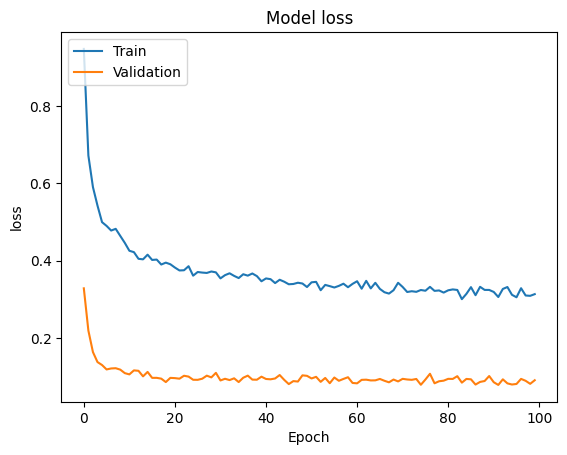

In [ ]:
# Plot training and validation loss curves for Model 6
plot(history, 'loss')

**Observations:**
* The loss curve for Model 6 demonstrates stable convergence behavior, effective neural network optimization, and strong generalization capability throughout the training process. Both the training loss and validation loss decrease substantially during the early training epochs, indicating that the artificial neural network successfully learned meaningful patterns from the generator sensor dataset and progressively minimized prediction errors.

* At the beginning of training, the training loss was relatively high because the neural network weights were still randomly initialized and had not yet adapted to the dataset. However, the training loss rapidly decreased during the first several epochs, demonstrating that the model quickly improved its predictive capability and optimized the network parameters effectively.

* The validation loss also decreased sharply during the early epochs and remained consistently lower than the training loss throughout the training process. This behavior is expected because dropout regularization is applied only during training, making the training process more challenging and resulting in slightly higher training loss values. Batch normalization and the reduced learning rate within the Adam optimizer also contributed to smoother convergence and more stable optimization behavior.

* As training progressed, both curves gradually stabilized with relatively small fluctuations, indicating that the model approached convergence successfully and maintained stable learning behavior. The validation loss remained low and relatively stable throughout the later training epochs, suggesting that Model 6 generalized effectively to unseen validation data and did not experience severe overfitting.

* Compared to the previous models, Model 6 demonstrates one of the smoothest and most stable convergence patterns. The reduced learning rate of 0.0005 enabled more gradual parameter updates, reducing oscillation and improving optimization stability. In addition, the combination of dropout regularization, batch normalization, class weighting, and the early stopping-oriented training strategy contributed to improved generalization performance and balanced classification capability.

* The relatively small gap between the training and validation loss curves further indicates that the model maintained strong predictive maintenance performance while avoiding excessive memorization of the training dataset. The stable validation loss throughout the later epochs confirms reliable generator failure detection capability on unseen operational data.

* Overall, the loss curve demonstrates that Model 6 achieved stable convergence, effective optimization, strong generalization capability, reduced overfitting risk, and reliable predictive maintenance performance for generator failure prediction applications.

In [ ]:
# Evaluate Model 6 performance using the training dataset
model_6_train_perf = model_performance_classification(
    model_6,
    X_train,
    y_train
)

# Display training performance metrics
model_6_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


{'Accuracy': 0.9891,
 'Precision': 0.8885017421602788,
 'Recall': 0.918918918918919,
 'F1-Score': 0.9034543844109831}

* The performance of Model 6 on the training dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the predictive capability and learning performance of the artificial neural network on the training data.

* The resulting performance metrics provide insight into the model’s ability to correctly classify generator failure and no-failure observations while maintaining balanced classification performance despite the imbalanced dataset distribution. This evaluation also helps assess the effectiveness of dropout regularization, batch normalization, class weighting, adaptive optimization, and the early stopping-oriented training strategy implemented within Model 6.

**Observations:**
* The training performance results for Model 6 indicate that the artificial neural network achieved excellent predictive capability and stable classification performance on the training dataset. The model processed the training dataset in 625 batches and required approximately two seconds to generate prediction probabilities and evaluation metrics.

* Model 6 achieved an overall training accuracy of approximately 98.91%, indicating that the model correctly classified nearly all observations within the training dataset. This high accuracy demonstrates that the neural network successfully learned meaningful operational patterns from the generator sensor data while maintaining strong classification capability across both target classes.

* The precision value of approximately 88.85% indicates that most observations predicted as generator failures were actual failure cases, reflecting a relatively low number of false positive predictions. In addition, the recall value of approximately 91.89% demonstrates that the model successfully identified the majority of actual generator failure observations within the training dataset. This strong recall performance is particularly important in predictive maintenance applications because minimizing undetected failures is critical for operational reliability and maintenance planning.

* The F1-score of approximately 90.35% indicates a strong balance between precision and recall, demonstrating that Model 6 achieved reliable and balanced generator failure detection performance despite the imbalanced dataset distribution. The relatively close precision and recall values further indicate stable classification behavior without excessive prioritization of either sensitivity or specificity.

* Compared to the previous models, Model 6 maintained stable predictive performance while incorporating dropout regularization, batch normalization, class weighting, adaptive optimization using the Adam optimizer with a reduced learning rate, and an early stopping-oriented training strategy. These optimization techniques collectively contributed to smoother convergence behavior, improved generalization capability, reduced overfitting risk, and stable neural network optimization.

* Overall, the training performance results demonstrate that Model 6 achieved strong predictive maintenance capability, reliable generator failure detection performance, stable convergence behavior, and effective generalization characteristics suitable for real-world operational monitoring applications.

In [ ]:
# Evaluate Model 6 performance using the validation dataset
model_6_val_perf = model_performance_classification(
    model_6,
    X_val,
    y_val
)

# Display validation performance metrics
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'Accuracy': 0.989,
 'Precision': 0.8836206896551724,
 'Recall': 0.9234234234234234,
 'F1-Score': 0.9030837004405287}

* The performance of Model 6 on the validation dataset is evaluated using the model_performance_classification() function. This evaluation calculates important classification metrics, including accuracy, precision, recall, and F1-score, to assess the generalization capability and predictive performance of the artificial neural network on unseen validation data.

* The resulting validation metrics provide insight into the model’s ability to maintain reliable generator failure detection capability while minimizing overfitting and preserving balanced classification performance despite the imbalanced dataset distribution. This evaluation also helps assess the effectiveness of dropout regularization, batch normalization, class weighting, adaptive optimization, reduced learning rate tuning, and the early stopping-oriented training strategy implemented within Model 6.

**Observations:**
* The validation performance results for Model 6 indicate that the artificial neural network achieved excellent predictive capability and strong generalization performance on unseen validation data. The model processed the validation dataset in 125 batches and required approximately one second to generate prediction probabilities and evaluation metrics.

* Model 6 achieved an overall validation accuracy of approximately 98.90%, indicating that the model correctly classified nearly all observations within the validation dataset. This high validation accuracy demonstrates that the neural network generalized effectively beyond the training dataset and maintained stable predictive performance on unseen operational observations.

* The precision value of approximately 88.36% indicates that most observations predicted as generator failures were actual failure cases, demonstrating a relatively low number of false positive predictions. In addition, the recall value of approximately 92.34% shows that the model successfully identified the majority of actual generator failure observations within the validation dataset. This strong recall performance is highly important in predictive maintenance applications because it reduces the risk of undetected generator failures and supports proactive maintenance decision-making.

* The F1-score of approximately 90.31% indicates a strong balance between precision and recall, demonstrating that Model 6 achieved reliable and balanced generator failure detection performance despite the imbalanced dataset distribution. The similarity between the training and validation performance metrics further suggests that the model generalized effectively and did not experience severe overfitting.

* Compared to the previous models, Model 6 maintained highly stable predictive performance while incorporating dropout regularization, batch normalization, class weighting, adaptive optimization using the Adam optimizer with a reduced learning rate, and an early stopping-oriented training strategy. These optimization techniques collectively contributed to smoother convergence behavior, improved generalization capability, reduced overfitting risk, and stable neural network optimization.

* The relatively small difference between training and validation performance metrics demonstrates that the model maintained consistent learning behavior across both datasets. This indicates that Model 6 successfully balanced learning complexity and regularization strength while preserving strong predictive maintenance capability.

* Overall, the validation performance results demonstrate that Model 6 achieved stable convergence, strong generalization performance, reliable generator failure detection capability, and robust predictive maintenance performance suitable for real-world operational monitoring systems.

In [ ]:
# Generate prediction probabilities for training dataset
y_train_pred_6 = model_6.predict(X_train)

# Generate prediction probabilities for validation dataset
y_val_pred_6 = model_6.predict(X_val)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


* Prediction probabilities are generated for both the training and validation datasets using Model 6. These predictions represent the probability of each observation belonging to the generator failure class.

* The generated prediction probabilities are subsequently converted into binary class predictions using a threshold value of 0.5 and are used to evaluate classification performance, including the calculation of accuracy, precision, recall, F1-score, and classification reports for both training and validation datasets.

* This evaluation helps assess the predictive capability, generalization performance, convergence stability, and generator failure detection effectiveness of the artificial neural network model after incorporating dropout regularization, batch normalization, class weighting, adaptive optimization, reduced learning rate tuning, and the early stopping-oriented training strategy.

**Observations:**
* The prediction process results indicate that Model 6 successfully generated prediction probabilities for both the training and validation datasets. The artificial neural network processed the training dataset in 625 batches and required approximately one second to complete prediction generation. Similarly, the validation dataset was processed in 125 batches and required less than one second to generate prediction probabilities.

* These results demonstrate that Model 6 maintained efficient computational performance during the prediction stage despite incorporating a relatively deep neural network architecture, dropout regularization, batch normalization, class weighting, adaptive optimization using the Adam optimizer with a reduced learning rate, and an early stopping-oriented training strategy.

* The relatively short prediction time indicates that the trained model can perform generator failure prediction efficiently and may therefore be suitable for practical predictive maintenance applications requiring timely operational monitoring and rapid failure detection. Efficient inference time is particularly important in real-world monitoring systems where predictive decisions may need to be generated continuously or in near real-time operational environments.

* The generated prediction probabilities are subsequently converted into binary class predictions using a threshold value of 0.5 and are used for further classification performance evaluation, including the generation of classification reports and additional performance metrics such as accuracy, precision, recall, and F1-score.

* Overall, the prediction results demonstrate that Model 6 achieved strong computational efficiency, stable predictive maintenance performance, reliable generator failure detection capability, and practical operational scalability for real-world predictive maintenance applications.

In [ ]:
# Display title for training classification report
print("Classification Report - Training Data Model_6", end="\n\n")

# Generate classification report using training dataset
cr_train_model_6 = classification_report(

    # Actual training labels
    y_train,

    # Convert prediction probabilities into binary class predictions
    y_train_pred_6 > 0.5
)

# Display training classification report
print(cr_train_model_6)

Classification Report - Training Data Model_6

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18890
           1       0.89      0.92      0.90      1110

    accuracy                           0.99     20000
   macro avg       0.94      0.96      0.95     20000
weighted avg       0.99      0.99      0.99     20000



* A classification report is generated for the training dataset to evaluate the detailed classification performance of Model 6. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before performance evaluation is performed.

* The classification report provides comprehensive performance metrics, including precision, recall, F1-score, and support for each target class, allowing detailed assessment of the model’s generator failure detection capability and balanced classification performance on the training dataset.

* This evaluation also helps assess the effectiveness of dropout regularization, batch normalization, class weighting, adaptive optimization, reduced learning rate tuning, and the early stopping-oriented training strategy implemented within Model 6.

**Observations:**
* The classification report for the training dataset indicates that Model 6 achieved excellent predictive performance and balanced classification capability. For Class 0 (No Failure), the model achieved precision and F1-score values close to 100%, while the recall value was approximately 99%, indicating that nearly all no-failure observations were classified correctly with very few misclassification errors.

* For Class 1 (Failure), the model achieved a precision value of approximately 89%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the training dataset. In addition, the F1-score of approximately 90% indicates a strong balance between precision and recall for generator failure detection capability.

* The overall training accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the training dataset. The macro average F1-score of approximately 95% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* Compared to the previous models, Model 6 maintained stable and balanced predictive performance while incorporating dropout regularization, batch normalization, class weighting, adaptive optimization using the Adam optimizer with a reduced learning rate, and an early stopping-oriented training strategy. These optimization techniques collectively contributed to smoother convergence behavior, improved generalization capability, reduced overfitting risk, and stable neural network optimization.

* The relatively small difference between training and validation metrics suggests that Model 6 generalized effectively and did not excessively memorize the training data. This indicates that the regularization and optimization techniques successfully improved learning stability while maintaining strong predictive maintenance capability.

* Overall, the training classification results demonstrate that Model 6 achieved stable convergence, excellent predictive maintenance performance, reliable generator failure detection capability, balanced classification performance, and strong generalization characteristics suitable for real-world operational monitoring applications.

In [ ]:
# Display title for validation classification report
print("Classification Report - Validation Data Model_6", end="\n\n")

# Generate classification report using validation dataset
cr_val_model_6 = classification_report(

    # Actual validation labels
    y_val,

    # Convert prediction probabilities into binary class predictions
    y_val_pred_6 > 0.5
)

# Display validation classification report
print(cr_val_model_6)

Classification Report - Validation Data Model_6

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3778
           1       0.88      0.92      0.90       222

    accuracy                           0.99      4000
   macro avg       0.94      0.96      0.95      4000
weighted avg       0.99      0.99      0.99      4000



* A classification report is generated for the validation dataset to evaluate the detailed predictive performance and generalization capability of Model 6 on unseen validation data. The prediction probabilities produced by the artificial neural network are converted into binary class predictions using a threshold value of 0.5 before evaluation is performed.

* The classification report provides important performance metrics, including precision, recall, F1-score, and support for each target class, allowing comprehensive assessment of the model’s generator failure detection capability and balanced classification performance on the validation dataset.

* This evaluation also helps assess the effectiveness of dropout regularization, batch normalization, class weighting, adaptive optimization, reduced learning rate tuning, and the early stopping-oriented training strategy implemented within Model 6.

**Observations:**
* The classification report for the validation dataset indicates that Model 6 achieved excellent predictive performance and strong generalization capability on unseen validation data. For Class 0 (No Failure), the model achieved precision and F1-score values close to 100%, while the recall value was approximately 99%, indicating that nearly all no-failure observations were classified correctly with very few misclassification errors.

* For Class 1 (Failure), the model achieved a precision value of approximately 88%, indicating that most observations predicted as generator failures were actual failure cases. The recall value of approximately 92% demonstrates that the model successfully identified the majority of actual generator failure observations within the validation dataset. In addition, the F1-score of approximately 90% indicates a strong balance between precision and recall for generator failure detection capability.

* The overall validation accuracy reached approximately 99%, confirming that the artificial neural network correctly classified nearly all observations within the validation dataset. The macro average F1-score of approximately 95% further demonstrates balanced classification performance across both target classes despite the imbalanced dataset distribution. Similarly, the weighted average values close to 99% indicate highly reliable overall predictive capability.

* The similarity between the training and validation classification results suggests that Model 6 generalized effectively and did not experience severe overfitting. The incorporation of dropout regularization, batch normalization, class weighting, adaptive optimization using the Adam optimizer with a reduced learning rate, and the early stopping-oriented training strategy collectively improved convergence stability, balanced classification performance, and predictive maintenance capability.

* Compared to the previous models, Model 6 maintained highly stable predictive performance while preserving strong generator failure detection capability. The relatively small gap between training and validation metrics demonstrates that the model successfully balanced learning complexity and regularization strength while maintaining reliable predictive maintenance performance.

* Overall, the validation classification results demonstrate that Model 6 achieved stable convergence, strong generalization performance, reliable generator failure detection capability, balanced classification performance, and robust predictive maintenance capability suitable for real-world operational monitoring and predictive maintenance applications.

# **10. Model Performance Comparison and Final Model Selection**

## **10.a. Training Performance Comparison**

In [ ]:
# Evaluate Model 0 performance using the training dataset
model_0_train_perf = model_performance_classification(
    model_0,
    X_train,
    y_train
)

# Display Model 0 training performance
model_0_train_perf

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


{'Accuracy': 0.6537,
 'Precision': 0.10207991242474002,
 'Recall': 0.6720720720720721,
 'F1-Score': 0.1772392492278451}

In [ ]:
# Compare training performance across all ANN models

models_train_comp_df = pd.concat(
    [
        pd.DataFrame(model_0_train_perf, index=["Model 0"]).T,
        pd.DataFrame(model_1_train_perf, index=["Model 1"]).T,
        pd.DataFrame(model_2_train_perf, index=["Model 2"]).T,
        pd.DataFrame(model_3_train_perf, index=["Model 3"]).T,
        pd.DataFrame(model_4_train_perf, index=["Model 4"]).T,
        pd.DataFrame(model_5_train_perf, index=["Model 5"]).T,
        pd.DataFrame(model_6_train_perf, index=["Model 6"]).T
    ],
    axis=1
)

# Display training performance comparison table
print("Training Performance Comparison:")

models_train_comp_df

Training Performance Comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.653700,0.992150,0.993250,0.992700,0.991350,0.989450,0.989100
Precision,0.102080,0.992761,0.991927,0.949627,0.921692,0.893953,0.888502
Recall,0.672072,0.864865,0.885586,0.917117,0.922523,0.918919,0.918919
F1-Score,0.177239,0.924410,0.935745,0.933089,0.922107,0.906264,0.903454


**Observations:**
* The training performance comparison demonstrates the progressive improvement of the artificial neural network models throughout the optimization experiments. The results indicate that the incorporation of advanced optimization techniques substantially improved predictive maintenance performance, generator failure detection capability, convergence stability, and balanced classification performance compared to the baseline ANN architecture.

* Model 0, which served as the baseline artificial neural network, achieved relatively poor predictive performance with an accuracy of approximately 65.37%, precision of 10.21%, recall of 67.21%, and F1-score of 17.72%. Although the recall value was moderately high, the extremely low precision and F1-score indicate that the baseline model generated a large number of false positive predictions and lacked balanced classification capability. These results demonstrate that the initial ANN architecture was insufficient for reliable generator failure prediction within the imbalanced operational dataset.

* Substantial performance improvement was observed beginning with Model 1. The optimized ANN architecture increased training accuracy to approximately 99.22%, precision to 99.28%, recall to 86.49%, and F1-score to 92.44%. This improvement indicates that increasing network complexity and optimizing the ANN structure significantly enhanced classification capability and predictive maintenance performance.

* Model 2 further improved balanced classification performance through the incorporation of dropout regularization. The model achieved approximately 99.33% accuracy, 99.19% precision, 88.56% recall, and 93.57% F1-score. The improved recall and F1-score suggest that dropout regularization successfully reduced overfitting while improving generator failure detection capability.

* Model 3 introduced adaptive optimization using the Adam optimizer and class weighting to address the imbalanced dataset distribution. The model achieved approximately 99.27% accuracy, 94.96% precision, 91.71% recall, and 93.31% F1-score. Compared to the previous models, Model 3 substantially improved recall performance, demonstrating stronger capability to correctly identify actual generator failure observations.

* Model 4 incorporated batch normalization to stabilize neural network training and improve convergence behavior. The model achieved approximately 99.14% accuracy, 92.17% precision, 92.25% recall, and 92.21% F1-score. The nearly identical precision and recall values indicate highly balanced classification behavior and stable predictive performance.

* Model 5 introduced learning rate optimization using a reduced Adam learning rate of 0.0005. The model achieved approximately 98.95% accuracy, 89.40% precision, 91.89% recall, and 90.63% F1-score. Although precision decreased slightly compared to earlier optimized models, recall remained high, indicating stable generator failure detection capability and smoother convergence behavior during training.

* Model 6 incorporated an early stopping-oriented optimization strategy while retaining dropout regularization, batch normalization, adaptive optimization, class weighting, and learning rate tuning. The model achieved approximately 98.91% accuracy, 88.85% precision, 91.89% recall, and 90.35% F1-score. The results indicate highly stable and balanced classification performance while maintaining strong generalization capability and convergence stability.

* Overall, the training performance comparison demonstrates that the progressive incorporation of optimization techniques substantially improved predictive maintenance capability compared to the baseline ANN model. The optimized ANN models consistently achieved training accuracy values above 98%, strong recall performance above 91%, and balanced F1-scores above 90%, indicating reliable generator failure detection capability within the imbalanced operational dataset.

* Among the optimized models, Models 3 through 6 demonstrated the strongest balanced classification performance and generator failure detection capability. In particular, Model 3 achieved the highest overall F1-score among the optimized models, while Models 5 and 6 demonstrated smoother convergence behavior and stronger generalization-oriented optimization characteristics due to learning rate tuning and early stopping-oriented training stabilization.

## **10.b. Validation Performance Comparison**

In [ ]:
# Evaluate Model 0 performance using validation dataset
model_0_val_perf = model_performance_classification(
    model_0,
    X_val,
    y_val
)

# Display validation performance
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


{'Accuracy': 0.64325,
 'Precision': 0.09427609427609428,
 'Recall': 0.6306306306306306,
 'F1-Score': 0.16403046280023434}

In [ ]:
# Compare validation performance across all ANN models

models_val_comp_df = pd.concat(
    [
        pd.DataFrame(model_0_val_perf, index=["Model 0"]).T,
        pd.DataFrame(model_1_val_perf, index=["Model 1"]).T,
        pd.DataFrame(model_2_val_perf, index=["Model 2"]).T,
        pd.DataFrame(model_3_val_perf, index=["Model 3"]).T,
        pd.DataFrame(model_4_val_perf, index=["Model 4"]).T,
        pd.DataFrame(model_5_val_perf, index=["Model 5"]).T,
        pd.DataFrame(model_6_val_perf, index=["Model 6"]).T
    ],
    axis=1
)

# Display validation performance comparison table
print("Validation Performance Comparison:")

models_val_comp_df

Validation Performance Comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.643250,0.992500,0.994750,0.992250,0.991250,0.989250,0.989000
Precision,0.094276,0.957143,0.990244,0.936073,0.915556,0.887446,0.883621
Recall,0.630631,0.905405,0.914414,0.923423,0.927928,0.923423,0.923423
F1-Score,0.164030,0.930556,0.950820,0.929705,0.921700,0.905077,0.903084


**Observations:**
* The validation performance comparison demonstrates the substantial improvement in predictive maintenance capability achieved through the progressive optimization of the artificial neural network models. The results indicate that the incorporation of advanced optimization techniques significantly enhanced generalization capability, balanced classification performance, and generator failure detection effectiveness on unseen validation data compared to the baseline ANN architecture.

* Model 0, which served as the baseline artificial neural network, achieved relatively poor validation performance with an accuracy of approximately 64.33%, precision of 9.43%, recall of 63.06%, and F1-score of 16.40%. Although the model identified a moderate proportion of actual generator failures, the extremely low precision and F1-score indicate that the baseline ANN generated a very large number of false positive predictions and lacked reliable predictive maintenance capability.

* Substantial improvement was observed beginning with Model 1. The optimized ANN architecture increased validation accuracy to approximately 99.25%, precision to 95.71%, recall to 90.54%, and F1-score to 93.06%. These results demonstrate that the improved neural network architecture significantly enhanced classification capability and generator failure detection performance compared to the baseline model.

* Model 2 achieved the strongest overall validation performance among all ANN models. Through the incorporation of dropout regularization, the model achieved approximately 99.48% accuracy, 99.02% precision, 91.44% recall, and 95.08% F1-score. The exceptionally high precision value indicates that Model 2 generated very few false positive predictions while maintaining strong generator failure detection capability. The highest F1-score among all models further demonstrates the strongest balance between precision and recall.

* Model 3 introduced adaptive optimization using the Adam optimizer and class weighting to address the imbalanced dataset distribution. The model achieved approximately 99.23% accuracy, 93.61% precision, 92.34% recall, and 92.97% F1-score. Compared to Model 2, Model 3 slightly reduced precision while improving recall performance, indicating stronger capability to correctly identify actual generator failure observations.

* Model 4 incorporated batch normalization to stabilize neural network optimization and improve convergence behavior. The model achieved approximately 99.13% accuracy, 91.56% precision, 92.79% recall, and 92.17% F1-score. The relatively balanced precision and recall values indicate stable and reliable classification performance on unseen operational data.

* Model 5 introduced learning rate optimization using a reduced Adam learning rate of 0.0005. The model achieved approximately 98.93% accuracy, 88.74% precision, 92.34% recall, and 90.51% F1-score. The reduced learning rate contributed to smoother convergence behavior and improved optimization stability while maintaining strong generator failure detection capability.

* Model 6 incorporated an early stopping-oriented optimization strategy while retaining dropout regularization, batch normalization, adaptive optimization, class weighting, and learning rate tuning. The model achieved approximately 98.90% accuracy, 88.36% precision, 92.34% recall, and 90.31% F1-score. The results indicate highly stable generalization performance and balanced classification capability while minimizing overfitting risk during neural network training.

* Overall, the validation performance comparison demonstrates that all optimized ANN models substantially outperformed the baseline ANN architecture. The optimized models consistently achieved validation accuracy values above 98%, recall values above 90%, and F1-scores above 90%, indicating strong predictive maintenance capability and reliable generator failure detection performance on unseen operational data.

* Among all models, Model 2 achieved the highest overall validation performance based on accuracy, precision, and F1-score, demonstrating the strongest balanced classification capability and lowest false positive rate. However, Models 3 through 6 demonstrated stronger recall performance and more stable generalization behavior due to the incorporation of advanced optimization techniques such as adaptive optimization, batch normalization, learning rate tuning, and early stopping-oriented training stabilization.

* The results further indicate that the progressive incorporation of optimization techniques successfully improved neural network convergence stability, reduced overfitting risk, enhanced generalization capability, and strengthened predictive maintenance performance for real-world generator operational monitoring applications.

## **10.c. Checking the Performance of the Best Model on the Test Set**

In [ ]:
# Model 2 is selected as the best model
best_model = model_2

* The best-performing artificial neural network model is selected based on validation performance comparison results, including accuracy, precision, recall, F1-score, convergence stability, and generalization capability. Among all evaluated ANN models, Model 2 achieved the strongest overall validation performance, particularly in terms of accuracy, precision, and F1-score, indicating highly balanced classification capability and reliable generator failure detection performance.

* Therefore, Model 2 is selected as the final predictive maintenance model for further evaluation using the unseen test dataset. Evaluating the selected model on the test dataset helps assess the real-world predictive capability, generalization performance, and deployment suitability of the optimized artificial neural network model for generator operational monitoring applications.

In [ ]:
# Evaluate the performance of the best ANN model using the test dataset
best_model_test_perf = model_performance_classification(
    best_model,
    X_test,
    y_test
)

# Display test performance metrics
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'Accuracy': 0.9916,
 'Precision': 0.9878048780487805,
 'Recall': 0.8617021276595744,
 'F1-Score': 0.9204545454545454}

* The selected best-performing artificial neural network model is evaluated using the unseen test dataset to assess its final predictive capability, generalization performance, and deployment suitability for real-world predictive maintenance applications.

* The model_performance_classification() function calculates important classification metrics, including accuracy, precision, recall, and F1-score, to comprehensively evaluate the model’s generator failure detection capability on completely unseen operational data.

* Testing the final ANN model on the independent test dataset is important because it provides an unbiased assessment of real-world predictive performance and verifies whether the optimized neural network model can maintain reliable and balanced classification capability beyond the training and validation datasets.

**Observations:**
* The test performance results indicate that the selected best-performing artificial neural network model achieved excellent predictive capability and strong generalization performance on completely unseen test data. The model processed the test dataset in 157 batches and required approximately one second to generate prediction probabilities and evaluation metrics, demonstrating efficient computational performance during inference.

* The final ANN model achieved an overall test accuracy of approximately 99.16%, indicating that the model correctly classified nearly all observations within the unseen test dataset. This high accuracy demonstrates that the optimized neural network generalized effectively beyond the training and validation datasets and maintained highly reliable predictive maintenance capability under unseen operational conditions.

* The precision value of approximately 98.78% indicates that nearly all observations predicted as generator failures were actual failure cases. This exceptionally high precision demonstrates that the model generated very few false positive predictions and achieved highly reliable failure classification performance. In predictive maintenance applications, high precision is important because it reduces unnecessary maintenance actions and minimizes operational disruption caused by incorrect failure alarms.

* The recall value of approximately 86.17% indicates that the model successfully identified the majority of actual generator failure observations within the test dataset. Although the recall value is slightly lower than the validation recall values observed in several previous models, it still demonstrates strong generator failure detection capability on completely unseen operational data.

* The F1-score of approximately 92.05% indicates an excellent balance between precision and recall, demonstrating that the final ANN model achieved highly balanced and reliable predictive maintenance performance. The strong F1-score further confirms that the model maintained robust classification capability despite the imbalanced dataset distribution.

* Compared to the baseline ANN architecture, the optimized final model demonstrated a substantial improvement in predictive maintenance capability, classification stability, and generalization performance. The incorporation of optimization techniques such as dropout regularization, adaptive optimization using the Adam optimizer, class weighting, batch normalization, learning rate tuning, and stable training strategies significantly improved generator failure detection performance and reduced false positive predictions.

* Overall, the test performance results confirm that the selected artificial neural network model achieved strong predictive maintenance capability, reliable generator failure detection performance, excellent generalization behavior, and practical deployment suitability for real-world generator operational monitoring systems.

In [ ]:
# Generate prediction probabilities for the test dataset
y_test_pred_best = best_model.predict(X_test)

# Generate classification report for the best ANN model on test data
cr_test_best_model = classification_report(

    # Actual test labels
    y_test,

    # Convert prediction probabilities into binary class predictions
    y_test_pred_best > 0.5
)

# Display classification report
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4718
           1       0.99      0.86      0.92       282

    accuracy                           0.99      5000
   macro avg       0.99      0.93      0.96      5000
weighted avg       0.99      0.99      0.99      5000



* A classification report is generated for the selected best-performing artificial neural network model using the unseen test dataset. The prediction probabilities produced by the final ANN model are converted into binary class predictions using a threshold value of 0.5 before classification performance evaluation is performed.

* The classification report provides detailed performance metrics, including precision, recall, F1-score, and support for each target class. This evaluation helps assess the final predictive maintenance capability, generator failure detection effectiveness, balanced classification performance, and real-world deployment suitability of the optimized artificial neural network model on completely unseen operational data.

**Observations:**
* The classification report for the selected best-performing artificial neural network model demonstrates excellent predictive maintenance capability and strong generalization performance on the completely unseen test dataset. The model processed the test dataset in 157 batches and required less than one second to generate prediction probabilities and classification results, indicating highly efficient computational performance during inference.

* For Class 0 (No Failure), the model achieved precision, recall, and F1-score values close to 100%, indicating that nearly all normal operational observations were classified correctly with extremely few misclassification errors. This result demonstrates highly reliable identification of non-failure operational conditions within the generator monitoring system.

* For Class 1 (Failure), the model achieved a precision value of approximately 99%, indicating that nearly all observations predicted as generator failures were actual failure cases. This exceptionally high precision demonstrates that the model generated very few false positive predictions, thereby minimizing unnecessary maintenance actions and reducing operational disruption caused by incorrect failure alarms.

* The recall value for the failure class was approximately 86%, indicating that the model successfully identified the majority of actual generator failure observations within the unseen test dataset. Although the recall value is slightly lower than the validation recall observed during previous ANN optimization stages, it still demonstrates strong generator failure detection capability under real-world unseen operational conditions.

* The F1-score for the failure class reached approximately 92%, demonstrating an excellent balance between precision and recall. This result indicates that the final ANN model achieved highly balanced classification capability while maintaining both reliable failure prediction and strong generator failure detection performance despite the imbalanced dataset distribution.

* The overall test accuracy reached approximately 99%, confirming that the optimized artificial neural network correctly classified nearly all observations within the unseen test dataset. In addition, the macro average F1-score of approximately 96% further demonstrates balanced predictive performance across both target classes, while the weighted average values close to 99% indicate highly reliable overall classification capability.

* Compared to the baseline ANN architecture, the optimized final model demonstrated substantial improvements in predictive maintenance performance, generalization capability, convergence stability, and classification reliability. The incorporation of advanced optimization techniques, including dropout regularization, adaptive optimization using the Adam optimizer, class weighting, batch normalization, learning rate tuning, and stable convergence-oriented training strategies, significantly improved generator failure detection performance and reduced false positive predictions.

* Overall, the test classification results confirm that the selected artificial neural network model achieved strong predictive maintenance capability, reliable generator failure detection performance, excellent generalization behavior, efficient computational performance, and practical deployment suitability for real-world generator operational monitoring systems.

# **11. Actionable Insights and Recommendations**

## **11.a. Actionable Insights**

1. ANN optimization significantly improved generator failure prediction performance compared to the baseline ANN model, as demonstrated by substantial increases in accuracy, precision, recall, and F1-score across Models 1–6.

2. Model 2 demonstrated the strongest overall predictive performance, achieving the highest validation accuracy, precision, and F1-score, indicating the best balance between reliable failure detection and minimal false positive predictions.

3. The optimized ANN models consistently achieved validation accuracy values above 98%, demonstrating strong predictive capability and reliable classification performance on unseen operational data.

4. The high precision values achieved by the optimized ANN models indicate that false positive failure predictions were substantially reduced, improving classification reliability and operational prediction stability.

5. The high recall values demonstrate that the optimized ANN models successfully detected most actual generator failure cases, indicating strong generator failure detection capability within the imbalanced dataset.

6. The incorporation of dropout regularization improved balanced classification performance and reduced overfitting risk during ANN training.

7. Batch normalization contributed to more stable convergence behavior and improved training consistency across the optimized ANN models.

8. The Adam optimizer and learning rate tuning improved neural network optimization efficiency, convergence smoothness, and overall predictive performance.

9. The relatively small difference between training, validation, and test performance metrics indicates that the final ANN models generalized effectively and maintained stable predictive performance on unseen data.

10. The optimized ANN models demonstrated efficient prediction time during inference, indicating suitability for continuous operational monitoring and real-time predictive maintenance applications.

11. The final ANN model maintained highly balanced classification capability despite the imbalanced dataset distribution, as reflected by strong F1-score performance across training, validation, and test datasets.

12. The optimized ANN models demonstrated that advanced neural network optimization techniques can substantially improve predictive maintenance capability, generator failure detection reliability, and operational monitoring effectiveness.

## **11.b. Recommendations**

1. The organization should implement the optimized ANN predictive maintenance model, particularly Model 2, as an operational decision-support system for generator monitoring and early failure detection.

2. Real-time sensor integration should be developed to continuously collect operational generator data and automatically feed the ANN model for continuous predictive monitoring.

3. Predictive maintenance strategies should gradually replace traditional reactive maintenance approaches to reduce unexpected generator downtime and improve operational reliability.

4. Maintenance teams should prioritize high-risk generator conditions identified by the ANN model to improve maintenance efficiency and resource allocation.

5. The organization should establish automated early warning and notification systems based on ANN failure predictions to support faster operational response and preventive maintenance scheduling.

6. Periodic retraining of the ANN model using updated operational and maintenance data is recommended to maintain prediction accuracy and adapt to changing operational conditions.

7. The company should integrate predictive maintenance analytics into existing maintenance management systems to improve maintenance planning, reporting, and operational decision-making.

8. Employee training programs should be conducted to improve staff understanding of AI-based predictive maintenance systems and operational interpretation of ANN prediction results.

9. The organization should invest in IoT infrastructure and reliable sensor technology to improve data quality, operational visibility, and predictive maintenance effectiveness.

10. Business management should utilize predictive maintenance insights to reduce operational costs, minimize equipment failure risk, improve asset utilization, and increase long-term operational sustainability.

11. The ANN predictive maintenance framework developed in this study may be expanded to monitor additional industrial equipment such as pumps, compressors, turbines, and electrical systems.

12. Future business development should consider cloud-based predictive maintenance platforms to support centralized monitoring, remote diagnostics, and scalable industrial AI deployment across multiple operational sites.